### Bundles Engine Solution


The solution uses the existing Dynamic Pricing Algorithm unchanged, predicts the business popularity of a bundle from historical bundle data, uses a Genetic Algorithm to search for better bundle structures under telecom business constraints, subtracts cannibalization risk from the objective, and finally uses an LLM only for naming and presentation.

1. Building the popularity model that predict popularity score (revenue and unique users) for a give bundle features.

2. pricing based on our dynamic pricing algorithm

3. Generate new telecom bundles using CTANs and keep top 20% based on popularity score.

4. Incrementality and cannibalization Modelling of the new bundles and keep bundles with best resutlts.

5. using LLM to name the generated bundles.


In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit

### Popularity Model

predict Popularity score based on bundle features without its name.

In [2]:
DATASET_FOLDER: str = r"..\..\datasets"
WEEKLY_BUNDLES_DATA_PATH: str = rf"{DATASET_FOLDER}\weekly_base_bundles_info_202501_202510.csv"


data = pd.read_csv(WEEKLY_BUNDLES_DATA_PATH) 
print(data.shape)
data.head(10)

(42377, 15)


,week_number,year_number,bundle_id,bundle_name,bundle_type,validity,price,usage_type,configured_volume,service_class_category,total_duration,total_rev,total_subscriptions,total_sessions,unique_users
0,1,2025,37076,Forfait 1.6Go 30 jours@4000F,BUNDLE_DATA,30 Day(s),4000,CHARGED,1.61,PREPAID,0.0,36000.00,9,10,9
1,1,2025,50134,Forfait appels RCA 2 mins 30 jours@690F,INT_BUNDLE_VOICE,30 Day(s),690,CHARGED,2MIN,PREPAID,0.0,3450.00,5,5,5
2,1,2025,50129,Forfait appels Nigeria 2 mins 30 jours@200F,INT_BUNDLE_VOICE,30 Day(s),200,CHARGED,2MIN,PREPAID,0.0,400.00,2,2,1
3,1,2025,35070,Forfait 1 jour 170MB@215F,BUNDLE_DATA,1 Day(s),215,CHARGED,170,PREPAID,0.0,124060.00,577,584,340
4,1,2025,36667,NDAKO BOX ILLIMITE@50050F,BUNDLE_DATA,30 Day(s),50050,CHARGED,Unlimited,PREPAID,0.0,200200.00,4,4,4
5,1,2025,50191,Int Bundle ROW 10min 30jours a 1500F,INT_BUNDLE_VOICE,30 Day(s),1500,CHARGED,10MIN,PREPAID,0.0,37500.00,25,25,24
6,1,2025,50214,Forfait appels Guinee Conakry 2 mins 30 jours@...,INT_BUNDLE_VOICE,30 Day(s),590,CHARGED,2MIN,PREPAID,0.0,56640.00,96,97,49
7,1,2025,80069,Ndeko_11Mins 1 jour@185F,BUNDLE_VOICE,1 Day(s),185,CHARGED,11min,PREPAID,0.0,17161358.36,98080,98523,65542
8,1,2025,SMSPK100,SMS Bundle 3 Days@122F,BUNDLE_SMS,3 Day(s),122,CHARGED,NaN,PREPAID,0.0,10018029.99,82115,82115,20643
9,1,2025,36279,Promo Back2School 250MB 2 Days @50F,BUNDLE_DATA,2 Day(s),50,CHARGED,250MB,PREPAID,0.0,10850.00,217,220,216


In [3]:
data = data[~data['configured_volume'].isna()]

In [4]:
# Extract Configured Volumes 'configured_volume'
def extract_conf_volume_values(volume_str):
    """
    Extract MB, minutes, and SMS from configured_volume string.
    Handles: GB (→ MB), MB, Minutes, SMS, commas, combinations, addition formats, etc.
    """
    if pd.isna(volume_str) or volume_str is None:
        return {'mb': None, 'min': None, 'sms': None}
    
    original_str = str(volume_str)
    if original_str.lower() in ['unlimited', 'illimité', 'illimite']:
        return {'mb': None, 'min': None, 'sms': None}
    
    volume_str = original_str.replace(',', '.')
    volume_str_upper = volume_str.upper()
    
    mb_value = None
    min_value = None
    sms_value = None
    
    # extract GB and convert to MB
    gb_pattern = r'(\d+(?:\.\d+)?)\s*G(?:B)?\b'
    gb_matches = re.findall(gb_pattern, volume_str_upper)
    if gb_matches:
        mb_value = sum(float(gb) for gb in gb_matches) * 1024
    
    # extract MB
    mb_pattern = r'(\d+(?:\.\d+)?)\s*MB\b'
    mb_matches = re.findall(mb_pattern, volume_str_upper)
    if mb_matches:
        total_mb = sum(float(mb) for mb in mb_matches)
        mb_value = total_mb if mb_value is None else mb_value + total_mb
    
    # extract minutes
    min_pattern = r'(\d+(?:\.\d+)?)\s*MINS?\b'
    min_matches = re.findall(min_pattern, volume_str_upper)
    add_pattern_min = r'(\d+(?:\.\d+)?)\s*\+\s*(\d+(?:\.\d+)?)\s*MINS?\b'
    add_match_min = re.search(add_pattern_min, volume_str_upper)
    
    if add_match_min:
        min_value = float(add_match_min.group(1)) + float(add_match_min.group(2))
    elif min_matches:
        min_value = sum(float(m) for m in min_matches)
    
    # extract SMS
    sms_pattern = r'(\d+(?:\.\d+)?)\s*SMS\b'
    sms_matches = re.findall(sms_pattern, volume_str_upper)
    if sms_matches:
        sms_value = sum(float(sms) for sms in sms_matches)
    
    # handle "/" formats like "200/40 mins"
    slash_pattern = r'(\d+(?:\.\d+)?)\s*/\s*(\d+(?:\.\d+)?)'
    slash_match = re.search(slash_pattern, volume_str)
    if slash_match and 'MIN' in volume_str_upper:
        if min_value is None:
            min_value = float(slash_match.group(2))
        if mb_value is None:
            mb_value = float(slash_match.group(1))
    
    # handle seconds
    sec_pattern = r'(\d+(?:\.\d+)?)\s*SEC\b'
    sec_matches = re.findall(sec_pattern, volume_str_upper)
    if sec_matches:
        sec_as_min = sum(float(sec) for sec in sec_matches) / 60.0
        min_value = sec_as_min if min_value is None else min_value + sec_as_min
    
    return {'mb': mb_value, 'min': min_value, 'sms': sms_value}


volume_extracted = data['configured_volume'].apply(extract_conf_volume_values)
data['configured_volume_mb'] = volume_extracted.apply(lambda x: x['mb'] if x['mb'] is not None else 0.0)
data['configured_volume_min'] = volume_extracted.apply(lambda x: x['min'] if x['min'] is not None else 0.0)
data['configured_volume_sms'] = volume_extracted.apply(lambda x: x['sms'] if x['sms'] is not None else 0.0)
data.drop(columns=['configured_volume'], inplace=True)

In [5]:
def clean_price(val) -> float:
        if pd.isna(val):
            return None
        val = str(val).replace("F", "").replace(",", "")
        try:
            return float(val)
        except:
            return None
    

data["price"] = data["price"].apply(clean_price)

In [6]:

data['clean_validity'] = np.where(
    data['validity'].str.strip().str.lower().isin(['null', '']) | data['validity'].isna(),
    None,
    data['validity']
        .str.strip()
        .str.lower()
        .str.replace(r'\(s\)', '', regex=True)         # remove (s)
        .str.replace(r'\bday\b', 'days', regex=True)  # day → days
        .str.replace(r'\bmonth\b', 'months', regex=True)  # month → months
)
data.drop(columns=['validity'], inplace=True)
data = data.rename(columns={"clean_validity": "validity"})


In [7]:
def parse_validity_to_hours(val):
    """
    Convert variants like '7 days', '4 hours', '3 months', '1  days', None -> hours (float)
    Uses 30 days per month convention for telecom.
    Returns np.nan if cannot parse.
    """
    if pd.isna(val):
        return np.nan
    if isinstance(val, (int, float)):
        # unexpected numeric — treat as days
        return float(val) * 24.0
    s = str(val).strip().lower()
    # correct double spaces
    s = re.sub(r"\s+", " ", s)
    # find number
    m = re.match(r"^(\d+(\.\d+)?)\s*(day|days|hour|hours|month|months)?", s)
    if not m:
        return np.nan
    num = float(m.group(1))
    unit = m.group(3) or "days"
    if "hour" in unit:
        return num
    if "day" in unit:
        return num * 24.0
    if "month" in unit:
        return num * 30.0 * 24.0
    # fallback assume days
    return num * 24.0


data['validity_hours'] = data['validity'].apply(parse_validity_to_hours)

In [8]:
data = data[~data["bundle_name"].str.contains("DIY", case=False, na=False)]

In [9]:
data.drop(columns=['total_duration'], inplace=True)
data.dropna(subset=['bundle_name'], inplace=True)

In [10]:
data['validity'] = data['validity'].fillna('NO_VALIDITY')
data['validity_hours'] = data['validity_hours'].fillna(0)

In [11]:
def extract_price(text):
    if pd.isna(text):
        return None
    match = re.search(r'@(\d+)\s*F', str(text))
    if match:
        return float(match.group(1))
    return None


# try to extract price from bundle_name for all rows with missing price
mask_missing_price = data['price'].isna()
data.loc[mask_missing_price, 'price_extracted'] = \
    data.loc[mask_missing_price, 'bundle_name'].apply(extract_price)

# fill price where extraction was successful
data['price'] = data['price'].fillna(data['price_extracted'])


# 4. FREE bundles (@F)
free_mask = data['bundle_name'].str.contains('@F', na=False)
data.loc[free_mask, 'price'] = 0

# STAFF bundles
staff_mask = data['bundle_name'].str.contains('STAFF', na=False, case=False)
data.loc[staff_mask, 'price'] = 0

# VAS services and system events
system_names = ['SDP VAS', 'MTN ME2U', 'MTN Xtratime', 
                'MTN Call Me Back', 'MTN Tv']

system_mask = data['bundle_name'].isin(system_names)
data.loc[system_mask, 'price'] = 0

# Anything still missing → truly unknown, set to zero but mark category
still_missing = data['price'].isna()
data.loc[still_missing, 'price'] = 0

data.drop(columns=['price_extracted'], inplace=True)

In [12]:
def week_to_season(iso_week):
    if 1 <= iso_week <= 13:
        return "winter"
    elif 14 <= iso_week <= 26:
        return "spring"
    elif 27 <= iso_week <= 39:
        return "summer"
    else:
        return "autumn"


data["season"] = data["week_number"].apply(week_to_season)

In [13]:

# Add revenue contribution for each bundle in each week.
rev_by_iso_week = data.groupby("week_number")["total_rev"].sum()
data["week_total_rev"] = data["week_number"].map(rev_by_iso_week)
data["rev_contribution"] = data["total_rev"] / data["week_total_rev"]
data["rev_contribution_pct"] = data["rev_contribution"] * 100
data.drop(columns=['week_total_rev'], inplace=True)

In [14]:

data = data[~(data['total_rev'] <= 0.0)]
data = data[~(data['usage_type'] == 'FREE')]

In [15]:
def is_illimite(bundle_name: str) -> int:
    return 1 if "illimite" in bundle_name.lower() else 0


data['is_illimite'] = data['bundle_name'].apply(is_illimite)

In [16]:
data.head(10)

,week_number,year_number,bundle_id,bundle_name,bundle_type,price,usage_type,service_class_category,total_rev,total_subscriptions,...,unique_users,configured_volume_mb,configured_volume_min,configured_volume_sms,validity,validity_hours,season,rev_contribution,rev_contribution_pct,is_illimite
0,1,2025,37076,Forfait 1.6Go 30 jours@4000F,BUNDLE_DATA,4000.0,CHARGED,PREPAID,36000.00,9,...,9,0.0,0.0,0.0,30 days,720.0,winter,2.793816e-05,0.002794,0
1,1,2025,50134,Forfait appels RCA 2 mins 30 jours@690F,INT_BUNDLE_VOICE,690.0,CHARGED,PREPAID,3450.00,5,...,5,0.0,2.0,0.0,30 days,720.0,winter,2.677407e-06,0.000268,0
2,1,2025,50129,Forfait appels Nigeria 2 mins 30 jours@200F,INT_BUNDLE_VOICE,200.0,CHARGED,PREPAID,400.00,2,...,1,0.0,2.0,0.0,30 days,720.0,winter,3.104240e-07,0.000031,0
3,1,2025,35070,Forfait 1 jour 170MB@215F,BUNDLE_DATA,215.0,CHARGED,PREPAID,124060.00,577,...,340,0.0,0.0,0.0,1 days,24.0,winter,9.627801e-05,0.009628,0
4,1,2025,36667,NDAKO BOX ILLIMITE@50050F,BUNDLE_DATA,50050.0,CHARGED,PREPAID,200200.00,4,...,4,0.0,0.0,0.0,30 days,720.0,winter,1.553672e-04,0.015537,1
5,1,2025,50191,Int Bundle ROW 10min 30jours a 1500F,INT_BUNDLE_VOICE,1500.0,CHARGED,PREPAID,37500.00,25,...,24,0.0,10.0,0.0,30 days,720.0,winter,2.910225e-05,0.002910,0
6,1,2025,50214,Forfait appels Guinee Conakry 2 mins 30 jours@...,INT_BUNDLE_VOICE,590.0,CHARGED,PREPAID,56640.00,96,...,49,0.0,2.0,0.0,30 days,720.0,winter,4.395604e-05,0.004396,0
7,1,2025,80069,Ndeko_11Mins 1 jour@185F,BUNDLE_VOICE,185.0,CHARGED,PREPAID,17161358.36,98080,...,65542,0.0,11.0,0.0,1 days,24.0,winter,1.331824e-02,1.331824,0
9,1,2025,36279,Promo Back2School 250MB 2 Days @50F,BUNDLE_DATA,50.0,CHARGED,PREPAID,10850.00,217,...,216,250.0,0.0,0.0,2 days,48.0,winter,8.420251e-06,0.000842,0
11,1,2025,36602,Maxinet 3 Days 9H@425F,BUNDLE_DATA,425.0,CHARGED,PREPAID,1609475.00,3787,...,2336,0.0,0.0,0.0,3 days,72.0,winter,1.249049e-03,0.124905,0


In [17]:
def norm(col, eps=1e-9):
    col = np.log1p(col)  # compress heavy tails
    return (col - col.min()) / (col.max() - col.min() + eps)


def compute_popularity(df, eps=1e-9):
    df = df.copy()

    df["R_norm"]   = norm(df["total_rev"])
    df["U_norm"]   = norm(df["unique_users"])
    df["rev_contribution_norm"] = norm(df["rev_contribution_pct"])

    # populatiry func
    β, γ,  δ = 0.50, 0.25, 0.25
 
    df["popularity_score"] = (
        β * df["R_norm"] +
        γ * df["U_norm"] +
        δ * df["rev_contribution_norm"]
    )
    print("populatiry func computed")

    return df

data_pop = compute_popularity(data)

populatiry func computed


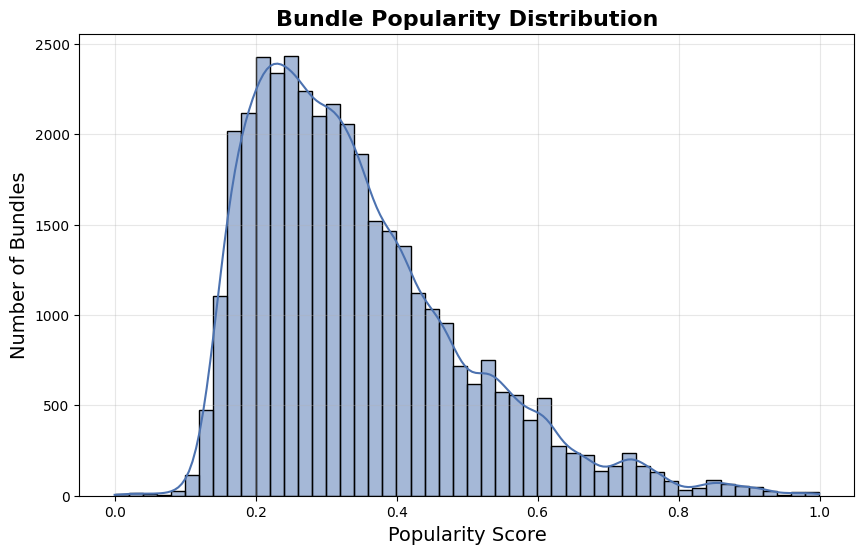

In [18]:
plt.figure(figsize=(10,6))
sns.histplot(data_pop['popularity_score'], bins=50, kde=True, color="#4C72B0", edgecolor='black')
plt.title("Bundle Popularity Distribution", fontsize=16, fontweight='bold')
plt.xlabel("Popularity Score", fontsize=14)
plt.ylabel("Number of Bundles", fontsize=14)
plt.grid(alpha=0.3)
plt.show()

In [19]:
data.loc[:, 'popularity'] = data_pop['popularity_score'].values
del data_pop

In [20]:
data.head(10)

,week_number,year_number,bundle_id,bundle_name,bundle_type,price,usage_type,service_class_category,total_rev,total_subscriptions,...,configured_volume_mb,configured_volume_min,configured_volume_sms,validity,validity_hours,season,rev_contribution,rev_contribution_pct,is_illimite,popularity
0,1,2025,37076,Forfait 1.6Go 30 jours@4000F,BUNDLE_DATA,4000.0,CHARGED,PREPAID,36000.00,9,...,0.0,0.0,0.0,30 days,720.0,winter,2.793816e-05,0.002794,0,0.307323
1,1,2025,50134,Forfait appels RCA 2 mins 30 jours@690F,INT_BUNDLE_VOICE,690.0,CHARGED,PREPAID,3450.00,5,...,0.0,2.0,0.0,30 days,720.0,winter,2.677407e-06,0.000268,0,0.234772
2,1,2025,50129,Forfait appels Nigeria 2 mins 30 jours@200F,INT_BUNDLE_VOICE,200.0,CHARGED,PREPAID,400.00,2,...,0.0,2.0,0.0,30 days,720.0,winter,3.104240e-07,0.000031,0,0.155463
3,1,2025,35070,Forfait 1 jour 170MB@215F,BUNDLE_DATA,215.0,CHARGED,PREPAID,124060.00,577,...,0.0,0.0,0.0,1 days,24.0,winter,9.627801e-05,0.009628,0,0.413100
4,1,2025,36667,NDAKO BOX ILLIMITE@50050F,BUNDLE_DATA,50050.0,CHARGED,PREPAID,200200.00,4,...,0.0,0.0,0.0,30 days,720.0,winter,1.553672e-04,0.015537,1,0.339628
5,1,2025,50191,Int Bundle ROW 10min 30jours a 1500F,INT_BUNDLE_VOICE,1500.0,CHARGED,PREPAID,37500.00,25,...,0.0,10.0,0.0,30 days,720.0,winter,2.910225e-05,0.002910,0,0.327224
6,1,2025,50214,Forfait appels Guinee Conakry 2 mins 30 jours@...,INT_BUNDLE_VOICE,590.0,CHARGED,PREPAID,56640.00,96,...,0.0,2.0,0.0,30 days,720.0,winter,4.395604e-05,0.004396,0,0.352477
7,1,2025,80069,Ndeko_11Mins 1 jour@185F,BUNDLE_VOICE,185.0,CHARGED,PREPAID,17161358.36,98080,...,0.0,11.0,0.0,1 days,24.0,winter,1.331824e-02,1.331824,0,0.738287
9,1,2025,36279,Promo Back2School 250MB 2 Days @50F,BUNDLE_DATA,50.0,CHARGED,PREPAID,10850.00,217,...,250.0,0.0,0.0,2 days,48.0,winter,8.420251e-06,0.000842,0,0.338694
11,1,2025,36602,Maxinet 3 Days 9H@425F,BUNDLE_DATA,425.0,CHARGED,PREPAID,1609475.00,3787,...,0.0,0.0,0.0,3 days,72.0,winter,1.249049e-03,0.124905,0,0.531439


In [21]:
p40 = data['popularity'].quantile(0.40)
p80 = data['popularity'].quantile(0.80)
data['popularity_category'] = pd.cut(
    data['popularity'],
    bins=[-float('inf'), p40, p80, float('inf')],
    labels=["Unpopular", "Popular", "Very Popular"],
    include_lowest=True
)

def popularity_category(score):
    if score >= p80:
        return "Very Popular"     # top 20%
    elif score >= p40:
        return "Popular"          # middle 40%
    else:
        return "Unpopular"        # bottom 40%

data['popularity_category'] = data['popularity'].apply(popularity_category)
print(data['popularity_category'].value_counts())

popularity_category
Popular         14902
Unpopular       14902
Very Popular     7451
Name: count, dtype: int64


In [22]:
import plotly.express as px

fig = px.scatter_3d(
    data,
    x='unique_users',
    y='rev_contribution_pct',
    z='popularity',
    color='unique_users',
    size='unique_users',
    hover_name='bundle_name'
)

fig.show()

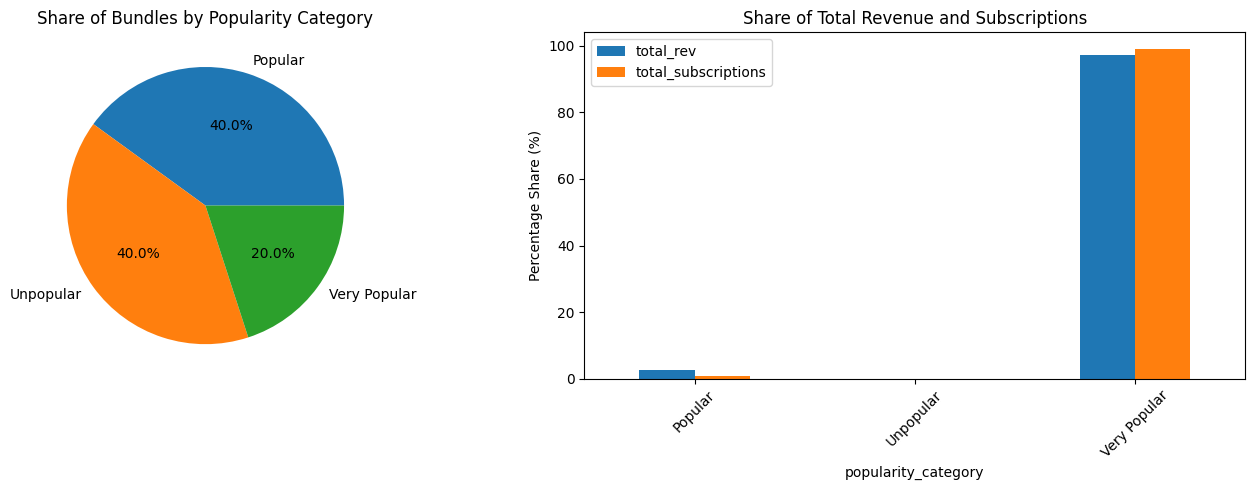

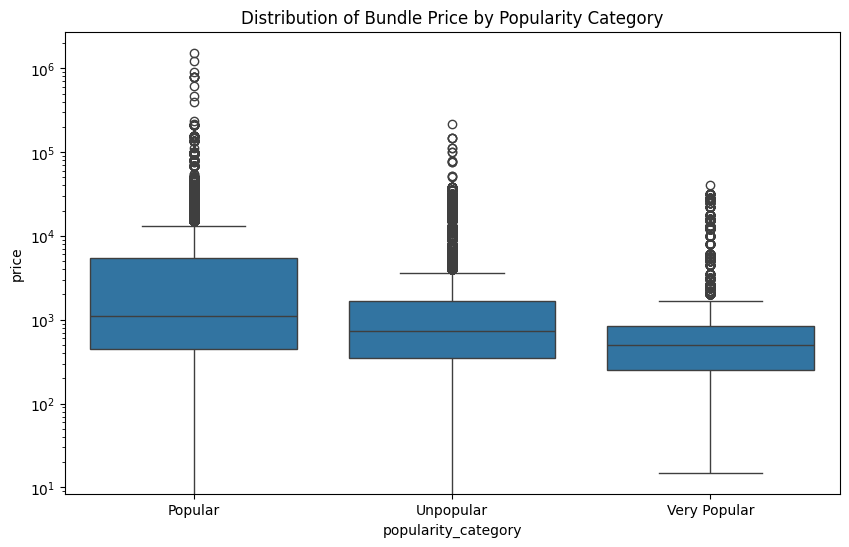

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

data['popularity_category'].value_counts().plot.pie(autopct='%1.1f%%', ax=ax1, title='Share of Bundles by Popularity Category')
ax1.set_ylabel('')

summary_df = data.groupby('popularity_category').agg({
    'total_rev': 'sum',
    'total_subscriptions': 'sum'
}).apply(lambda x: 100 * x / x.sum()) 

summary_df.plot.bar(ax=ax2, title='Share of Total Revenue and Subscriptions')
ax2.set_ylabel('Percentage Share (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='popularity_category', y='price')
plt.yscale('log') 
plt.title('Distribution of Bundle Price by Popularity Category')
plt.show()

* Building regression model. we will consider only the bundle features without bundle-name and embedding.

In [39]:
def prepare_bundle_training_data(df, target_col="popularity"):
    """
    - the extraction from bundle_name is used only as a fallback when the 
        structured input value is missing or 0, and otherwise the original structured
        value is kept.
    """
    data = df.copy()

    # Basic cleanup
    data.columns = [c.strip() for c in data.columns]
    data["bundle_name"] = data["bundle_name"].fillna("").astype(str)

    numeric_cols = [
        "week_number", "year_number", "price",
        "configured_volume_mb", "configured_volume_min", "configured_volume_sms",
        "validity_hours", "is_illimite"
    ]
    for c in numeric_cols:
        if c in data.columns:
            data[c] = pd.to_numeric(data[c], errors="coerce")

    # keep only rows with target
    data = data[data[target_col].notna()].copy()


    # Parse bundle_name
    def parse_bundle_name(name: str):
        s = str(name).lower().strip().replace(",", ".")
        out = {
            "parsed_volume_mb": np.nan,
            "parsed_volume_min": np.nan,
            "parsed_volume_sms": np.nan,
            "parsed_validity_hours": np.nan,
            "parsed_speed_mbps": np.nan,
            "name_has_data": 0,
            "name_has_voice": 0,
            "name_has_sms": 0,
            "name_has_unlimited": 0,
            "name_has_speed": 0,
            "name_has_social": 0,
            "name_has_roaming": 0,
        }

        # unlimited flags
        if re.search(r"\b(illimite|illimité|unlimited|illimix)\b", s):
            out["name_has_unlimited"] = 1

        # social / app flags
        if re.search(r"\b(whatsapp|tiktok|facebook|youtube|instagram|social)\b", s):
            out["name_has_social"] = 1

        # roaming flags
        if re.search(r"\b(roaming|hadj|voyage|travel)\b", s):
            out["name_has_roaming"] = 1

        # speed parsing: Mbps / Kbps
        m = re.search(r"(\d+(?:\.\d+)?)\s*(mbps|kbps)\b", s)
        if m:
            val = float(m.group(1))
            unit = m.group(2)
            out["parsed_speed_mbps"] = val if unit == "mbps" else val / 1000.0
            out["name_has_speed"] = 1

        # data parsing: GB/Go/Giga/MB/Mb
        data_matches = re.findall(r"(\d+(?:\.\d+)?)\s*(go|gb|giga|g|mb|mo)\b", s)
        if data_matches:
            # take the largest parsed volume if multiple are present
            mb_vals = []
            for val, unit in data_matches:
                val = float(val)
                unit = unit.lower()
                if unit in {"go", "gb", "giga", "g"}:
                    mb_vals.append(val * 1024.0)
                elif unit in {"mb", "mo"}:
                    mb_vals.append(val)
            if mb_vals:
                out["parsed_volume_mb"] = max(mb_vals)
                out["name_has_data"] = 1

        # voice parsing
        m = re.search(r"(\d+(?:\.\d+)?)\s*(min|mins|minute|minutes)\b", s)
        if m:
            out["parsed_volume_min"] = float(m.group(1))
            out["name_has_voice"] = 1

        # SMS parsing
        m = re.search(r"(\d+(?:\.\d+)?)\s*(sms)\b", s)
        if m:
            out["parsed_volume_sms"] = float(m.group(1))
            out["name_has_sms"] = 1

        # validity parsing
        # examples: 1 jour, 30 jours, 3 days, 6 mois, 9H
        m = re.search(r"(\d+(?:\.\d+)?)\s*(jour|jours|day|days|j)\b", s)
        if m:
            out["parsed_validity_hours"] = float(m.group(1)) * 24.0

        m = re.search(r"(\d+(?:\.\d+)?)\s*(mois|month|months)\b", s)
        if m:
            out["parsed_validity_hours"] = float(m.group(1)) * 30.0 * 24.0

        # only use hour parsing if day/month not already parsed
        if pd.isna(out["parsed_validity_hours"]):
            m = re.search(r"(\d+(?:\.\d+)?)\s*(h|hr|hrs|hour|hours)\b", s)
            if m:
                out["parsed_validity_hours"] = float(m.group(1))

        return out

    parsed = data["bundle_name"].apply(parse_bundle_name).apply(pd.Series)
    data = pd.concat([data, parsed], axis=1)


    # Final corrected structural values
    def choose_value(configured, parsed):
        if pd.notna(configured) and configured > 0:
            return configured, "configured"
        if pd.notna(parsed) and parsed > 0:
            return parsed, "parsed_name"
        return 0.0, "zero_or_unknown"

    mb_vals = data.apply(lambda r: choose_value(r.get("configured_volume_mb", np.nan), r["parsed_volume_mb"]), axis=1)
    min_vals = data.apply(lambda r: choose_value(r.get("configured_volume_min", np.nan), r["parsed_volume_min"]), axis=1)
    sms_vals = data.apply(lambda r: choose_value(r.get("configured_volume_sms", np.nan), r["parsed_volume_sms"]), axis=1)
    val_vals = data.apply(lambda r: choose_value(r.get("validity_hours", np.nan), r["parsed_validity_hours"]), axis=1)

    data["volume_mb"] = [x[0] for x in mb_vals]
    data["volume_min"] = [x[0] for x in min_vals]
    data["volume_sms"] = [x[0] for x in sms_vals]
    data["validity_hours"] = [x[0] for x in val_vals]

    data["mb_value_source"] = [x[1] for x in mb_vals]
    data["min_value_source"] = [x[1] for x in min_vals]
    data["sms_value_source"] = [x[1] for x in sms_vals]
    data["validity_value_source"] = [x[1] for x in val_vals]


    #  Special bundle flags
    data["is_unlimited_bundle"] = (
        (data["is_illimite"].fillna(0).astype(int) == 1) |
        (data["name_has_unlimited"] == 1)
    ).astype(int)

    data["is_speed_based_bundle"] = (data["name_has_speed"] == 1).astype(int)
    data["speed_mbps"] = data["parsed_speed_mbps"].fillna(0)

    # if speed bundle or unlimited bundle and quota is zero, keep zero but mark as valid special structure
    data["has_data"] = (data["volume_mb"] > 0).astype(int)
    data["has_voice"] = (data["volume_min"] > 0).astype(int)
    data["has_sms"] = (data["volume_sms"] > 0).astype(int)

    data["is_data_only"] = ((data["has_data"] == 1) & (data["has_voice"] == 0) & (data["has_sms"] == 0)).astype(int)
    data["is_voice_only"] = ((data["has_data"] == 0) & (data["has_voice"] == 1) & (data["has_sms"] == 0)).astype(int)
    data["is_sms_only"] = ((data["has_data"] == 0) & (data["has_voice"] == 0) & (data["has_sms"] == 1)).astype(int)
    data["is_combo_bundle"] = ((data[["has_data", "has_voice", "has_sms"]].sum(axis=1)) >= 2).astype(int)


    data["validity_days"] = data["validity_hours"] / 24.0
    data["validity_days"] = data["validity_days"].replace([np.inf, -np.inf], np.nan).fillna(0)

    data["log_price"] = np.log1p(data["price"].clip(lower=0))
    data["log_mb"] = np.log1p(data["volume_mb"].clip(lower=0))
    data["log_min"] = np.log1p(data["volume_min"].clip(lower=0))
    data["log_sms"] = np.log1p(data["volume_sms"].clip(lower=0))
    data["log_validity_hours"] = np.log1p(data["validity_hours"].clip(lower=0))

    # validity bucket
    data["validity_bucket"] = np.select(
        [
            data["validity_days"] <= 1,
            (data["validity_days"] > 1) & (data["validity_days"] <= 7),
            (data["validity_days"] > 7) & (data["validity_days"] <= 30),
            data["validity_days"] > 30
        ],
        [
            "daily",
            "weekly",
            "monthly",
            "long_term"
        ],
        default="unknown"
    )

    # simple cyclical time features
    week = data["week_number"].fillna(0)
    data["week_sin"] = np.sin(2 * np.pi * week / 52.0)
    data["week_cos"] = np.cos(2 * np.pi * week / 52.0)

    # optional portfolio-relative richness proxy
    data["bundle_value_proxy"] = (
        0.5 * data["log_mb"] +
        0.3 * data["log_min"] +
        0.2 * data["log_sms"]
    )


    # Clean categorical columns
    cat_cols = [
        "season", "bundle_type", "usage_type",
        "service_class_category", "validity_bucket"
    ]
    for c in cat_cols:
        if c in data.columns:
            data[c] = data[c].fillna("unknown").astype(str).str.strip()


    # Final feature list
    feature_cols = [
        # "week_number",
        "year_number",
        "week_sin",
        "week_cos",
        "season",
        "bundle_type",
        # "usage_type",
        "service_class_category",
        #"price",
        "log_price",
        #"volume_mb",
        #"volume_min",
        #"volume_sms",
        "log_mb",
        "log_min",
        "log_sms",
        #"validity_hours",
        "validity_days",
        "log_validity_hours",
        "validity_bucket",
        "has_data",
        "has_voice",
        "has_sms",
        "is_data_only",
        "is_voice_only",
        "is_sms_only",
        "is_combo_bundle",
        "is_unlimited_bundle",
        "is_speed_based_bundle",
        "speed_mbps",
        "name_has_social",
        "name_has_roaming",
    ]

    feature_cols = [c for c in feature_cols if c in data.columns]

    # Keep only needed columns + target for modeling
    keep_cols = feature_cols + [target_col, "bundle_id", "bundle_name"]
    keep_cols = [c for c in keep_cols if c in data.columns]
    df_model = data[keep_cols].copy()

    # Final cleanup
    num_cols = df_model.select_dtypes(include=[np.number]).columns
    df_model[num_cols] = df_model[num_cols].replace([np.inf, -np.inf], np.nan)

    # for tree models, keeping NaN can be okay; for linear models, fill them
    df_model[num_cols] = df_model[num_cols].fillna(0)

    return df_model, feature_cols


In [40]:
df_model, feature_cols = prepare_bundle_training_data(data, target_col="popularity")
print(df_model.shape)
print(feature_cols)

(37255, 28)
['year_number', 'week_sin', 'week_cos', 'season', 'bundle_type', 'service_class_category', 'log_price', 'log_mb', 'log_min', 'log_sms', 'validity_days', 'log_validity_hours', 'validity_bucket', 'has_data', 'has_voice', 'has_sms', 'is_data_only', 'is_voice_only', 'is_sms_only', 'is_combo_bundle', 'is_unlimited_bundle', 'is_speed_based_bundle', 'speed_mbps', 'name_has_social', 'name_has_roaming']


In [41]:
df_model.head(10)

,year_number,week_sin,week_cos,season,bundle_type,service_class_category,log_price,log_mb,log_min,log_sms,...,is_sms_only,is_combo_bundle,is_unlimited_bundle,is_speed_based_bundle,speed_mbps,name_has_social,name_has_roaming,popularity,bundle_id,bundle_name
0,2025,0.120537,0.992709,winter,BUNDLE_DATA,PREPAID,8.294300,7.402086,0.000000,0.0,...,0,0,0,0,0.0,0.0,0.0,0.307323,37076,Forfait 1.6Go 30 jours@4000F
1,2025,0.120537,0.992709,winter,INT_BUNDLE_VOICE,PREPAID,6.538140,0.000000,1.098612,0.0,...,0,0,0,0,0.0,0.0,0.0,0.234772,50134,Forfait appels RCA 2 mins 30 jours@690F
2,2025,0.120537,0.992709,winter,INT_BUNDLE_VOICE,PREPAID,5.303305,0.000000,1.098612,0.0,...,0,0,0,0,0.0,0.0,0.0,0.155463,50129,Forfait appels Nigeria 2 mins 30 jours@200F
3,2025,0.120537,0.992709,winter,BUNDLE_DATA,PREPAID,5.375278,5.141664,0.000000,0.0,...,0,0,0,0,0.0,0.0,0.0,0.413100,35070,Forfait 1 jour 170MB@215F
4,2025,0.120537,0.992709,winter,BUNDLE_DATA,PREPAID,10.820798,0.000000,0.000000,0.0,...,0,0,1,0,0.0,0.0,0.0,0.339628,36667,NDAKO BOX ILLIMITE@50050F
5,2025,0.120537,0.992709,winter,INT_BUNDLE_VOICE,PREPAID,7.313887,0.000000,2.397895,0.0,...,0,0,0,0,0.0,0.0,0.0,0.327224,50191,Int Bundle ROW 10min 30jours a 1500F
6,2025,0.120537,0.992709,winter,INT_BUNDLE_VOICE,PREPAID,6.381816,0.000000,1.098612,0.0,...,0,0,0,0,0.0,0.0,0.0,0.352477,50214,Forfait appels Guinee Conakry 2 mins 30 jours@...
7,2025,0.120537,0.992709,winter,BUNDLE_VOICE,PREPAID,5.225747,0.000000,2.484907,0.0,...,0,0,0,0,0.0,0.0,0.0,0.738287,80069,Ndeko_11Mins 1 jour@185F
9,2025,0.120537,0.992709,winter,BUNDLE_DATA,PREPAID,3.931826,5.525453,0.000000,0.0,...,0,0,0,0,0.0,0.0,0.0,0.338694,36279,Promo Back2School 250MB 2 Days @50F
11,2025,0.120537,0.992709,winter,BUNDLE_DATA,PREPAID,6.054439,0.000000,0.000000,0.0,...,0,0,0,0,0.0,0.0,0.0,0.531439,36602,Maxinet 3 Days 9H@425F


In [42]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split


def prepare_lgbm_train_test(
    df_model,
    target_col="popularity",
    test_size=0.2,
    random_state=42,
    use_time_split=True,
    rare_threshold=5
):
    """
    Prepare train/test data for LGBMRegressor.
    
    Returns:
        X_train, X_test, y_train, y_test
    Ready to pass into LightGBM.
    """

    feature_cols =  [
        # "week_number", +
        "season", "week_sin", "week_cos", "bundle_type", 
         # "price", #"usage_type", 
        "service_class_category",'log_price', 
        #'volume_mb', 'volume_min', 'volume_sms', 
        'log_mb', 'log_min', 'log_sms', 
        #'validity_hours', 
        'validity_days',
        'log_validity_hours', 'validity_bucket', 'has_data', 'has_voice', 'has_sms', 
        'is_data_only', 'is_voice_only', 'is_sms_only', 'is_combo_bundle', 
        'is_unlimited_bundle', 'name_has_social', 'name_has_roaming'
    ]
    categorical_cols = [
       "season", "bundle_type",
        "usage_type", "service_class_category", "validity_bucket"
    ]

    data = df_model.copy()

    # keep only needed columns that actually exist
    feature_cols = [c for c in feature_cols if c in data.columns]
    categorical_cols = [c for c in categorical_cols if c in feature_cols]

    keep_cols = feature_cols + [target_col]
    keep_cols = [c for c in keep_cols if c in data.columns]
    data = data[keep_cols].copy()

    # drop rows with missing target
    data = data[data[target_col].notna()].copy()

    # clean categorical columns
    for c in categorical_cols:
        data[c] = (
            data[c]
            .fillna("unknown")
            .astype(str)
            .str.strip()
            .replace("", "unknown")
        )

    # numeric columns
    numeric_cols = [c for c in feature_cols if c not in categorical_cols]
    for c in numeric_cols:
        data[c] = pd.to_numeric(data[c], errors="coerce")

    # target
    y = pd.to_numeric(data[target_col], errors="coerce")
    valid_mask = y.notna()
    data = data.loc[valid_mask].copy()
    y = y.loc[valid_mask].copy()

    X = data[feature_cols].copy()

 
    # Train / test split
    if use_time_split and {"year_number", "week_number"}.issubset(df_model.columns):
        # Use original df_model ordering by time if available
        temp = df_model.loc[X.index, ["year_number", "week_number"]].copy()
        temp["__idx__"] = X.index
        temp = temp.sort_values(["year_number", "week_number", "__idx__"])

        ordered_idx = temp["__idx__"].tolist()
        X = X.loc[ordered_idx].reset_index(drop=True)
        y = y.loc[ordered_idx].reset_index(drop=True)

        split_idx = int(len(X) * (1 - test_size))
        X_train = X.iloc[:split_idx].copy()
        X_test = X.iloc[split_idx:].copy()
        y_train = y.iloc[:split_idx].copy()
        y_test = y.iloc[split_idx:].copy()
    else:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y,
            test_size=test_size,
            random_state=random_state
        )
  
    # Fit preprocessing on train only
    # Fill numeric missing values with train medians
    train_medians = X_train[numeric_cols].median()
    X_train[numeric_cols] = X_train[numeric_cols].fillna(train_medians)
    X_test[numeric_cols] = X_test[numeric_cols].fillna(train_medians)

    # Handle rare categories using train only
    for c in categorical_cols:
        freq = X_train[c].value_counts(dropna=False)
        frequent_values = freq[freq >= rare_threshold].index

        X_train[c] = np.where(X_train[c].isin(frequent_values), X_train[c], "__RARE__")
        X_test[c] = np.where(X_test[c].isin(frequent_values), X_test[c], "__RARE__")

        # align category levels between train and test
        categories = sorted(pd.Series(X_train[c]).astype(str).unique().tolist())
        X_train[c] = pd.Categorical(X_train[c], categories=categories)
        X_test[c] = pd.Categorical(X_test[c], categories=categories)

    # Final numeric cleanup
    X_train[numeric_cols] = X_train[numeric_cols].replace([np.inf, -np.inf], 0)
    X_test[numeric_cols] = X_test[numeric_cols].replace([np.inf, -np.inf], 0)

    # reset index
    X_train = X_train.reset_index(drop=True)
    X_test = X_test.reset_index(drop=True)
    y_train = y_train.reset_index(drop=True)
    y_test = y_test.reset_index(drop=True)

    return X_train, X_test, y_train, y_test


X_train, X_test, y_train, y_test = prepare_lgbm_train_test(
    df_model,
    target_col="popularity",
    test_size=0.2,
    random_state=42,
    use_time_split=False,
    rare_threshold=5
)


In [43]:
X_train.head(10)

,season,week_sin,week_cos,bundle_type,service_class_category,log_price,log_mb,log_min,log_sms,validity_days,...,has_data,has_voice,has_sms,is_data_only,is_voice_only,is_sms_only,is_combo_bundle,is_unlimited_bundle,name_has_social,name_has_roaming
0,spring,0.970942,-0.239316,BUNDLE_DATA,STAFF,5.707110,6.552508,0.000000,0.0,3.0,...,1,0,0,1,0,0,0,0,0.0,0.0
1,spring,0.663123,-0.748511,BUNDLE_DATA,PREPAID,6.054439,0.000000,0.000000,0.0,3.0,...,0,0,0,0,0,0,0,0,0.0,0.0
2,winter,0.970942,0.239316,BUNDLE_VOICE,HYBRID,6.265301,0.000000,3.784190,0.0,7.0,...,0,1,0,0,1,0,0,0,0.0,0.0
3,winter,0.748511,0.663123,BUNDLE_DATA,PREPAID,7.863651,9.570599,0.000000,0.0,3.0,...,1,0,0,1,0,0,0,0,0.0,0.0
4,summer,-0.568065,-0.822984,BUNDLE_DATA,HYBRID,10.184938,13.241392,0.000000,0.0,30.0,...,1,0,0,1,0,0,0,0,0.0,0.0
5,winter,0.748511,0.663123,BUNDLE_DATA,PREPAID,5.303305,5.707110,0.000000,0.0,1.0,...,1,0,0,1,0,0,0,0,0.0,0.0
6,summer,-0.822984,-0.568065,BUNDLE_DATA,HYBRID,6.685861,7.625107,0.000000,0.0,1.0,...,1,0,0,1,0,0,0,0,0.0,0.0
7,summer,-0.992709,-0.120537,BUNDLE_VOICE,HYBRID,7.090910,0.000000,5.023881,0.0,7.0,...,0,1,0,0,1,0,0,0,0.0,0.0
8,spring,0.885456,-0.464723,BUNDLE_DATA,HYBRID,7.003974,7.848153,0.000000,0.0,1.0,...,1,0,0,1,0,0,0,0,0.0,0.0
9,autumn,-0.822984,0.568065,INT_BUNDLE_VOICE,PREPAID,7.313887,0.000000,2.772589,0.0,30.0,...,0,1,0,0,1,0,0,0,0.0,0.0


In [44]:
from lightgbm import LGBMRegressor

cat_cols = [
    "season", "bundle_type",
    "usage_type", "service_class_category", "validity_bucket"
]
cat_cols = [c for c in cat_cols if c in X_train.columns]

Pmodel = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

Pmodel.fit(
    X_train,
    y_train,
    categorical_feature=cat_cols
)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000520 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 744
[LightGBM] [Info] Number of data points in the train set: 29804, number of used features: 21
[LightGBM] [Info] Start training from score 0.341818


LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05, n_estimators=500,
              random_state=42, subsample=0.8)

In [45]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


def evaluate_regression_model(model, X_test, y_test, return_predictions=False):
    y_true = pd.Series(y_test).reset_index(drop=True).astype(float)
    y_pred = pd.Series(model.predict(X_test)).reset_index(drop=True).astype(float)

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    # avoid division by zero in MAPE
    non_zero_mask = y_true != 0
    if non_zero_mask.sum() > 0:
        mape = (
            np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask]).mean()
            * 100
        )
    else:
        mape = np.nan

    metrics = {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "MAPE_percent": mape
    }

    print("Model Evaluation Results")
    print("-" * 30)
    for k, v in metrics.items():
        print(f"{k}: {v:.6f}" if pd.notna(v) else f"{k}: NaN")

    if return_predictions:
        preds_df = pd.DataFrame({
            "actual": y_true,
            "predicted": y_pred,
            "abs_error": np.abs(y_true - y_pred)
        })
        return metrics, preds_df

    return metrics


metrics, preds_df = evaluate_regression_model(
    Pmodel, X_test, y_test, return_predictions=True
)

Model Evaluation Results
------------------------------
MAE: 0.038551
MSE: 0.003508
RMSE: 0.059231
R2: 0.847617
MAPE_percent: 14.028409


In [38]:
preds_df.head(10)

,actual,predicted,abs_error
0,0.407674,0.351114,0.056560
1,0.456061,0.436116,0.019945
2,0.353076,0.287352,0.065724
3,0.337118,0.321744,0.015375
4,0.316993,0.265789,0.051204
5,0.287706,0.564329,0.276622
6,0.442413,0.459655,0.017242
7,0.467564,0.442270,0.025294
8,0.364561,0.328590,0.035970
9,0.344457,0.382774,0.038316


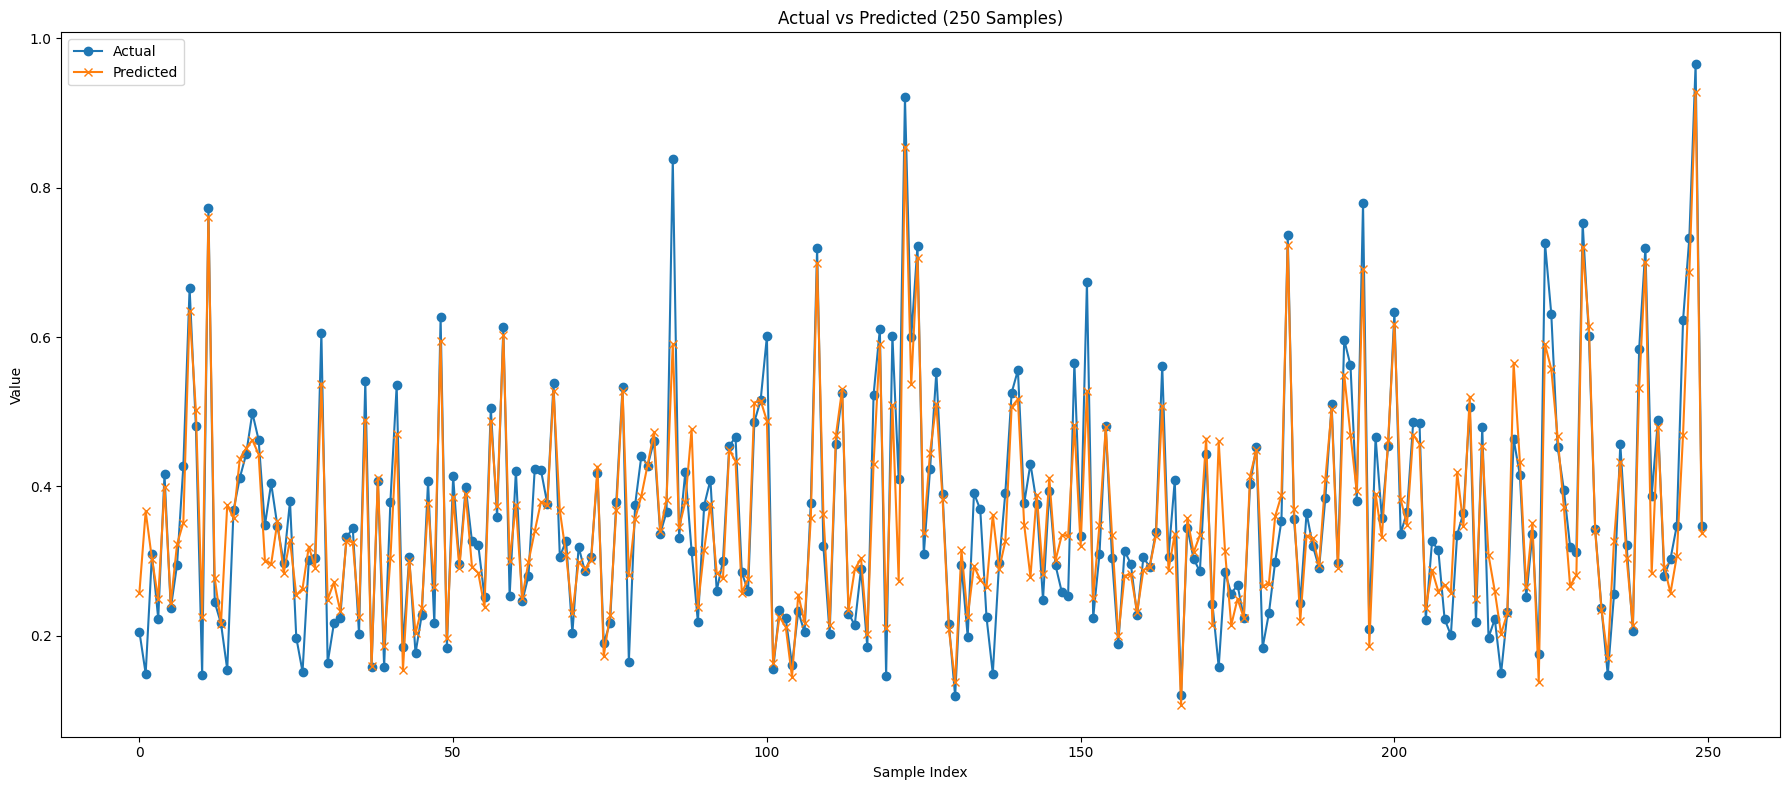

In [31]:
fig, axes = plt.subplots(1, 1, figsize=(18, 8))

sample_size = 250
sample_df = preds_df.sample(sample_size).reset_index(drop=True)
axes.plot(sample_df.index, sample_df["actual"], label="Actual", marker='o')
axes.plot(sample_df.index, sample_df["predicted"], label="Predicted", marker='x')
axes.set_title(f"Actual vs Predicted ({sample_size} Samples)")
axes.set_xlabel("Sample Index")
axes.set_ylabel("Value")
axes.legend()

plt.tight_layout()
plt.show()


In [32]:
"""import joblib

joblib.dump({
    "model": Pmodel,
}, "popularity_model.pkl")
"""

'import joblib\n\njoblib.dump({\n    "model": Pmodel,\n}, "popularity_model.pkl")\n'

In [33]:
df_model.head(10)

,week_number,year_number,week_sin,week_cos,season,bundle_type,usage_type,service_class_category,price,log_price,...,is_sms_only,is_combo_bundle,is_unlimited_bundle,is_speed_based_bundle,speed_mbps,name_has_social,name_has_roaming,popularity,bundle_id,bundle_name
0,1,2025,0.120537,0.992709,winter,BUNDLE_DATA,CHARGED,PREPAID,4000.0,8.294300,...,0,0,0,0,0.0,0.0,0.0,0.307323,37076,Forfait 1.6Go 30 jours@4000F
1,1,2025,0.120537,0.992709,winter,INT_BUNDLE_VOICE,CHARGED,PREPAID,690.0,6.538140,...,0,0,0,0,0.0,0.0,0.0,0.234772,50134,Forfait appels RCA 2 mins 30 jours@690F
2,1,2025,0.120537,0.992709,winter,INT_BUNDLE_VOICE,CHARGED,PREPAID,200.0,5.303305,...,0,0,0,0,0.0,0.0,0.0,0.155463,50129,Forfait appels Nigeria 2 mins 30 jours@200F
3,1,2025,0.120537,0.992709,winter,BUNDLE_DATA,CHARGED,PREPAID,215.0,5.375278,...,0,0,0,0,0.0,0.0,0.0,0.413100,35070,Forfait 1 jour 170MB@215F
4,1,2025,0.120537,0.992709,winter,BUNDLE_DATA,CHARGED,PREPAID,50050.0,10.820798,...,0,0,1,0,0.0,0.0,0.0,0.339628,36667,NDAKO BOX ILLIMITE@50050F
5,1,2025,0.120537,0.992709,winter,INT_BUNDLE_VOICE,CHARGED,PREPAID,1500.0,7.313887,...,0,0,0,0,0.0,0.0,0.0,0.327224,50191,Int Bundle ROW 10min 30jours a 1500F
6,1,2025,0.120537,0.992709,winter,INT_BUNDLE_VOICE,CHARGED,PREPAID,590.0,6.381816,...,0,0,0,0,0.0,0.0,0.0,0.352477,50214,Forfait appels Guinee Conakry 2 mins 30 jours@...
7,1,2025,0.120537,0.992709,winter,BUNDLE_VOICE,CHARGED,PREPAID,185.0,5.225747,...,0,0,0,0,0.0,0.0,0.0,0.738287,80069,Ndeko_11Mins 1 jour@185F
9,1,2025,0.120537,0.992709,winter,BUNDLE_DATA,CHARGED,PREPAID,50.0,3.931826,...,0,0,0,0,0.0,0.0,0.0,0.338694,36279,Promo Back2School 250MB 2 Days @50F
11,1,2025,0.120537,0.992709,winter,BUNDLE_DATA,CHARGED,PREPAID,425.0,6.054439,...,0,0,0,0,0.0,0.0,0.0,0.531439,36602,Maxinet 3 Days 9H@425F


### Pricing Algorithm

In [34]:
PRICING_CONFIG = {
    'services': {
        'voice': {
            'anchor_price': 200,
            'anchor_rate': 13.3,
            'floor_rate': 6.0,
            'max_price': 10000,
            'unit_name': 'Minutes',
            'daily_points': [
                [100, 20.0], [150, 16.67], [175, 15.91], [200, 12.5], [220, 12.22],
                [230, 12.11], [300, 10.71], [450, 8.82], [540, 8.44], [750, 7.14], [800, 6.67]
            ],
            'weekly_points': [
                [300, 18.75], [420, 14.0], [525, 12.21], [650, 10.83], [750, 10.0],
                [840, 9.13], [935, 8.90], [1650, 7.5], [3520, 7.04], [5000, 6.25], [5390, 6.19]
            ],
            'decay_k': None
        },
        'data': {
            'anchor_price': 650,
            'anchor_rate': 0.42,
            'floor_rate': 0.2,
            'max_price': 10000,
            'unit_name': 'MB',
            'daily_points': [
                [100, 2.0], [190, 1.583], [220, 1.294], [290, 1.16], [650, 0.42]
            ],
            'decay_k': None
        },
        'sms': {
            'anchor_price': 50,
            'anchor_rate': 1.3,
            'floor_rate': 0.2,
            'max_price': 500,
            'unit_name': 'SMS',
            'decay_k': None
        }
    },
    'validity_premiums': {
        1: 0,
        2: 25,
        3: 50,
        7: 120,
        30: 235
    },
    'mixed_bundle_discounts': {
        1: 0,
        2: 10,
        3: 20
    },
    'btl_discounts': {
        'atl': 0,
        'diy_mode': -5,
        'promotion_mode':0,
        'btl_normal': 20,
        'btl_moderate': 30,
        'btl_aggressive': 40
    },
    'rounding_rules': {
        'data_round_to': 5
    },
    'minimums': {
        'price': {'voice': 100, 'data': 100},
        'volume': {'voice': 5, 'data': 50},
        'multi_service_volume': {'voice': 5, 'data': 50, 'sms': 0}
    },
    'promotion_mode_param': {
        'voice': {'starting_price': 150, 'ending_price': 2000,'discount':35,'validity':-1},
        'data': {'starting_price': 0, 'ending_price': 0,'discount':0,'validity':-1},
        'sms': {'starting_price': 0, 'ending_price': 0,'discount':0,'validity':-1},
    }
}

import math
import logging
from typing import List, Tuple, Dict


Point = Tuple[float, float]
Points = List[Point]
PremiumConfig = Dict[int, float]


class PricingMath:

    @staticmethod
    def recalculate_decay(
        anchor_price: float,
        anchor_rate: float,
        floor_rate: float,
        max_price: float
    ) -> float:
        if anchor_rate <= floor_rate or max_price <= anchor_price:
            return math.nan
    
        rate_at_max = floor_rate + 0.01
        numerator = math.log(
            (rate_at_max - floor_rate) /
            (anchor_rate - floor_rate)
        )
        denominator = max_price - anchor_price

        return -numerator / denominator


    @staticmethod
    def interpolate(
        x: float,
        points: Points
    ) -> float:
        if x < points[0][0]:
            x1, y1 = points[0]
            x2, y2 = points[1]
            slope = (y2 - y1) / (x2 - x1) if (x2 - x1) != 0 else 0

            return y1 + (x - x1) * slope

        for i in range(len(points) - 1):
            x1, y1 = points[i]
            x2, y2 = points[i + 1]
            if x1 <= x < x2:
                return y1 + (x - x1) * (y2 - y1) / (x2 - x1)

        return points[-1][1]


    @staticmethod
    def get_vpm(
        validity_days: int,
        premiums_config: PremiumConfig
    ) -> float:
        points = sorted(
            [(int(k), v) for k, v in premiums_config.items()]
        )

        premium = PricingMath.interpolate(validity_days, points)

        return 1 + premium / 100.0


import math
import logging
from typing import Dict, List, Tuple, Any


Point = Tuple[float, float]
Points = List[Point]

ServiceConfig = Dict[str, Any]
ServicesConfig = Dict[str, ServiceConfig]

PricingConfig = Dict[str, Any]
ServiceAllocations = Dict[str, float]
TargetVolumes = Dict[str, float]


class DynamicPricingEngine:

    def __init__(self, config: Dict[str, Any]) -> None:
        self.config: Dict[str, Any] = config

    def calculate_volume_from_price(
        self,
        price: float,
        service: str,
        validity_days: int,
        num_services: int,
        offer_type: str,
        mbdf_per: float
    ) -> float:
        s_config: Dict[str, Any] = self.config['services'][service]

        mbdf: float = 1 - (
            mbdf_per
            * self.config['mixed_bundle_discounts'].get(2, 0)
            / 100.0
        )

        starting_price: float = self.config['promotion_mode_param'][service].get('starting_price', 0)
        ending_price: float = self.config['promotion_mode_param'][service].get('ending_price', 0)
        promo_val: int = self.config['promotion_mode_param'][service].get('validity', 0)

        if (
            num_services == 1
            and offer_type == 'promotion_mode'
            and price >= starting_price
            and price <= ending_price
            and (promo_val == -1 or promo_val == validity_days)
        ):
            tdf: float = 1 - (
                self.config['promotion_mode_param'][service]
                .get('discount', 0) / 100.0
            )

        else:
            tdf = 1 - (
                self.config['btl_discounts'].get(offer_type, 0) / 100.0
            )

        if s_config.get('decay_k') is None:
            s_config['decay_k'] = PricingMath.recalculate_decay(
                s_config['anchor_price'],
                s_config['anchor_rate'],
                s_config['floor_rate'],
                s_config['max_price']
            )

        final_er: float = 0

        if service == 'voice':
            points = (
                s_config['weekly_points']
                if validity_days == 7
                else s_config['daily_points']
            )
            last_price_point: float = points[-1][0]

            if price > last_price_point:
                k: float = s_config['decay_k']
                er_price: float = (
                    s_config['floor_rate']
                    + (points[-1][1] - s_config['floor_rate'])
                    * math.exp(-k * (price - last_price_point))
                )

            else:
                er_price = PricingMath.interpolate(price, points)

            final_er = (
                er_price
                if validity_days == 7
                else er_price * PricingMath.get_vpm(
                    validity_days,
                    self.config['validity_premiums']
                )
            )

        elif service == 'data':
            if price <= s_config['anchor_price']:
                er_price_base: float = PricingMath.interpolate(
                    price,
                    s_config['daily_points']
                )

            else:
                k: float = s_config['decay_k']
                er_price_base = (
                    s_config['floor_rate']
                    + (s_config['anchor_rate'] - s_config['floor_rate'])
                    * math.exp(-k * (price - s_config['anchor_price']))
                )

            final_er = er_price_base * PricingMath.get_vpm(
                validity_days,
                self.config['validity_premiums']
            )

        else:
            k: float = s_config['decay_k']
            er_price: float = (
                s_config['floor_rate']
                + (s_config['anchor_rate'] - s_config['floor_rate'])
                * math.exp(-k * (price - s_config['anchor_price']))
            )

            final_er = er_price * PricingMath.get_vpm(
                validity_days,
                self.config['validity_premiums']
            )

        ultimate_er: float = final_er * mbdf * tdf

        return price / ultimate_er if ultimate_er > 0 else 0


    def calculate_bundle(
        self,
        service_allocations: Dict[str, float],
        validity_days: int,
        offer_type: str
    ) -> Dict[str, Dict[str, str]]:
        active_services: Dict[str, float] = {
            s: p for s, p in service_allocations.items() if p > 0
        }

        num_services: int = len(active_services)
        sorted_keys = sorted(active_services, key=active_services.get)

        smallest_ser: Dict[str, int] = {
            k: (1 if i < num_services - 1 else 0)
            for i, k in enumerate(sorted_keys)
        }

        final_offer: Dict[str, Dict[str, str]] = {'units': {}}

        for service, price in active_services.items():
            units: float = self.calculate_volume_from_price(
                price,
                service,
                validity_days,
                num_services,
                offer_type,
                smallest_ser[service]
            )

            s_config = self.config['services'][service]

            if service == 'data':
                rounded_units: int = (
                    math.ceil(
                        units
                        / self.config['rounding_rules']['data_round_to']
                    )
                    * self.config['rounding_rules']['data_round_to']
                )

            else:
                rounded_units = round(units)

            final_offer['units'][service] = f"{rounded_units} {s_config['unit_name']}"

        return final_offer


    def find_price_for_volume(
        self,
        service: str,
        target_volume: float,
        validity_days: int,
        offer_type: str,
        num_services: int,
        mbdf_per: float
    ) -> float:
        s_config = self.config['services'][service]

        low_price: float = 0.01
        high_price: float = s_config['max_price']

        for _ in range(100):
            guess_price: float = (low_price + high_price) / 2
            volume: float = self.calculate_volume_from_price(
                guess_price,
                service,
                validity_days,
                num_services,
                offer_type,
                mbdf_per
            )

            if service == 'data':
                rounded_units: int = (
                    math.ceil(
                        volume
                        / self.config['rounding_rules']['data_round_to']
                    )
                    * self.config['rounding_rules']['data_round_to']
                )

            else:
                rounded_units = round(volume)

            if rounded_units < target_volume:
                low_price = guess_price

            else:
                high_price = guess_price

            if (high_price - low_price) < 0.001:
                break

        return high_price


    def calculate_price_from_volume(
        self,
        target_volumes: Dict[str, float],
        validity_days: int,
        offer_type: str
    ) -> Dict[str, Any]:
        active_services: Dict[str, float] = {
            s: v for s, v in target_volumes.items() if v > 0
        }

        num_services: int = len(active_services)
        service_prices: Dict[str, float] = {
            service: active_services[service]
            * self.config['services'][service]['anchor_rate']
            for service in active_services
        }

        sorted_keys = sorted(service_prices, key=service_prices.get)
        smallest_ser: Dict[str, int] = {
            k: (1 if i < num_services - 1 else 0)
            for i, k in enumerate(sorted_keys)
        }

        if num_services > 1:
            for service, volume in active_services.items():
                min_vol = self.config['minimums']['multi_service_volume'].get(service)

                if min_vol and volume < min_vol:
                    return {
                        'error': f"Error: Minimum for {service} in a multi-buy is {min_vol}."
                    }

        individual_prices: Dict[str, float] = {}
        sub_total_price: float = 0
        for service, volume in active_services.items():
            price: float = self.find_price_for_volume(
                service,
                volume,
                validity_days,
                offer_type,
                num_services,
                smallest_ser[service]
            )

            min_price = self.config['minimums']['price'].get(service)
            final_price: float = price if min_price is None or price >= min_price else min_price
            individual_prices[service] = final_price
            sub_total_price += final_price

        final_total_price: int = round(sub_total_price)

        return {
            'calculated_price': final_total_price,
            'individual_prices': individual_prices
        }


### CTGANs to generate new bundles


now generte new bundles and filter them using popularity model

In [35]:
DATA_PATH: str =  r"..\..\datasets\product_profile\dim_product.csv"

products = pd.read_csv(DATA_PATH)
products.shape

(1415, 12)

In [36]:
# remove free bundes
products = products[~((~products['product_category'].isna()) & (products['product_category'].str.contains("BONUS")))]
products.shape

(1158, 12)

In [37]:
products["price"] = products["price"].apply(clean_price)

In [38]:
products.head()

,bundle_id,bundle_name,product_category,category_description,usage_type,configured_volume,speed,business_categorisation,price,bundle_type,validity,service_class_category
0,80109,Inbound Voice Acceleration 175 mins 30Jours@2400F,BUNDLE_VOICE,CVM VOICE ACCELERATION,CHARGED,175mins,NaN,CVM Voice Acceleration,2400.0,BUNDLE_VOICE,30 days,PREPAID
1,50188,Int Bundle ASIA and AMERICA 30min 30jours@1200F,INT_BUNDLE_VOICE,ASIA AND AMERICA,CHARGED,30MIN,NaN,ASIA and AMERICA,1200.0,INT_BUNDLE_VOICE,30 days,PREPAID
5,35123,MTNBIZ+ 150GB@35000F,BUNDLE_DATA,LTEBUSINESS,CHARGED,150GB,NaN,EBU,35000.0,BUNDLE_DATA,30 days,HYBRID
6,50096,Forfait appels Senegal 5 mins 30 jours@1200F,INT_BUNDLE_VOICE,EBU INTERNATIONAL VOICE BUNDLE,CHARGED,5MIN,NaN,EBU_INT_VOICE_BUNDLE,1200.0,INT_BUNDLE_VOICE,30 days,PREPAID
7,36985,Ndeko Mix 300Mins + 7GB 7 jours@11000F,BUNDLE_DATA,NDEKO MIX,CHARGED,7GB,NaN,Ndeko Mix,11000.0,BUNDLE_DATA,7 days,PREPAID


In [39]:
def prepare_products_for_inference(
    products_df,
    model,
    model_features,
    year=2025,
    week=1
):
    import numpy as np
    import pandas as pd
    import re

    df = products_df.copy()

    # -----------------------------
    # 1. BASIC CLEANING
    # -----------------------------
    df.columns = [c.strip() for c in df.columns]

    df["bundle_name"] = df["bundle_name"].fillna("").astype(str)
    df["usage_type"] = df["usage_type"].fillna("unknown")
    df["service_class_category"] = df["service_class_category"].fillna("unknown")
    df["bundle_type"] = df["bundle_type"].fillna("unknown")

    # -----------------------------
    # 2. PRICE
    # -----------------------------
    def clean_price(val):
        if pd.isna(val):
            return None
        val = str(val).replace("F", "").replace(",", "")
        try:
            return float(val)
        except:
            return None

    def extract_price(text):
        match = re.search(r'@(\d+)\s*F', str(text))
        return float(match.group(1)) if match else None

    df["price"] = df["price"].apply(clean_price)
    df.loc[df["price"].isna(), "price"] = df.loc[df["price"].isna(), "bundle_name"].apply(extract_price)
    df["price"] = df["price"].fillna(0)

    # -----------------------------
    # 3. VOLUME EXTRACTION
    # -----------------------------
    def extract_conf_volume_values(volume_str):
        if pd.isna(volume_str):
            return {'mb': 0, 'min': 0, 'sms': 0}

        s = str(volume_str).upper()

        mb, mins, sms = 0, 0, 0

        gb = re.findall(r'(\d+(\.\d+)?)\s*G', s)
        if gb:
            mb += sum(float(x[0]) for x in gb) * 1024

        mb_match = re.findall(r'(\d+(\.\d+)?)\s*MB', s)
        if mb_match:
            mb += sum(float(x[0]) for x in mb_match)

        min_match = re.findall(r'(\d+(\.\d+)?)\s*MIN', s)
        if min_match:
            mins += sum(float(x[0]) for x in min_match)

        sms_match = re.findall(r'(\d+(\.\d+)?)\s*SMS', s)
        if sms_match:
            sms += sum(float(x[0]) for x in sms_match)

        return {'mb': mb, 'min': mins, 'sms': sms}

    volume = df["configured_volume"].apply(extract_conf_volume_values)
    df["volume_mb"] = volume.apply(lambda x: x["mb"])
    df["volume_min"] = volume.apply(lambda x: x["min"])
    df["volume_sms"] = volume.apply(lambda x: x["sms"])

    # -----------------------------
    # 4. VALIDITY
    # -----------------------------
    def parse_validity(val):
        if pd.isna(val):
            return 0
        s = str(val).lower()

        m = re.search(r'(\d+)', s)
        if not m:
            return 0

        num = float(m.group(1))

        if "day" in s:
            return num * 24
        if "month" in s:
            return num * 30 * 24
        if "hour" in s:
            return num
        return num * 24

    df["validity_hours"] = df["validity"].apply(parse_validity)
    df["validity_days"] = df["validity_hours"] / 24

    # -----------------------------
    # 5. TIME FEATURES
    # -----------------------------
    df["week_number"] = week
    df["year_number"] = year

    df["week_sin"] = np.sin(2 * np.pi * week / 52)
    df["week_cos"] = np.cos(2 * np.pi * week / 52)

    def week_to_season(w):
        if w <= 13: return "winter"
        elif w <= 26: return "spring"
        elif w <= 39: return "summer"
        else: return "autumn"

    df["season"] = week_to_season(week)

    # -----------------------------
    # 6. NAME PARSING
    # -----------------------------
    def parse_bundle_name(name):
        s = name.lower()

        return {
            "is_unlimited_bundle": int(bool(re.search(r"illimite|unlimited", s))),
            "name_has_social": int(bool(re.search(r"whatsapp|facebook|youtube", s))),
            "name_has_roaming": int(bool(re.search(r"roaming|voyage", s))),
        }

    parsed = df["bundle_name"].apply(parse_bundle_name).apply(pd.Series)
    df = pd.concat([df, parsed], axis=1)

    # -----------------------------
    # 7. STRUCTURAL FLAGS
    # -----------------------------
    df["has_data"] = (df["volume_mb"] > 0).astype(int)
    df["has_voice"] = (df["volume_min"] > 0).astype(int)
    df["has_sms"] = (df["volume_sms"] > 0).astype(int)

    df["is_data_only"] = ((df["has_data"] == 1) & (df["has_voice"] == 0)).astype(int)
    df["is_voice_only"] = ((df["has_voice"] == 1) & (df["has_data"] == 0)).astype(int)
    df["is_sms_only"] = ((df["has_sms"] == 1) & (df["has_data"] == 0)).astype(int)
    df["is_combo_bundle"] = ((df[["has_data","has_voice","has_sms"]].sum(axis=1)) >= 2).astype(int)

    # -----------------------------
    # 8. LOG FEATURES (SAFE)
    # -----------------------------
    df["log_price"] = np.log1p(df["price"].clip(lower=0))
    df["log_mb"] = np.log1p(df["volume_mb"].clip(lower=0))
    df["log_min"] = np.log1p(df["volume_min"].clip(lower=0))
    df["log_sms"] = np.log1p(df["volume_sms"].clip(lower=0))
    df["log_validity_hours"] = np.log1p(df["validity_hours"].clip(lower=0))

    # -----------------------------
    # 9. VALIDITY BUCKET
    # -----------------------------
    df["validity_bucket"] = np.select(
        [
            df["validity_days"] <= 1,
            df["validity_days"] <= 7,
            df["validity_days"] <= 30,
            df["validity_days"] > 30
        ],
        ["daily", "weekly", "monthly", "long_term"],
        default="unknown"
    )

    # -----------------------------
    # 10. STRICT FEATURE ALIGNMENT
    # -----------------------------
    X = df.copy()

    for col in model_features:
        if col not in X.columns:
            X[col] = 0

    X = X[model_features].copy()
    X = X.reindex(columns=model_features)

    # -----------------------------
    # 11. CLEAN NUMERIC / CATEGORICAL
    # -----------------------------
    num_cols = X.select_dtypes(include=[np.number]).columns
    cat_cols = X.select_dtypes(include=["object", "category"]).columns

    X[num_cols] = X[num_cols].replace([np.inf, -np.inf], 0)
    X[num_cols] = X[num_cols].fillna(0)

    for c in cat_cols:
        X[c] = X[c].astype(str).fillna("unknown")
        X[c] = X[c].replace("", "unknown")
        X[c] = X[c].astype("category")

    # -----------------------------
    # 12. PREDICT
    # -----------------------------
    preds = model.predict(X)

    df["predicted_popularity"] = preds

    return df

In [40]:
MODEL_FEATURES = X_train.columns.tolist()

products_scored = prepare_products_for_inference(
    products_df=products,
    model=Pmodel,
    model_features=MODEL_FEATURES,
    week=1
)
products_scored.shape

(1158, 39)

In [41]:
products_scored.head(10)

,bundle_id,bundle_name,product_category,category_description,usage_type,configured_volume,speed,business_categorisation,price,bundle_type,...,is_voice_only,is_sms_only,is_combo_bundle,log_price,log_mb,log_min,log_sms,log_validity_hours,validity_bucket,predicted_popularity
0,80109,Inbound Voice Acceleration 175 mins 30Jours@2400F,BUNDLE_VOICE,CVM VOICE ACCELERATION,CHARGED,175mins,NaN,CVM Voice Acceleration,2400.0,BUNDLE_VOICE,...,1,0,0,7.783641,0.000000,5.170484,0.0,6.580639,monthly,0.271189
1,50188,Int Bundle ASIA and AMERICA 30min 30jours@1200F,INT_BUNDLE_VOICE,ASIA AND AMERICA,CHARGED,30MIN,NaN,ASIA and AMERICA,1200.0,INT_BUNDLE_VOICE,...,1,0,0,7.090910,0.000000,3.433987,0.0,6.580639,monthly,0.273977
5,35123,MTNBIZ+ 150GB@35000F,BUNDLE_DATA,LTEBUSINESS,CHARGED,150GB,NaN,EBU,35000.0,BUNDLE_DATA,...,0,0,0,10.463132,11.942114,0.000000,0.0,6.580639,monthly,0.289269
6,50096,Forfait appels Senegal 5 mins 30 jours@1200F,INT_BUNDLE_VOICE,EBU INTERNATIONAL VOICE BUNDLE,CHARGED,5MIN,NaN,EBU_INT_VOICE_BUNDLE,1200.0,INT_BUNDLE_VOICE,...,1,0,0,7.090910,0.000000,1.791759,0.0,6.580639,monthly,0.243234
7,36985,Ndeko Mix 300Mins + 7GB 7 jours@11000F,BUNDLE_DATA,NDEKO MIX,CHARGED,7GB,NaN,Ndeko Mix,11000.0,BUNDLE_DATA,...,0,0,0,9.305741,8.877521,0.000000,0.0,5.129899,weekly,0.393973
8,50014,Forfait appels Senegal 2 mins 30 jours @490F,INT_BUNDLE_VOICE,VOICE INTERNATIONAL BUNDLE,CHARGED,2MIN,NaN,NaN,490.0,INT_BUNDLE_VOICE,...,1,0,0,6.196444,0.000000,1.098612,0.0,6.580639,monthly,0.270062
9,35502,Forfait LTE Business 30 jours 2 mbps@80050F,BUNDLE_DATA,LTEBUSINESS,CHARGED,Unlimited,2Mbps,EBU,80050.0,BUNDLE_DATA,...,0,0,0,11.290419,0.000000,0.000000,0.0,6.580639,monthly,0.335345
10,37333,NEW RESIDENTIAL@18500F,BUNDLE_DATA,RESIDENTIAL,CHARGED,90GB,15Mbps,Residential Offer,18500.0,BUNDLE_DATA,...,0,0,0,9.825580,11.431292,0.000000,0.0,6.580639,monthly,0.291550
11,50203,Forfait appels Liban 3 mins 45sec 30 jours@350F,INT_BUNDLE_VOICE,VOICE INTERNATIONAL BUNDLE,CHARGED,3MIN,NaN,VOICE INTERNATIONAL BUNDLE,350.0,INT_BUNDLE_VOICE,...,1,0,0,5.860786,0.000000,1.386294,0.0,6.580639,monthly,0.293247
12,35260,SHart + Extra Entreprise H4@100700,BUNDLE_DATA,SMARTBUSINESS,CHARGED,10240MB,NaN,Smart Combo Platinium,100700.0,BUNDLE_DATA,...,0,0,0,11.519911,9.234155,0.000000,0.0,6.580639,monthly,0.235752


In [42]:
df_model.head(10)

,week_number,year_number,week_sin,week_cos,season,bundle_type,usage_type,service_class_category,price,log_price,...,is_sms_only,is_combo_bundle,is_unlimited_bundle,is_speed_based_bundle,speed_mbps,name_has_social,name_has_roaming,popularity,bundle_id,bundle_name
0,1,2025,0.120537,0.992709,winter,BUNDLE_DATA,CHARGED,PREPAID,4000.0,8.294300,...,0,0,0,0,0.0,0.0,0.0,0.307323,37076,Forfait 1.6Go 30 jours@4000F
1,1,2025,0.120537,0.992709,winter,INT_BUNDLE_VOICE,CHARGED,PREPAID,690.0,6.538140,...,0,0,0,0,0.0,0.0,0.0,0.234772,50134,Forfait appels RCA 2 mins 30 jours@690F
2,1,2025,0.120537,0.992709,winter,INT_BUNDLE_VOICE,CHARGED,PREPAID,200.0,5.303305,...,0,0,0,0,0.0,0.0,0.0,0.155463,50129,Forfait appels Nigeria 2 mins 30 jours@200F
3,1,2025,0.120537,0.992709,winter,BUNDLE_DATA,CHARGED,PREPAID,215.0,5.375278,...,0,0,0,0,0.0,0.0,0.0,0.413100,35070,Forfait 1 jour 170MB@215F
4,1,2025,0.120537,0.992709,winter,BUNDLE_DATA,CHARGED,PREPAID,50050.0,10.820798,...,0,0,1,0,0.0,0.0,0.0,0.339628,36667,NDAKO BOX ILLIMITE@50050F
5,1,2025,0.120537,0.992709,winter,INT_BUNDLE_VOICE,CHARGED,PREPAID,1500.0,7.313887,...,0,0,0,0,0.0,0.0,0.0,0.327224,50191,Int Bundle ROW 10min 30jours a 1500F
6,1,2025,0.120537,0.992709,winter,INT_BUNDLE_VOICE,CHARGED,PREPAID,590.0,6.381816,...,0,0,0,0,0.0,0.0,0.0,0.352477,50214,Forfait appels Guinee Conakry 2 mins 30 jours@...
7,1,2025,0.120537,0.992709,winter,BUNDLE_VOICE,CHARGED,PREPAID,185.0,5.225747,...,0,0,0,0,0.0,0.0,0.0,0.738287,80069,Ndeko_11Mins 1 jour@185F
9,1,2025,0.120537,0.992709,winter,BUNDLE_DATA,CHARGED,PREPAID,50.0,3.931826,...,0,0,0,0,0.0,0.0,0.0,0.338694,36279,Promo Back2School 250MB 2 Days @50F
11,1,2025,0.120537,0.992709,winter,BUNDLE_DATA,CHARGED,PREPAID,425.0,6.054439,...,0,0,0,0,0.0,0.0,0.0,0.531439,36602,Maxinet 3 Days 9H@425F


In [43]:
CHROMOSOME = [
    'volume_mb',
    'volume_min',
    'volume_sms',
    'usage_type',
    'service_class_category',
    'validity_hours',
    'is_unlimited_bundle'
]

In [44]:
import pandas as pd
import numpy as np
from ctgan import CTGAN

# ── Step 1: Prepare data ───────────────────────────────────────────
real_data = df_model.copy()
real_data = real_data[['bundle_type', 'usage_type', 'service_class_category',
                        'price', 'volume_mb', 'volume_min', 'volume_sms', 'validity_hours']]

# ── Step 2: Segment by bundle_type ────────────────────────────────
segments = {}
for btype, group in real_data.groupby('bundle_type'):
    segments[btype] = group.reset_index(drop=True)

print("Segments found:")
for btype, df in segments.items():
    print(f"  {btype}: {len(df)} rows")

# ── Step 3: Zero-inflation encoder ────────────────────────────────
SPARSE_COLS = ['volume_mb', 'volume_min', 'volume_sms']

def encode_zeros(df):
    df = df.copy()
    for col in SPARSE_COLS:
        df[f'has_{col}'] = (df[col] > 0).astype(int)
        df[col] = df[col].clip(lower=0)
    return df

def decode_zeros(df):
    df = df.copy()
    for col in SPARSE_COLS:
        flag_col = f'has_{col}'
        if flag_col in df.columns:
            df[col] = df[col].abs() * df[flag_col]
            df.drop(columns=[flag_col], inplace=True)
    return df

# ── Step 4: Train one CTGAN per bundle_type ────────────────────────
# CTGAN requires batch_size divisible by pac (default=10)
# and enough rows to fill at least one batch → minimum ~100 rows
CTGAN_MIN_ROWS = 100
PAC            = 10   # CTGAN default pac value

DISCRETE_COLS  = ['usage_type', 'service_class_category',
                  'has_volume_mb', 'has_volume_min', 'has_volume_sms']

ctgan_models   = {}   # segments trained with CTGAN
fallback_segs  = {}   # tiny segments — will use bootstrap resampling instead

for btype, df in segments.items():
    print(f"\n{'─'*50}")
    print(f"Processing: {btype}  ({len(df)} rows)")

    if len(df) < CTGAN_MIN_ROWS:
        print(f"  ⚠ Too few rows for CTGAN ({len(df)} < {CTGAN_MIN_ROWS}). "
              f"Using bootstrap resampling instead.")
        fallback_segs[btype] = df
        continue

    df_enc = encode_zeros(df)
    df_fit = df_enc.drop(columns=['bundle_type'])

    # batch_size must be a multiple of PAC and ≤ number of rows
    raw_batch = min(500, len(df_fit))
    batch_size = (raw_batch // PAC) * PAC   # round down to nearest multiple of 10
    batch_size = max(batch_size, PAC)        # at least one pac

    print(f"  batch_size set to {batch_size}")

    model = CTGAN(
        epochs=300,
        batch_size=batch_size,
        generator_dim=(256, 256),
        discriminator_dim=(256, 256),
        verbose=True
    )
    model.fit(df_fit, DISCRETE_COLS)
    ctgan_models[btype] = model
    print(f"  ✓ Finished training: {btype}")

# ── Step 5: Sample ─────────────────────────────────────────────────
def sample_ctgan(btype, n):
    """Sample from a trained CTGAN model."""
    raw = ctgan_models[btype].sample(n)
    raw['bundle_type'] = btype
    return decode_zeros(raw)

def sample_bootstrap(btype, n, noise_pct=0.05):
    """
    For tiny segments: resample with replacement + add small Gaussian
    noise to numeric columns so we don't just repeat exact rows.
    """
    df = fallback_segs[btype]
    sampled = df.sample(n=n, replace=True).reset_index(drop=True)

    num_cols = ['price', 'volume_mb', 'volume_min', 'volume_sms', 'validity_hours']
    for col in num_cols:
        std = sampled[col].std()
        if std > 0:
            noise = np.random.normal(0, std * noise_pct, size=len(sampled))
            sampled[col] = (sampled[col] + noise).clip(lower=0)

    return sampled

# ── Step 6: Business constraint enforcement ────────────────────────
VALIDITY_OPTIONS = [24.0, 48.0, 72.0, 168.0, 360.0, 720.0]
VOICE_TYPES      = ['BUNDLE_VOICE', 'INT_BUNDLE_VOICE', 'OFFNET_BUNDLE_VOICE',
                    'BUNDLE_VOICEDATA', 'ONNET_BUNDLE_VOICE']

def enforce_constraints(df):
    df = df.copy()

    # clip negatives
    df['price']          = df['price'].clip(lower=1)
    df['volume_mb']      = df['volume_mb'].clip(lower=0)
    df['volume_min']     = df['volume_min'].clip(lower=0)
    df['volume_sms']     = df['volume_sms'].clip(lower=0)
    df['validity_hours'] = df['validity_hours'].clip(lower=1)

    # snap validity to nearest real-world option
    df['validity_hours'] = df['validity_hours'].apply(
        lambda v: min(VALIDITY_OPTIONS, key=lambda x: abs(x - v))
    )

    # round price to nearest 5
    df['price'] = (df['price'] / 5).round() * 5
    df['price'] = df['price'].clip(lower=5)

    # DATA bundles must have volume_mb > 0
    data_mask = df['bundle_type'].str.contains('DATA', case=False, na=False)
    median_mb = df.loc[data_mask, 'volume_mb'].replace(0, np.nan).median()
    median_mb = median_mb if pd.notna(median_mb) else 100
    df.loc[data_mask & (df['volume_mb'] < 10), 'volume_mb'] = median_mb

    # VOICE bundles must have volume_min > 0
    voice_mask = df['bundle_type'].isin(VOICE_TYPES)
    median_min = df.loc[voice_mask, 'volume_min'].replace(0, np.nan).median()
    median_min = median_min if pd.notna(median_min) else 10
    df.loc[voice_mask & (df['volume_min'] < 1), 'volume_min'] = median_min

    # drop rows where all volumes are zero or price is too low
    valid_mask = (
        (df['price'] >= 5) &
        (df[['volume_mb', 'volume_min', 'volume_sms']].sum(axis=1) > 0)
    )
    return df[valid_mask].reset_index(drop=True)

# ── Step 7: Generate, constrain, and combine ──────────────────────
SAMPLES_PER_TYPE = 500

all_frames = []

# CTGAN segments
for btype in ctgan_models:
    raw_sample   = sample_ctgan(btype, SAMPLES_PER_TYPE)
    clean_sample = enforce_constraints(raw_sample)
    all_frames.append(clean_sample)
    print(f"[CTGAN]      {btype}: {len(clean_sample)}/{SAMPLES_PER_TYPE} valid")

# Bootstrap fallback segments
for btype in fallback_segs:
    raw_sample   = sample_bootstrap(btype, SAMPLES_PER_TYPE)
    clean_sample = enforce_constraints(raw_sample)
    all_frames.append(clean_sample)
    print(f"[Bootstrap]  {btype}: {len(clean_sample)}/{SAMPLES_PER_TYPE} valid")

synthetic_data = pd.concat(all_frames, ignore_index=True)

# reorder columns to match original
synthetic_data = synthetic_data[['bundle_type', 'usage_type', 'service_class_category',
                                  'price', 'volume_mb', 'volume_min',
                                  'volume_sms', 'validity_hours']]

# ── Step 8: Sanity checks ─────────────────────────────────────────
print("\n" + "═"*50)
print("SYNTHETIC DATA SUMMARY")
print("═"*50)
print(f"\nTotal synthetic bundles : {len(synthetic_data)}")

print("\n── Bundle type distribution ──")
print(synthetic_data['bundle_type'].value_counts())

print("\n── Numeric ranges ──")
print(synthetic_data[['price', 'volume_mb', 'volume_min',
                       'volume_sms', 'validity_hours']].describe().round(1))

print("\n── Negative value check (should all be 0) ──")
for col in ['price', 'volume_mb', 'volume_min', 'volume_sms', 'validity_hours']:
    n_neg = (synthetic_data[col] < 0).sum()
    print(f"  {col}: {n_neg} negatives")

print("\n── Sample output ──")
print(synthetic_data.head(10).to_string())

Segments found:
  BUNDLE_DATA: 20486 rows
  BUNDLE_SMS: 684 rows
  BUNDLE_VOICE: 10917 rows
  FLEXI_BUNDLE: 54 rows
  INT_BUNDLE_VOICE: 5068 rows
  OFFNET_BUNDLE_VOICE: 46 rows

──────────────────────────────────────────────────
Processing: BUNDLE_DATA  (20486 rows)
  batch_size set to 500


Gen. (-00.38) | Discrim. (-00.20): 100%|██████████| 300/300 [07:35<00:00,  1.52s/it]


  ✓ Finished training: BUNDLE_DATA

──────────────────────────────────────────────────
Processing: BUNDLE_SMS  (684 rows)
  batch_size set to 500


Gen. (+00.29) | Discrim. (+00.01): 100%|██████████| 300/300 [00:08<00:00, 33.43it/s]


  ✓ Finished training: BUNDLE_SMS

──────────────────────────────────────────────────
Processing: BUNDLE_VOICE  (10917 rows)
  batch_size set to 500


Gen. (+00.05) | Discrim. (-00.11): 100%|██████████| 300/300 [03:04<00:00,  1.63it/s]


  ✓ Finished training: BUNDLE_VOICE

──────────────────────────────────────────────────
Processing: FLEXI_BUNDLE  (54 rows)
  ⚠ Too few rows for CTGAN (54 < 100). Using bootstrap resampling instead.

──────────────────────────────────────────────────
Processing: INT_BUNDLE_VOICE  (5068 rows)
  batch_size set to 500


Gen. (-00.36) | Discrim. (+00.01): 100%|██████████| 300/300 [01:32<00:00,  3.25it/s]


  ✓ Finished training: INT_BUNDLE_VOICE

──────────────────────────────────────────────────
Processing: OFFNET_BUNDLE_VOICE  (46 rows)
  ⚠ Too few rows for CTGAN (46 < 100). Using bootstrap resampling instead.
[CTGAN]      BUNDLE_DATA: 500/500 valid
[CTGAN]      BUNDLE_SMS: 500/500 valid
[CTGAN]      BUNDLE_VOICE: 500/500 valid
[CTGAN]      INT_BUNDLE_VOICE: 500/500 valid
[Bootstrap]  FLEXI_BUNDLE: 500/500 valid
[Bootstrap]  OFFNET_BUNDLE_VOICE: 500/500 valid

══════════════════════════════════════════════════
SYNTHETIC DATA SUMMARY
══════════════════════════════════════════════════

Total synthetic bundles : 3000

── Bundle type distribution ──
bundle_type
BUNDLE_DATA            500
BUNDLE_SMS             500
BUNDLE_VOICE           500
INT_BUNDLE_VOICE       500
FLEXI_BUNDLE           500
OFFNET_BUNDLE_VOICE    500
Name: count, dtype: int64

── Numeric ranges ──
          price  volume_mb  volume_min  volume_sms  validity_hours
count    3000.0     3000.0      3000.0      3000.0       

In [ ]:
# ── Initialize pricing engine ──────────────────────────────────────
engine = DynamicPricingEngine(PRICING_CONFIG)

# ── Map bundle_type → services + offer_type ────────────────────────
# Tells the engine which services are active for each bundle type
BUNDLE_SERVICE_MAP = {
    'BUNDLE_DATA'         : {'data'},
    'BUNDLE_VOICE'        : {'voice'},
    'BUNDLE_SMS'          : {'sms'},
    'INT_BUNDLE_VOICE'    : {'voice'},
    'OFFNET_BUNDLE_VOICE' : {'voice'},
    'FLEXI_BUNDLE'        : {'data', 'voice'},   # mixed → both services active
}

# Default offer type — change to 'btl_normal', 'promotion_mode' etc. as needed
DEFAULT_OFFER_TYPE = 'atl'

def reprice_row(row):
    """
    Given a synthetic row, build target_volumes from its generated
    volume columns and ask the pricing engine for the correct price.
    Returns the engine-calculated price, or the original if engine fails.
    """
    btype      = row['bundle_type']
    services   = BUNDLE_SERVICE_MAP.get(btype, {'data'})   # fallback to data
    val_days   = int(row['validity_hours'] / 24)
    val_days   = max(val_days, 1)                           # at least 1 day

    target_volumes = {}
    if 'data'  in services and row['volume_mb']  > 0:
        target_volumes['data']  = float(row['volume_mb'])
    if 'voice' in services and row['volume_min'] > 0:
        target_volumes['voice'] = float(row['volume_min'])
    if 'sms'   in services and row['volume_sms'] > 0:
        target_volumes['sms']   = float(row['volume_sms'])


    result = engine.calculate_price_from_volume(
        target_volumes=target_volumes,
        validity_days=val_days,
        offer_type=DEFAULT_OFFER_TYPE
    )


    return float(result['calculated_price'])


def final_cleanup(df, real_data):
    df = df.copy()

    # ── 1. Cross-type volume zeroing ──────────────────────────────
    data_mask  = df['bundle_type'].str.contains('DATA',  case=False, na=False)
    voice_mask = df['bundle_type'].isin(VOICE_TYPES)
    sms_mask   = df['bundle_type'].str.contains('SMS',   case=False, na=False)

    df.loc[data_mask,  'volume_min'] = 0.0
    df.loc[data_mask,  'volume_sms'] = 0.0
    df.loc[voice_mask, 'volume_mb']  = 0.0
    df.loc[sms_mask,   'volume_mb']  = 0.0
    df.loc[sms_mask,   'volume_min'] = 0.0

    # ── 2. Cap volume outliers using real data percentiles ────────
    # (cap volumes BEFORE repricing so engine gets realistic inputs)
    vol_cols = ['volume_mb', 'volume_min', 'volume_sms']
    for col in vol_cols:
        cap_val = real_data[col].quantile(0.999)
        n_capped = (df[col] > cap_val).sum()
        df[col] = df[col].clip(upper=cap_val)
        if n_capped > 0:
            print(f"  Capped {n_capped} outliers in '{col}' at {cap_val:.1f}")

    # ── 3. Round volumes before passing to engine ─────────────────
    df['volume_min'] = df['volume_min'].round(1)s
    df['volume_sms'] = df['volume_sms'].round(0).astype(int)
    df['volume_mb']  = df['volume_mb'].round(2)

    # ── 4. Reprice using the pricing engine ───────────────────────
    print("\n  Repricing rows using DynamicPricingEngine...")
    df['price'] = df.apply(reprice_row, axis=1)
    print(f"  ✓ Repricing complete")

    # ── 5. Apply price floor from config ─────────────────────────
    df['price'] = df['price'].clip(lower=5)

    return df


# ── Run cleanup + repricing ───────────────────────────────────────
synthetic_data_clean = final_cleanup(synthetic_data, real_data)

# ── Final summary ─────────────────────────────────────────────────
print("── Cleaned numeric ranges ──")
print(synthetic_data_clean[['price', 'volume_mb', 'volume_min',
                             'volume_sms', 'validity_hours']].describe().round(1))

print("\n── Cross-type volume check ──")
data_mask  = synthetic_data_clean['bundle_type'].str.contains('DATA', case=False)
voice_mask = synthetic_data_clean['bundle_type'].isin(VOICE_TYPES)
sms_mask   = synthetic_data_clean['bundle_type'].str.contains('SMS', case=False)

print(f"  DATA  bundles with volume_min > 0 : {(synthetic_data_clean.loc[data_mask,  'volume_min'] > 0).sum()}")
print(f"  DATA  bundles with volume_sms > 0 : {(synthetic_data_clean.loc[data_mask,  'volume_sms'] > 0).sum()}")
print(f"  VOICE bundles with volume_mb  > 0 : {(synthetic_data_clean.loc[voice_mask, 'volume_mb']  > 0).sum()}")
print(f"  SMS   bundles with volume_mb  > 0 : {(synthetic_data_clean.loc[sms_mask,   'volume_mb']  > 0).sum()}")
print(f"  SMS   bundles with volume_min > 0 : {(synthetic_data_clean.loc[sms_mask,   'volume_min'] > 0).sum()}")

# ── Save ──────────────────────────────────────────────────────────
print(f"\n✓ Saved {len(synthetic_data_clean)} synthetic bundles to synthetic_bundles.csv")

  Capped 2 outliers in 'volume_mb' at 1048576.0
  Capped 41 outliers in 'volume_sms' at 500.0

  Repricing rows using DynamicPricingEngine...
  ✓ Repricing complete
── Cleaned numeric ranges ──
         price  volume_mb  volume_min  volume_sms  validity_hours
count   3000.0     3000.0      3000.0      3000.0          3000.0
mean    1042.4     3339.8        50.7        27.4           214.5
std     1836.8    39270.1        97.4        87.0           280.6
min        5.0        0.0         0.0         0.0            24.0
25%      133.0        0.0         0.0         0.0            24.0
50%      382.0        0.0         8.0         0.0            72.0
75%     1394.5        0.0        34.7         0.0           168.0
max    10000.0  1048576.0       896.9       500.0           720.0

── Cross-type volume check ──
  DATA  bundles with volume_min > 0 : 0
  DATA  bundles with volume_sms > 0 : 0
  VOICE bundles with volume_mb  > 0 : 0
  SMS   bundles with volume_mb  > 0 : 0
  SMS   bundles with 

In [46]:
synthetic_data_clean.head(10)

,bundle_type,usage_type,service_class_category,price,volume_mb,volume_min,volume_sms,validity_hours
0,BUNDLE_DATA,CHARGED,PREPAID,10000.0,35659.04,0.0,0,720.0
1,BUNDLE_DATA,CHARGED,PREPAID,748.0,1813.78,0.0,0,24.0
2,BUNDLE_DATA,CHARGED,PREPAID,5375.0,14562.27,0.0,0,72.0
3,BUNDLE_DATA,CHARGED,unknown,10000.0,46304.46,0.0,0,168.0
4,BUNDLE_DATA,CHARGED,PREPAID,10000.0,807514.67,0.0,0,720.0
5,BUNDLE_DATA,CHARGED,STAFF,2596.0,2456.70,0.0,0,720.0
6,BUNDLE_DATA,CHARGED,PREPAID,1124.0,1932.03,0.0,0,72.0
7,BUNDLE_DATA,CHARGED,HYBRID,672.0,1607.47,0.0,0,24.0
8,BUNDLE_DATA,CHARGED,PREPAID,2511.0,2350.72,0.0,0,720.0
9,BUNDLE_DATA,CHARGED,PREPAID,1505.0,1872.64,0.0,0,168.0


In [47]:
def prepare_products_for_inference2(
    products_df,
    model,
    model_features,
    year=2025,
    week=1
):
    import numpy as np
    import pandas as pd
    import re

    df = products_df.copy()

    # -----------------------------
    # 1. BASIC CLEANING
    # -----------------------------
    df.columns = [c.strip() for c in df.columns]
    
    df["usage_type"] = df["usage_type"].fillna("unknown")
    df["service_class_category"] = df["service_class_category"].fillna("unknown")
    df["bundle_type"] = df["bundle_type"].fillna("unknown")

    # -----------------------------
    # 2. PRICE
    # -----------------------------
    def clean_price(val):
        if pd.isna(val):
            return None
        val = str(val).replace("F", "").replace(",", "")
        try:
            return float(val)
        except:
            return None
        
    df["price"] = df["price"].apply(clean_price)
    df["price"] = df["price"].fillna(0.0)

    df["validity_days"] = df["validity_hours"] / 24

    # -----------------------------
    # 5. TIME FEATURES
    # -----------------------------
    df["week_number"] = week
    df["year_number"] = year

    df["week_sin"] = np.sin(2 * np.pi * week / 52)
    df["week_cos"] = np.cos(2 * np.pi * week / 52)

    def week_to_season(w):
        if w <= 13: return "winter"
        elif w <= 26: return "spring"
        elif w <= 39: return "summer"
        else: return "autumn"

    df["season"] = week_to_season(week)



    # -----------------------------
    # 7. STRUCTURAL FLAGS
    # -----------------------------
    df["has_data"] = (df["volume_mb"] > 0).astype(int)
    df["has_voice"] = (df["volume_min"] > 0).astype(int)
    df["has_sms"] = (df["volume_sms"] > 0).astype(int)

    df["is_data_only"] = ((df["has_data"] == 1) & (df["has_voice"] == 0)).astype(int)
    df["is_voice_only"] = ((df["has_voice"] == 1) & (df["has_data"] == 0)).astype(int)
    df["is_sms_only"] = ((df["has_sms"] == 1) & (df["has_data"] == 0)).astype(int)
    df["is_combo_bundle"] = ((df[["has_data","has_voice","has_sms"]].sum(axis=1)) >= 2).astype(int)
    df['is_unlimited_bundle'] = 0
    # -----------------------------
    # 8. LOG FEATURES (SAFE)
    # -----------------------------
    df["log_price"] = np.log1p(df["price"].clip(lower=0))
    df["log_mb"] = np.log1p(df["volume_mb"].clip(lower=0))
    df["log_min"] = np.log1p(df["volume_min"].clip(lower=0))
    df["log_sms"] = np.log1p(df["volume_sms"].clip(lower=0))
    df["log_validity_hours"] = np.log1p(df["validity_hours"].clip(lower=0))

    # -----------------------------
    # 9. VALIDITY BUCKET
    # -----------------------------
    df["validity_bucket"] = np.select(
        [
            df["validity_days"] <= 1,
            df["validity_days"] <= 7,
            df["validity_days"] <= 30,
            df["validity_days"] > 30
        ],
        ["daily", "weekly", "monthly", "long_term"],
        default="unknown"
    )

    # -----------------------------
    # 10. STRICT FEATURE ALIGNMENT
    # -----------------------------
    X = df.copy()

    for col in model_features:
        if col not in X.columns:
            X[col] = 0

    X = X[model_features].copy()
    X = X.reindex(columns=model_features)

    # -----------------------------
    # 11. CLEAN NUMERIC / CATEGORICAL
    # -----------------------------
    num_cols = X.select_dtypes(include=[np.number]).columns
    cat_cols = X.select_dtypes(include=["object", "category"]).columns

    X[num_cols] = X[num_cols].replace([np.inf, -np.inf], 0)
    X[num_cols] = X[num_cols].fillna(0)

    for c in cat_cols:
        X[c] = X[c].astype(str).fillna("unknown")
        X[c] = X[c].replace("", "unknown")
        X[c] = X[c].astype("category")

 
    # -----------------------------
    # 12. PREDICT
    # -----------------------------
    preds = model.predict(X)

    df["predicted_popularity"] = preds

    return df


MODEL_FEATURES = X_train.columns.tolist()

products_scored = prepare_products_for_inference2(
    products_df=synthetic_data_clean,
    model=Pmodel,
    model_features=MODEL_FEATURES,
    week=1
)
products_scored.shape

(3000, 29)

In [48]:

p40 = products_scored['predicted_popularity'].quantile(0.40)
p80 = products_scored['predicted_popularity'].quantile(0.80)
products_scored['popularity_category'] = pd.cut(
    products_scored['predicted_popularity'],
    bins=[-float('inf'), p40, p80, float('inf')],
    labels=["Unpopular", "Popular", "Very Popular"],
    include_lowest=True
)

def popularity_category(score):
    if score >= p80:
        return "Very Popular"     # top 20%
    elif score >= p40:
        return "Popular"          # middle 40%
    else:
        return "Unpopular"        # bottom 40%

products_scored['popularity_category'] = products_scored['predicted_popularity'].apply(popularity_category)
print(products_scored['popularity_category'].value_counts())

popularity_category
Unpopular       1200
Popular         1176
Very Popular     624
Name: count, dtype: int64


In [49]:
products_scored.sort_values(by='predicted_popularity', ascending=False)

,bundle_type,usage_type,service_class_category,price,volume_mb,volume_min,volume_sms,validity_hours,validity_days,week_number,...,is_combo_bundle,is_unlimited_bundle,log_price,log_mb,log_min,log_sms,log_validity_hours,validity_bucket,predicted_popularity,popularity_category
1419,BUNDLE_VOICE,CHARGED,PREPAID,100.0,0.0,4.8,0,24.0,1.0,1,...,0,0,4.615121,0.0,1.757858,0.000000,3.218876,daily,0.851351,Very Popular
1179,BUNDLE_VOICE,CHARGED,PREPAID,100.0,0.0,4.8,0,24.0,1.0,1,...,0,0,4.615121,0.0,1.757858,0.000000,3.218876,daily,0.851351,Very Popular
816,BUNDLE_SMS,CHARGED,PREPAID,110.0,0.0,0.0,94,72.0,3.0,1,...,0,0,4.709530,0.0,0.000000,4.553877,4.290459,weekly,0.751204,Very Popular
669,BUNDLE_SMS,CHARGED,PREPAID,110.0,0.0,0.0,94,72.0,3.0,1,...,0,0,4.709530,0.0,0.000000,4.553877,4.290459,weekly,0.751204,Very Popular
1114,BUNDLE_VOICE,CHARGED,PREPAID,121.0,0.0,6.7,0,24.0,1.0,1,...,0,0,4.804021,0.0,2.041220,0.000000,3.218876,daily,0.748045,Very Popular
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1000,BUNDLE_VOICE,CHARGED,unknown,156.0,0.0,9.3,0,24.0,1.0,1,...,0,0,5.056246,0.0,2.332144,0.000000,3.218876,daily,0.050573,Unpopular
1613,INT_BUNDLE_VOICE,CHARGED,STAFF,143.0,0.0,2.6,0,720.0,30.0,1,...,0,0,4.969813,0.0,1.280934,0.000000,6.580639,monthly,0.029018,Unpopular
1891,INT_BUNDLE_VOICE,CHARGED,STAFF,143.0,0.0,2.4,0,720.0,30.0,1,...,0,0,4.969813,0.0,1.223775,0.000000,6.580639,monthly,0.025299,Unpopular
1952,INT_BUNDLE_VOICE,CHARGED,STAFF,143.0,0.0,2.3,0,720.0,30.0,1,...,0,0,4.969813,0.0,1.193922,0.000000,6.580639,monthly,0.025299,Unpopular


In [50]:
products_scored['bundle_type'].value_counts()

bundle_type
BUNDLE_DATA            500
BUNDLE_SMS             500
BUNDLE_VOICE           500
INT_BUNDLE_VOICE       500
FLEXI_BUNDLE           500
OFFNET_BUNDLE_VOICE    500
Name: count, dtype: int64

In [51]:
top_generated_bundles = products_scored[products_scored['popularity_category'] == 'Very Popular']
top_generated_bundles.shape

(624, 30)

In [52]:
top_generated_bundles[top_generated_bundles['popularity_category'] == 'Very Popular']['bundle_type'].value_counts()

bundle_type
BUNDLE_DATA     241
BUNDLE_SMS      206
BUNDLE_VOICE    177
Name: count, dtype: int64

In [53]:
top_generated_bundles.head(10)

,bundle_type,usage_type,service_class_category,price,volume_mb,volume_min,volume_sms,validity_hours,validity_days,week_number,...,is_combo_bundle,is_unlimited_bundle,log_price,log_mb,log_min,log_sms,log_validity_hours,validity_bucket,predicted_popularity,popularity_category
1,BUNDLE_DATA,CHARGED,PREPAID,748.0,1813.78,0.0,0,24.0,1.0,1,...,0,0,6.618739,7.503720,0.0,0.0,3.218876,daily,0.430119,Very Popular
6,BUNDLE_DATA,CHARGED,PREPAID,1124.0,1932.03,0.0,0,72.0,3.0,1,...,0,0,7.025538,7.566844,0.0,0.0,4.290459,weekly,0.466253,Very Popular
8,BUNDLE_DATA,CHARGED,PREPAID,2511.0,2350.72,0.0,0,720.0,30.0,1,...,0,0,7.828835,7.762902,0.0,0.0,6.580639,monthly,0.429457,Very Popular
9,BUNDLE_DATA,CHARGED,PREPAID,1505.0,1872.64,0.0,0,168.0,7.0,1,...,0,0,7.317212,7.535638,0.0,0.0,5.129899,weekly,0.410234,Very Popular
11,BUNDLE_DATA,CHARGED,PREPAID,1067.0,2727.30,0.0,0,24.0,1.0,1,...,0,0,6.973543,7.911434,0.0,0.0,3.218876,daily,0.461479,Very Popular
13,BUNDLE_DATA,CHARGED,PREPAID,1325.0,2350.72,0.0,0,72.0,3.0,1,...,0,0,7.189922,7.762902,0.0,0.0,4.290459,weekly,0.411686,Very Popular
14,BUNDLE_DATA,CHARGED,PREPAID,1132.0,2924.29,0.0,0,24.0,1.0,1,...,0,0,7.032624,7.981149,0.0,0.0,3.218876,daily,0.436420,Very Popular
15,BUNDLE_DATA,CHARGED,PREPAID,1376.0,2464.19,0.0,0,72.0,3.0,1,...,0,0,7.227662,7.810024,0.0,0.0,4.290459,weekly,0.448637,Very Popular
16,BUNDLE_DATA,CHARGED,PREPAID,100.0,27.98,0.0,0,72.0,3.0,1,...,0,0,4.615121,3.366606,0.0,0.0,4.290459,weekly,0.495719,Very Popular
18,BUNDLE_DATA,CHARGED,PREPAID,924.0,2309.24,0.0,0,24.0,1.0,1,...,0,0,6.829794,7.745107,0.0,0.0,3.218876,daily,0.381061,Very Popular


In [196]:
top_generated_bundles.to_csv("generated_data.csv", index=False)

## Incrementality and cannibalization Modelling
    
* is the new products sales are incremental or cannibalistic,and which product’s sales are affected by a new product!


### heuristic method

In [54]:
def build_reference_catalogue(historical_df: pd.DataFrame) -> pd.DataFrame:
    """
    Collapse weekly bundle history into one representative row per bundle.
    Used as the baseline for similarity / overlap calculations.
    """
    agg = (
        historical_df
        .groupby("bundle_name", as_index=False)
        .agg(
            bundle_type           =("bundle_type",           "first"),
            usage_type            =("usage_type",            "first"),
            service_class_category=("service_class_category","first"),
            price                 =("price",                 "first"),
            volume_mb             =("configured_volume_mb",  "first"),
            volume_min            =("configured_volume_min", "first"),
            volume_sms            =("configured_volume_sms", "first"),
            validity_hours        =("validity_hours",        "first"),
            max_popularity        =("popularity",            "max"),
            total_rev             =("total_rev",             "sum"),
            total_users           =("unique_users",          "sum"),
            weeks_active          =("week_number",           "nunique"),
        )
    )
    agg = agg.fillna(0)
    return agg


reference_catalogue = build_reference_catalogue(data)
print(f"Reference catalogue: {reference_catalogue.shape[0]} existing bundles")
reference_catalogue.head(10)

Reference catalogue: 961 existing bundles


,bundle_name,bundle_type,usage_type,service_class_category,price,volume_mb,volume_min,volume_sms,validity_hours,max_popularity,total_rev,total_users,weeks_active
0,1.5GB 1 Jour + GAGNE TA VOITURE 1 Jour@800F,BUNDLE_DATA,CHARGED,HYBRID,800.0,1536.0,0.0,0.0,24.0,0.474907,1.731760e+07,10303,44
1,100 SMS vers MTN ou 30 vers autre 3 jours@122F,BUNDLE_SMS,CHARGED,HYBRID,122.0,0.0,0.0,100.0,72.0,0.739846,7.674684e+08,4098296,44
2,140MB 1 Jour + GAGNE TA VOITURE 1 Jour@250F,BUNDLE_DATA,CHARGED,HYBRID,250.0,140.0,0.0,0.0,24.0,0.476384,1.336150e+07,32217,44
3,15 SMS vers MTN ou 6 vers autre 1 jour@26F,BUNDLE_SMS,CHARGED,STAFF,26.0,0.0,0.0,15.0,24.0,0.668046,2.289238e+08,5833694,44
4,150 SMS ou 34 vers autre 1 Jour@150F,BUNDLE_SMS,CHARGED,PREPAID,150.0,0.0,0.0,150.0,24.0,0.504703,2.733750e+06,16927,8
5,200 SMS ou 46 vers autre 1 Jour@200F,BUNDLE_SMS,CHARGED,PREPAID,200.0,0.0,0.0,200.0,24.0,0.489246,2.412400e+06,11026,8
6,25 SMS vers MTN ou 10 vers autre 1 jour@41F,BUNDLE_SMS,CHARGED,PREPAID,41.0,0.0,0.0,25.0,24.0,0.666223,2.425708e+08,4164746,44
7,300 SMS vers MTN ou 83 vers autre 5 jours@335F,BUNDLE_SMS,CHARGED,PREPAID,335.0,0.0,0.0,300.0,120.0,0.491367,2.325851e+07,62487,44
8,350MB 3 Jour + GAGNE TA VOITURE 1 Jour@435F,BUNDLE_DATA,CHARGED,PREPAID,435.0,350.0,0.0,0.0,24.0,0.471956,1.139961e+07,13669,44
9,50 SMS vers MTN ou 16 vers autre 2 jours@66F,BUNDLE_SMS,CHARGED,PREPAID,66.0,0.0,0.0,50.0,48.0,0.748716,7.309048e+08,6832962,44


In [86]:
# ── Overlap & similarity helpers ──────────────────────────────────────────

def _price_overlap(p_new: float, p_ref: float, window: float = 0.30) -> float:
    """Returns 1.0 when prices match; decays to 0 outside ±30% window."""
    if p_ref == 0 and p_new == 0:
        return 1.0
    if p_ref == 0:
        return 0.0
    ratio = abs(p_new - p_ref) / p_ref
    return float(max(0.0, 1.0 - ratio / window))


def _volume_overlap(v_new: float, v_ref: float) -> float:
    """Jaccard-style overlap for one volume dimension: min/max."""
    if v_new == 0 and v_ref == 0:
        return 1.0
    denom = max(v_new, v_ref)
    return float(min(v_new, v_ref) / denom) if denom > 0 else 0.0


def compute_similarity(new_bundle: pd.Series,
                        ref_row: pd.Series,
                        w_price: float = 0.35,
                        w_type:  float = 0.20,
                        w_mb:    float = 0.15,
                        w_min:   float = 0.15,
                        w_sms:   float = 0.05,
                        w_val:   float = 0.10) -> float:
    """
    Weighted similarity ∈ [0, 1] between a new generated bundle and one
    existing reference bundle.  Higher = more similar = higher cannibalization.
    """
    s_price = _price_overlap(new_bundle.get("price", 0),  ref_row.get("price", 0))
    s_type  = float(new_bundle.get("bundle_type", "") == ref_row.get("bundle_type", ""))
    s_mb    = _volume_overlap(new_bundle.get("volume_mb", 0),       ref_row.get("volume_mb", 0))
    s_min   = _volume_overlap(new_bundle.get("volume_min", 0),      ref_row.get("volume_min", 0))
    s_sms   = _volume_overlap(new_bundle.get("volume_sms", 0),      ref_row.get("volume_sms", 0))
    s_val   = _volume_overlap(new_bundle.get("validity_hours", 0),  ref_row.get("validity_hours", 0))

    return round(w_price*s_price + w_type*s_type + w_mb*s_mb +
                 w_min*s_min + w_sms*s_sms + w_val*s_val, 4)


print("Similarity helpers loaded ✓")

Similarity helpers loaded ✓


In [87]:
# ── Core scoring functions ─────────────────────────────────────────────────

TOP_K_TARGETS = 5       # how many existing bundles to consider as cannibal targets
CANNIBAL_DECAY = 0.60   # geometric decay weight for k-th most similar target


def compute_cannibalization_score(new_bundle: pd.Series,
                                   ref_cat: pd.DataFrame,
                                   top_k: int = TOP_K_TARGETS) -> dict:
    """
    Cannibalization score ∈ [0, 1]:
      weighted sum of similarity to top-k most-similar existing bundles,
      weighted by their historical revenue share and a geometric decay.
    """
    sims    = ref_cat.apply(lambda row: compute_similarity(new_bundle, row), axis=1).values
    top_idx = np.argsort(sims)[::-1][:top_k]
    top_sims = sims[top_idx]

    rev_pool  = ref_cat.iloc[top_idx]["total_rev"].values.clip(min=1)
    rev_share = rev_pool / rev_pool.sum()

    decay_weights = np.array([CANNIBAL_DECAY ** i for i in range(top_k)])
    decay_weights /= decay_weights.sum()

    cannibal_score = float(np.dot(top_sims * rev_share, decay_weights) *
                           (top_sims.max() ** 0.5))
    cannibal_score = min(cannibal_score, 1.0)

    top_targets = [
        {
            "bundle_name": ref_cat.iloc[idx]["bundle_name"],
            "similarity":  round(float(sims[idx]), 4),
            "bundle_type": ref_cat.iloc[idx]["bundle_type"],
            "price":       round(float(ref_cat.iloc[idx]["price"]), 2),
        }
        for idx in top_idx
    ]
    return {"cannibal_score": round(cannibal_score, 4), "top_targets": top_targets}


def compute_incrementality_score(new_bundle: pd.Series,
                                  ref_cat: pd.DataFrame) -> float:
    """
    Incrementality = predicted_popularity × (0.5×novelty + 0.5×market_gap)

    novelty     : 1 − max_similarity_to_any_existing_bundle
    market_gap  : 1 − saturation (fraction of existing bundles in same type+price zone)
    """
    predicted_pop = float(new_bundle.get("predicted_popularity", 0))

    all_sims = ref_cat.apply(lambda row: compute_similarity(new_bundle, row), axis=1).values
    max_sim  = float(all_sims.max()) if len(all_sims) > 0 else 0.0
    novelty  = max(0.0, 1.0 - max_sim)

    same_type  = ref_cat["bundle_type"] == new_bundle.get("bundle_type", "")
    p_new      = new_bundle.get("price", 0)
    price_near = ref_cat["price"].between(p_new * 0.6, p_new * 1.4) if p_new > 0                  else pd.Series([False] * len(ref_cat))
    saturation = (same_type & price_near).sum() / max(len(ref_cat), 1)
    market_gap = max(0.0, 1.0 - saturation)

    return round(predicted_pop * (0.50 * novelty + 0.50 * market_gap), 4)


print("Cannibalization & Incrementality functions loaded ✓")


Cannibalization & Incrementality functions loaded ✓


In [88]:
# ── Run the model on all top generated bundles ────────────────────────────

results = []

for idx, new_b in top_generated_bundles.iterrows():
    cannibal_result = compute_cannibalization_score(new_b, reference_catalogue)
    incr_score      = compute_incrementality_score(new_b, reference_catalogue)
    cannibal_score  = cannibal_result["cannibal_score"]
    net_score       = round(incr_score - cannibal_score, 4)

    results.append({
        "idx":                   idx,
        "bundle_type":           new_b.get("bundle_type", ""),
        "price":                 round(float(new_b.get("price", 0)), 2),
        "volume_mb":             round(float(new_b.get("volume_mb", 0)), 1),
        "volume_min":            round(float(new_b.get("volume_min", 0)), 1),
        "volume_sms":            round(float(new_b.get("volume_sms", 0)), 1),
        "validity_hours":        round(float(new_b.get("validity_hours", 0)), 1),
        "predicted_popularity":  round(float(new_b.get("predicted_popularity", 0)), 4),
        "incrementality_score":  incr_score,
        "cannibalization_score": cannibal_score,
        "net_incremental_score": net_score,
        "top_targets":           cannibal_result["top_targets"],
    })

results_df = pd.DataFrame(results)
print(f"Scored {len(results_df)} generated bundles ✓")
results_df.drop(columns=["top_targets"]).sort_values(
    "net_incremental_score", ascending=False).head(10)


Scored 624 generated bundles ✓


,idx,bundle_type,price,volume_mb,volume_min,volume_sms,validity_hours,predicted_popularity,incrementality_score,cannibalization_score,net_incremental_score
335,735,BUNDLE_SMS,88.0,0.0,0.0,63.0,72.0,0.7038,0.4500,0.0967,0.3533
322,697,BUNDLE_SMS,83.0,0.0,0.0,57.0,72.0,0.7038,0.4708,0.1362,0.3346
297,644,BUNDLE_SMS,51.0,0.0,0.0,27.0,72.0,0.7154,0.4720,0.1396,0.3324
347,761,BUNDLE_SMS,87.0,0.0,0.0,93.0,24.0,0.5913,0.3624,0.0330,0.3294
376,819,BUNDLE_SMS,87.0,0.0,0.0,92.0,24.0,0.5913,0.3623,0.0330,0.3293
283,606,BUNDLE_SMS,83.0,0.0,0.0,86.0,24.0,0.5922,0.3749,0.0508,0.3241
437,985,BUNDLE_SMS,52.0,0.0,0.0,28.0,72.0,0.7154,0.4653,0.1432,0.3221
254,537,BUNDLE_SMS,88.0,0.0,0.0,75.0,48.0,0.6850,0.4295,0.1128,0.3167
445,997,BUNDLE_SMS,85.0,0.0,0.0,41.0,168.0,0.5351,0.3602,0.0452,0.3150
435,977,BUNDLE_SMS,81.0,0.0,0.0,55.0,72.0,0.7038,0.4578,0.1476,0.3102


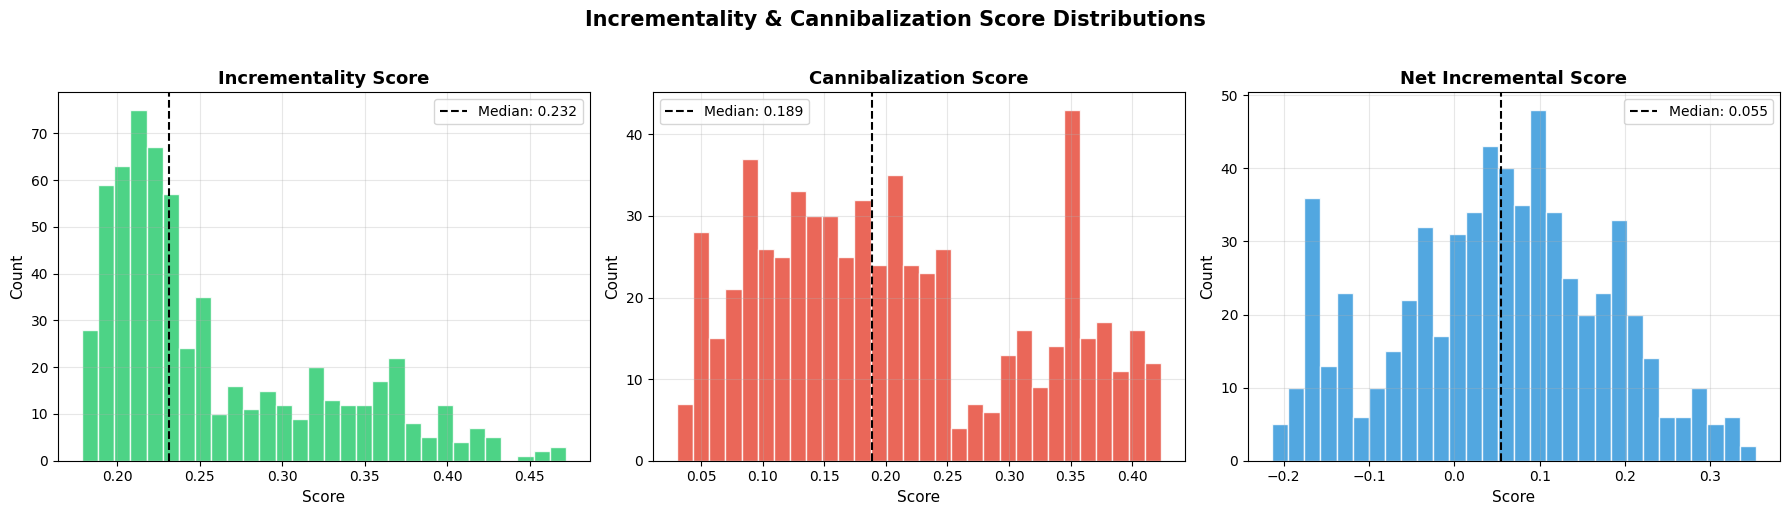

In [89]:
# ── Score distribution visualisation ─────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Incrementality & Cannibalization Score Distributions",
             fontsize=15, fontweight="bold", y=1.02)

for ax, (col, label, color) in zip(axes, [
        ("incrementality_score",   "Incrementality",  "#2ECC71"),
        ("cannibalization_score",  "Cannibalization", "#E74C3C"),
        ("net_incremental_score",  "Net Incremental", "#3498DB"),
]):
    ax.hist(results_df[col], bins=30, color=color, edgecolor="white", alpha=0.85)
    median_val = results_df[col].median()
    ax.axvline(median_val, color="black", linestyle="--", linewidth=1.5,
               label=f"Median: {median_val:.3f}")
    ax.set_title(f"{label} Score", fontsize=13, fontweight="bold")
    ax.set_xlabel("Score", fontsize=11)
    ax.set_ylabel("Count",  fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


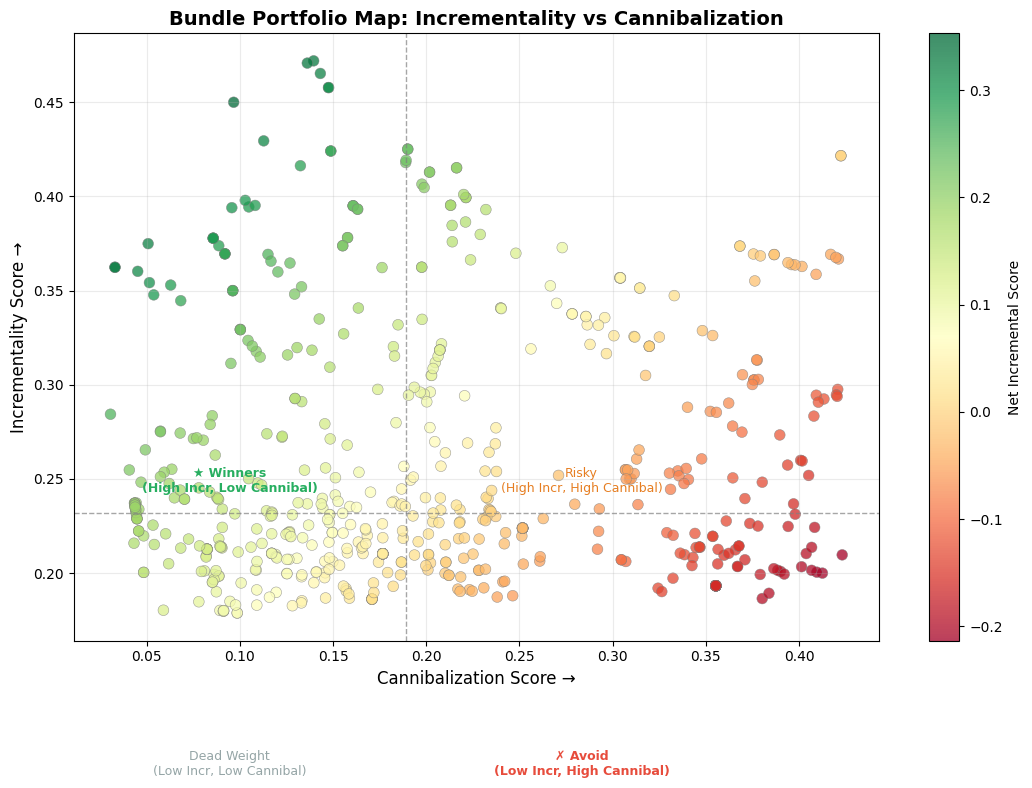

In [90]:
# ── Scatter: Incrementality vs Cannibalization (quadrant view) ───────────

fig, ax = plt.subplots(figsize=(11, 8))

scatter = ax.scatter(
    results_df["cannibalization_score"],
    results_df["incrementality_score"],
    c=results_df["net_incremental_score"],
    cmap="RdYlGn", s=60, alpha=0.75,
    edgecolors="grey", linewidths=0.4,
)
plt.colorbar(scatter, ax=ax, label="Net Incremental Score")

med_c = results_df["cannibalization_score"].median()
med_i = results_df["incrementality_score"].median()
ax.axvline(med_c, color="grey", linestyle="--", linewidth=1, alpha=0.7)
ax.axhline(med_i, color="grey", linestyle="--", linewidth=1, alpha=0.7)

ax.text(med_c * 0.50, med_i * 1.05, "★ Winners\n(High Incr, Low Cannibal)",
        ha="center", fontsize=9, color="#27AE60", fontweight="bold")
ax.text(med_c * 1.50, med_i * 1.05, "Risky\n(High Incr, High Cannibal)",
        ha="center", fontsize=9, color="#E67E22")
ax.text(med_c * 0.50, med_i * 0.40, "Dead Weight\n(Low Incr, Low Cannibal)",
        ha="center", fontsize=9, color="#95A5A6")
ax.text(med_c * 1.50, med_i * 0.40, "✗ Avoid\n(Low Incr, High Cannibal)",
        ha="center", fontsize=9, color="#E74C3C", fontweight="bold")

ax.set_xlabel("Cannibalization Score →",  fontsize=12)
ax.set_ylabel("Incrementality Score →",   fontsize=12)
ax.set_title("Bundle Portfolio Map: Incrementality vs Cannibalization",
             fontsize=14, fontweight="bold")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


In [91]:
# ── Select TOP-5 bundles per bundle_type ─────────────────────────────────

top5_per_type = (
    results_df
    .sort_values("net_incremental_score", ascending=False)
    .groupby("bundle_type", group_keys=False)
    .head(5)
    .copy()
)

# Add rank within each bundle_type
top5_per_type["rank"] = (
    top5_per_type
    .groupby("bundle_type")["net_incremental_score"]
    .rank(method="first", ascending=False)
    .astype(int)
)

top5_per_type = top5_per_type.sort_values(
    ["bundle_type", "rank"]
).reset_index(drop=True)

display_cols = [
    "bundle_type", "rank", "price", "volume_mb", "volume_min",
    "validity_hours", "predicted_popularity",
    "incrementality_score", "cannibalization_score", "net_incremental_score",
]

print("=" * 80)
print("         TOP-5 BUNDLES PER BUNDLE TYPE  ─  Net Incremental Ranking")
print("=" * 80)

for btype, grp in top5_per_type.groupby("bundle_type"):
    print(f"\n{'─'*80}")
    print(f"  Bundle Type: {btype}  ({len(grp)} bundles)")
    print(f"{'─'*80}")
    sub = grp[display_cols].copy()
    sub.columns = [
        "Type", "Rank", "Price", "Data(MB)", "Voice(min)",
        "Validity(h)", "Popularity", "Incr.", "Cannibal.", "Net Score",
    ]
    print(sub.drop(columns=["Type"]).to_string(index=False))

    # Print cannibalization targets for rank-1 bundle in this type
    best = grp[grp["rank"] == 1].iloc[0]
    print(f"\n  ★ Best bundle targets (most at-risk existing bundles):")
    for t in best["top_targets"][:3]:
        print(f"    • {t['bundle_name']:<40}  similarity={t['similarity']:.3f}  price={t['price']}")

print(f"\nTotal bundles selected: {len(top5_per_type)}")
print(f"Bundle types covered:   {top5_per_type['bundle_type'].nunique()}")


         TOP-5 BUNDLES PER BUNDLE TYPE  ─  Net Incremental Ranking

────────────────────────────────────────────────────────────────────────────────
  Bundle Type: BUNDLE_DATA  (5 bundles)
────────────────────────────────────────────────────────────────────────────────
 Rank  Price  Data(MB)  Voice(min)  Validity(h)  Popularity  Incr.  Cannibal.  Net Score
    1  100.0      28.0         0.0         72.0      0.4957 0.2714     0.0751     0.1963
    2 1606.0    2028.9         0.0        168.0      0.4492 0.2372     0.0444     0.1928
    3 1310.0    1582.5         0.0        168.0      0.4683 0.2551     0.0635     0.1916
    4  596.0     750.6         0.0         72.0      0.5859 0.2705     0.0804     0.1901
    5 1341.0    1626.3         0.0        168.0      0.4592 0.2475     0.0621     0.1854

  ★ Best bundle targets (most at-risk existing bundles):
    • Forfait 1 jour  20MB@100F                 similarity=0.891  price=100.0
    • Forfait Maxinet Debutant 100Mb 3 jours@100F  similarit

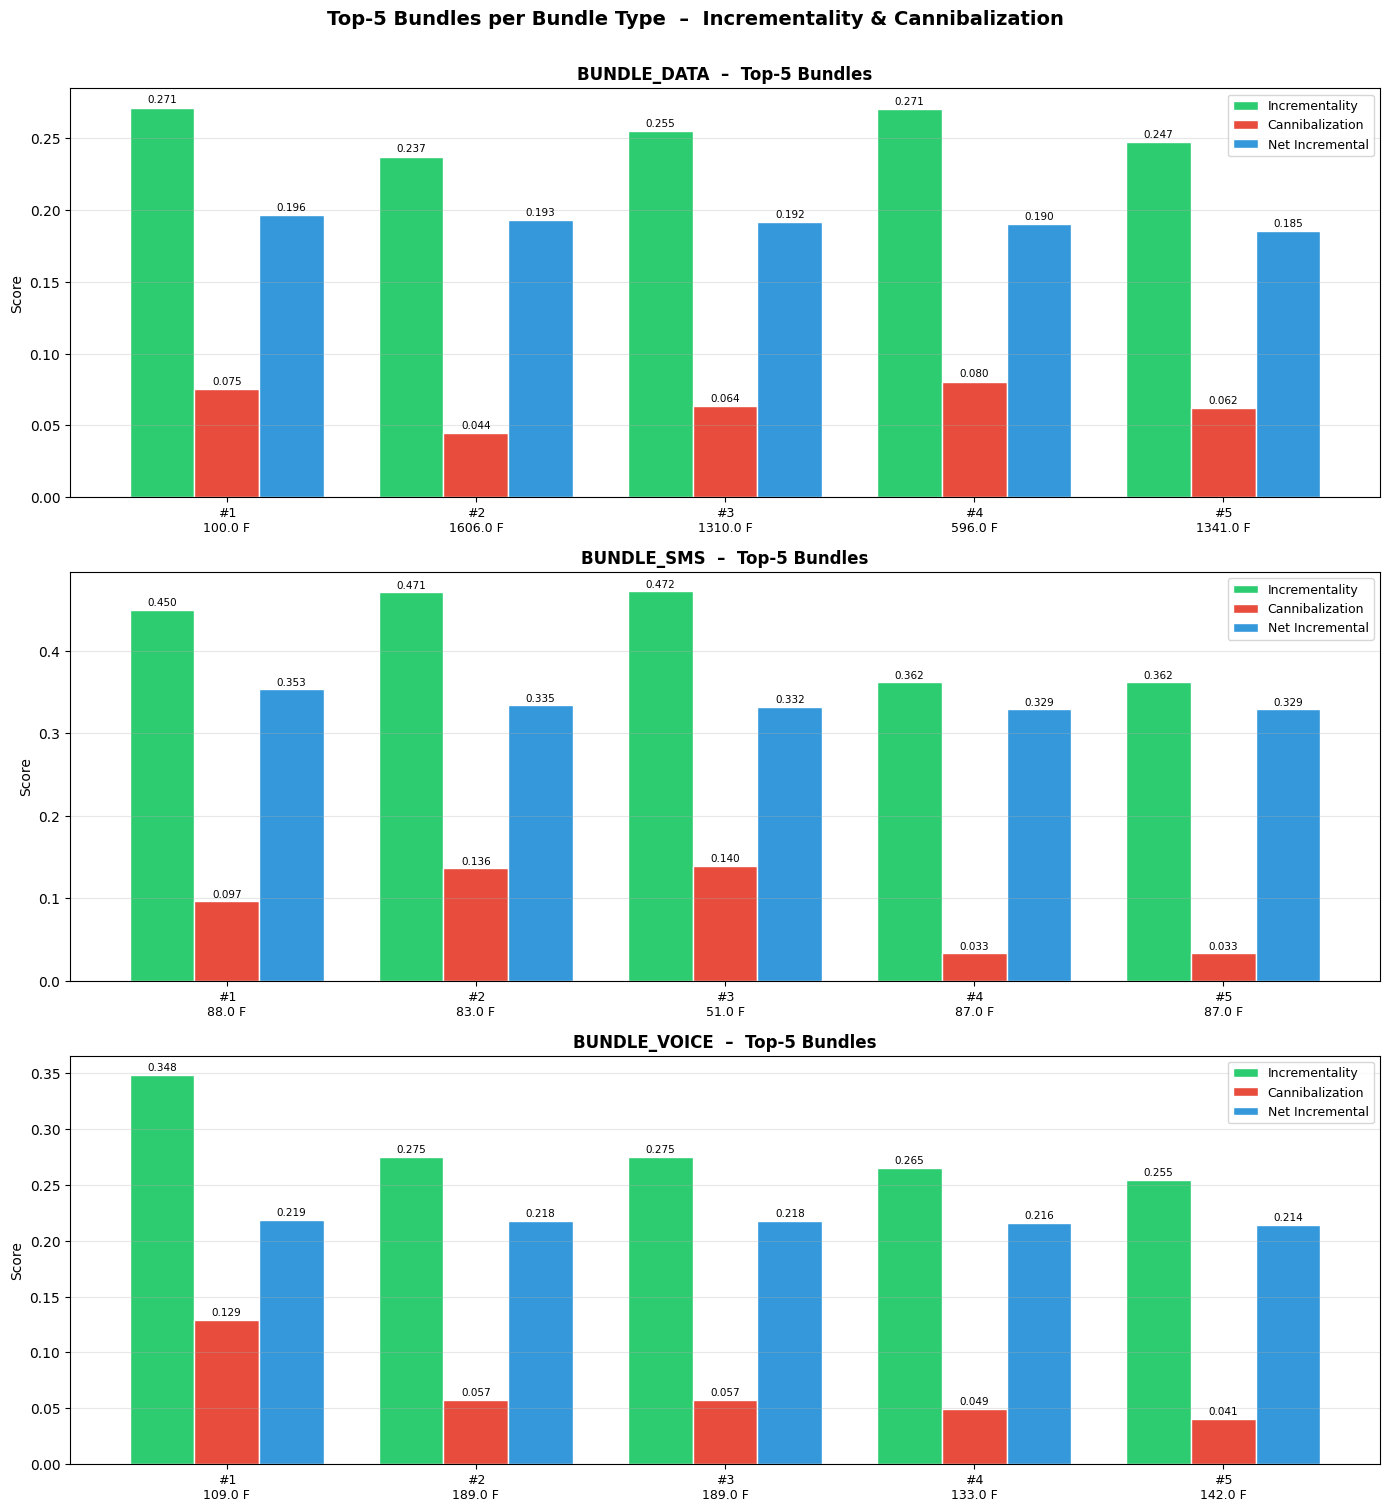

In [92]:
# ── Per-type bar charts ───────────────────────────────────────────────────

bundle_types = top5_per_type["bundle_type"].unique()
n_types      = len(bundle_types)

fig, axes = plt.subplots(
    n_types, 1,
    figsize=(14, 5 * n_types),
    squeeze=False
)

for ax, btype in zip(axes[:, 0], bundle_types):
    grp    = top5_per_type[top5_per_type["bundle_type"] == btype].reset_index(drop=True)
    x      = np.arange(len(grp))
    width  = 0.26
    labels = [f"#{int(r['rank'])}\n{r['price']} F" for _, r in grp.iterrows()]

    bi = ax.bar(x - width, grp["incrementality_score"],   width,
                label="Incrementality",  color="#2ECC71", edgecolor="white")
    bc = ax.bar(x,          grp["cannibalization_score"],  width,
                label="Cannibalization", color="#E74C3C", edgecolor="white")
    bn = ax.bar(x + width,  grp["net_incremental_score"],  width,
                label="Net Incremental", color="#3498DB", edgecolor="white")

    for bar_group in [bi, bc, bn]:
        for bar in bar_group:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.002,
                    f"{h:.3f}", ha="center", va="bottom", fontsize=7.5)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_title(f"{btype}  –  Top-{len(grp)} Bundles",
                 fontsize=12, fontweight="bold")
    ax.set_ylabel("Score", fontsize=10)
    ax.legend(fontsize=9, loc="upper right")
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Top-5 Bundles per Bundle Type  –  Incrementality & Cannibalization",
             fontsize=14, fontweight="bold", y=1.005)
plt.tight_layout()
plt.show()


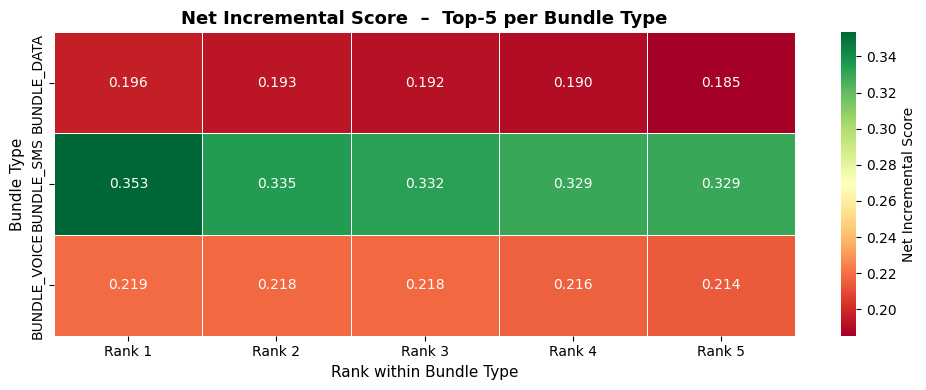

In [93]:
# ── Heatmap: Net Incremental Score across types & ranks ──────────────────

pivot = top5_per_type.pivot_table(
    index="bundle_type",
    columns="rank",
    values="net_incremental_score",
    aggfunc="first"
)
pivot.columns = [f"Rank {int(c)}" for c in pivot.columns]

fig, ax = plt.subplots(figsize=(10, max(4, len(pivot) * 0.7 + 1)))
sns.heatmap(
    pivot,
    annot=True, fmt=".3f",
    cmap="RdYlGn",
    linewidths=0.5,
    linecolor="white",
    ax=ax,
    cbar_kws={"label": "Net Incremental Score"},
)
ax.set_title("Net Incremental Score  –  Top-5 per Bundle Type",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Rank within Bundle Type", fontsize=11)
ax.set_ylabel("Bundle Type", fontsize=11)
plt.tight_layout()
plt.show()


In [94]:
# ── Export top-5-per-type for LLM naming step ────────────────────────────

top5_bundles_final = top5_per_type[
    ["bundle_type", "rank", "price", "volume_mb", "volume_min", "volume_sms",
     "validity_hours", "predicted_popularity",
     "incrementality_score", "cannibalization_score", "net_incremental_score"]
].copy()

print("top5_bundles_final is ready for the LLM naming step.")
print(f"Shape: {top5_bundles_final.shape}")
top5_bundles_final.head(15)


top5_bundles_final is ready for the LLM naming step.
Shape: (15, 11)


,bundle_type,rank,price,volume_mb,volume_min,volume_sms,validity_hours,predicted_popularity,incrementality_score,cannibalization_score,net_incremental_score
0,BUNDLE_DATA,1,100.0,28.0,0.0,0.0,72.0,0.4957,0.2714,0.0751,0.1963
1,BUNDLE_DATA,2,1606.0,2028.9,0.0,0.0,168.0,0.4492,0.2372,0.0444,0.1928
2,BUNDLE_DATA,3,1310.0,1582.5,0.0,0.0,168.0,0.4683,0.2551,0.0635,0.1916
3,BUNDLE_DATA,4,596.0,750.6,0.0,0.0,72.0,0.5859,0.2705,0.0804,0.1901
4,BUNDLE_DATA,5,1341.0,1626.3,0.0,0.0,168.0,0.4592,0.2475,0.0621,0.1854
5,BUNDLE_SMS,1,88.0,0.0,0.0,63.0,72.0,0.7038,0.4500,0.0967,0.3533
6,BUNDLE_SMS,2,83.0,0.0,0.0,57.0,72.0,0.7038,0.4708,0.1362,0.3346
7,BUNDLE_SMS,3,51.0,0.0,0.0,27.0,72.0,0.7154,0.4720,0.1396,0.3324
8,BUNDLE_SMS,4,87.0,0.0,0.0,93.0,24.0,0.5913,0.3624,0.0330,0.3294
9,BUNDLE_SMS,5,87.0,0.0,0.0,92.0,24.0,0.5913,0.3623,0.0330,0.3293


In [179]:
# ============================================================
# MVP upgrade for Incrementality + Cannibalization
# ============================================================

import numpy as np
import pandas as pd

EPS = 1e-9
TOP_K_TARGETS = 5

FAMILY_MAP = {
    "BUNDLE_DATA": "DATA",
    "BUNDLE_VOICE": "VOICE",
    "INT_BUNDLE_VOICE": "VOICE",
    "OFFNET_BUNDLE_VOICE": "VOICE",
    "BUNDLE_SMS": "SMS",
    "FLEXI_BUNDLE": "COMBO",
}


def _safe_str(x):
    return str(x).strip().lower() if pd.notna(x) else "unknown"


def validity_bucket_from_hours(hours):
    h = float(hours) if pd.notna(hours) else 0.0
    d = h / 24.0
    if d <= 1:
        return "daily"
    if d <= 7:
        return "weekly"
    if d <= 30:
        return "monthly"
    return "long_term"


def infer_offer_family(bundle_type, volume_mb=0, volume_min=0, volume_sms=0):
    btype = str(bundle_type).strip() if pd.notna(bundle_type) else ""
    if btype in FAMILY_MAP:
        return FAMILY_MAP[btype]

    mb = float(volume_mb or 0)
    mins = float(volume_min or 0)
    sms = float(volume_sms or 0)

    active = int(mb > 0) + int(mins > 0) + int(sms > 0)
    if active >= 2:
        return "COMBO"
    if mb > 0:
        return "DATA"
    if mins > 0:
        return "VOICE"
    if sms > 0:
        return "SMS"
    return "UNKNOWN"


def compute_bundle_utility(row):
    family = row.get("offer_family")
    mb = float(row.get("volume_mb", 0) or 0)
    mins = float(row.get("volume_min", 0) or 0)
    sms = float(row.get("volume_sms", 0) or 0)
    vh = float(row.get("validity_hours", 0) or 0)

    if family == "DATA":
        return np.log1p(mb) + 0.20 * np.log1p(vh)
    if family == "VOICE":
        return np.log1p(mins) + 0.20 * np.log1p(vh)
    if family == "SMS":
        return np.log1p(sms) + 0.12 * np.log1p(vh)

    return (
        0.55 * np.log1p(mb) +
        0.30 * np.log1p(mins) +
        0.15 * np.log1p(sms) +
        0.20 * np.log1p(vh)
    )


def compute_value_index(row):
    price = max(float(row.get("price", 0) or 0), 0.0)
    utility = float(row.get("utility_score", 0) or 0)
    return utility / max(np.log1p(price), 1.0)


def enrich_bundle_frame(df):
    out = df.copy()

    for col in ["bundle_type", "usage_type", "service_class_category"]:
        if col not in out.columns:
            out[col] = "unknown"
        out[col] = out[col].fillna("unknown")

    for col in ["price", "volume_mb", "volume_min", "volume_sms", "validity_hours"]:
        if col not in out.columns:
            out[col] = 0.0
        out[col] = pd.to_numeric(out[col], errors="coerce").fillna(0.0)

    out["offer_family"] = out.apply(
        lambda r: infer_offer_family(
            r["bundle_type"], r["volume_mb"], r["volume_min"], r["volume_sms"]
        ),
        axis=1
    )
    out["validity_bucket"] = out["validity_hours"].apply(validity_bucket_from_hours)
    out["utility_score"] = out.apply(compute_bundle_utility, axis=1)
    out["value_index"] = out.apply(compute_value_index, axis=1)

    out["segment_key"] = (
        out["offer_family"].astype(str) + "|" +
        out["usage_type"].astype(str) + "|" +
        out["service_class_category"].astype(str) + "|" +
        out["validity_bucket"].astype(str)
    )

    return out


def build_reference_catalogue_v2(historical_df: pd.DataFrame) -> pd.DataFrame:
    hist = historical_df.copy()

    # make function robust to either corrected or raw volume columns
    mb_col = "volume_mb" if "volume_mb" in hist.columns else "configured_volume_mb"
    min_col = "volume_min" if "volume_min" in hist.columns else "configured_volume_min"
    sms_col = "volume_sms" if "volume_sms" in hist.columns else "configured_volume_sms"

    for col in [
        "bundle_name", "bundle_type", "usage_type", "service_class_category",
        "price", "validity_hours", "popularity", "total_rev", "unique_users", "week_number",
        mb_col, min_col, sms_col
    ]:
        if col not in hist.columns:
            hist[col] = 0 if col not in ["bundle_name", "bundle_type", "usage_type", "service_class_category"] else "unknown"

    ref = (
        hist.groupby("bundle_name", as_index=False)
        .agg(
            bundle_type=("bundle_type", "first"),
            usage_type=("usage_type", "first"),
            service_class_category=("service_class_category", "first"),
            price=("price", "first"),
            volume_mb=(mb_col, "first"),
            volume_min=(min_col, "first"),
            volume_sms=(sms_col, "first"),
            validity_hours=("validity_hours", "first"),
            max_popularity=("popularity", "max"),
            total_rev=("total_rev", "sum"),
            total_users=("unique_users", "sum"),
            weeks_active=("week_number", "nunique"),
        )
    )

    ref = enrich_bundle_frame(ref)

    ref["max_popularity"] = pd.to_numeric(ref["max_popularity"], errors="coerce").fillna(0.0)
    ref["total_rev"] = pd.to_numeric(ref["total_rev"], errors="coerce").fillna(0.0).clip(lower=0.0)
    ref["total_users"] = pd.to_numeric(ref["total_users"], errors="coerce").fillna(0.0).clip(lower=0.0)

    total_rev = max(ref["total_rev"].sum(), EPS)
    total_users = max(ref["total_users"].sum(), EPS)

    ref["rev_share_global"] = ref["total_rev"] / total_rev
    ref["user_share_global"] = ref["total_users"] / total_users
    ref["market_importance"] = 0.55 * ref["rev_share_global"] + 0.45 * ref["user_share_global"]

    fam_rev = ref.groupby("offer_family")["total_rev"].transform("sum").clip(lower=EPS)
    fam_users = ref.groupby("offer_family")["total_users"].transform("sum").clip(lower=EPS)
    ref["rev_share_family"] = ref["total_rev"] / fam_rev
    ref["user_share_family"] = ref["total_users"] / fam_users
    ref["family_importance"] = 0.55 * ref["rev_share_family"] + 0.45 * ref["user_share_family"]

    seg_rev = ref.groupby("segment_key")["total_rev"].transform("sum").clip(lower=EPS)
    seg_users = ref.groupby("segment_key")["total_users"].transform("sum").clip(lower=EPS)
    ref["rev_share_segment"] = ref["total_rev"] / seg_rev
    ref["user_share_segment"] = ref["total_users"] / seg_users

    return ref


def _exp_similarity_from_logs(a, b, scale):
    a = max(float(a or 0), 0.0)
    b = max(float(b or 0), 0.0)
    if a == 0 and b == 0:
        return 1.0
    return float(np.exp(-abs(np.log1p(a) - np.log1p(b)) / scale))


def _exp_similarity(a, b, scale):
    return float(np.exp(-abs(float(a) - float(b)) / scale))


def _categorical_match(a, b):
    a = _safe_str(a)
    b = _safe_str(b)
    if a == "unknown" or b == "unknown":
        return 0.5
    return float(a == b)


def _family_overlap(f1, f2):
    if f1 == f2:
        return 1.0
    if "COMBO" in {f1, f2}:
        other = f2 if f1 == "COMBO" else f1
        return 0.35 if other in {"DATA", "VOICE", "SMS"} else 0.15
    return 0.0


def compute_similarity_v2(new_bundle, ref_row):
    f_new = new_bundle.get(
        "offer_family",
        infer_offer_family(
            new_bundle.get("bundle_type", ""),
            new_bundle.get("volume_mb", 0),
            new_bundle.get("volume_min", 0),
            new_bundle.get("volume_sms", 0),
        ),
    )
    f_ref = ref_row.get(
        "offer_family",
        infer_offer_family(
            ref_row.get("bundle_type", ""),
            ref_row.get("volume_mb", 0),
            ref_row.get("volume_min", 0),
            ref_row.get("volume_sms", 0),
        ),
    )

    fam = _family_overlap(f_new, f_ref)
    if fam == 0.0:
        return 0.0

    exact_type = float(_safe_str(new_bundle.get("bundle_type")) == _safe_str(ref_row.get("bundle_type")))
    type_sim = 1.0 if exact_type == 1.0 else 0.55 * fam

    price_sim = _exp_similarity_from_logs(new_bundle.get("price", 0), ref_row.get("price", 0), scale=0.35)
    valid_sim = _exp_similarity_from_logs(new_bundle.get("validity_hours", 0), ref_row.get("validity_hours", 0), scale=0.45)
    util_sim = _exp_similarity(new_bundle.get("utility_score", 0), ref_row.get("utility_score", 0), scale=0.85)
    value_sim = _exp_similarity(new_bundle.get("value_index", 0), ref_row.get("value_index", 0), scale=0.20)
    usage_sim = _categorical_match(new_bundle.get("usage_type", "unknown"), ref_row.get("usage_type", "unknown"))
    svc_sim = _categorical_match(new_bundle.get("service_class_category", "unknown"), ref_row.get("service_class_category", "unknown"))

    score = (
        0.18 * fam +
        0.12 * type_sim +
        0.24 * price_sim +
        0.18 * util_sim +
        0.10 * value_sim +
        0.10 * valid_sim +
        0.04 * usage_sim +
        0.04 * svc_sim
    )

    return round(float(np.clip(score, 0.0, 1.0)), 4)


def compute_feasibility_confidence(new_bundle, ref_cat):
    f_new = new_bundle["offer_family"]
    eligible = ref_cat[ref_cat["offer_family"] == f_new].copy()

    if len(eligible) < 20:
        eligible = ref_cat.copy()

    relevant_cols = ["price", "validity_hours"]
    if f_new in {"DATA", "COMBO"}:
        relevant_cols.append("volume_mb")
    if f_new in {"VOICE", "COMBO"}:
        relevant_cols.append("volume_min")
    if f_new in {"SMS", "COMBO"}:
        relevant_cols.append("volume_sms")

    penalties = []
    for col in relevant_cols:
        x = float(new_bundle.get(col, 0) or 0)
        q_low = float(eligible[col].quantile(0.01))
        q_high = float(eligible[col].quantile(0.99))
        span = max(q_high - q_low, EPS)

        if x < q_low:
            penalties.append(min(1.0, (q_low - x) / span))
        elif x > q_high:
            penalties.append(min(1.0, (x - q_high) / span))
        else:
            penalties.append(0.0)

    penalty = float(np.mean(penalties)) if penalties else 0.0
    return round(float(np.clip(1.0 - 0.65 * penalty, 0.35, 1.0)), 4)


def compute_demand_potential(new_bundle, eligible_refs):
    rows = []

    new_usage = _safe_str(new_bundle.get("usage_type", "unknown"))
    new_sc = _safe_str(new_bundle.get("service_class_category", "unknown"))

    for _, ref in eligible_refs.iterrows():
        wide_price = _exp_similarity_from_logs(new_bundle.get("price", 0), ref.get("price", 0), scale=0.70)
        wide_valid = _exp_similarity_from_logs(new_bundle.get("validity_hours", 0), ref.get("validity_hours", 0), scale=0.90)

        seg_factor = 1.0
        if new_usage != "unknown" and _safe_str(ref.get("usage_type")) != new_usage:
            seg_factor *= 0.80
        if new_sc != "unknown" and _safe_str(ref.get("service_class_category")) != new_sc:
            seg_factor *= 0.85

        rows.append((0.65 * wide_price + 0.35 * wide_valid) * ref["family_importance"] * seg_factor)

    return round(float(np.clip(np.sum(rows), 0.0, 1.0)), 4)


def compute_cannibalization_score_v2(new_bundle, ref_cat, top_k=TOP_K_TARGETS):
    f_new = new_bundle["offer_family"]
    eligible = ref_cat[ref_cat["offer_family"].apply(lambda f: _family_overlap(f_new, f) > 0)].copy()

    if eligible.empty:
        return {"cannibal_score": 0.0, "top_targets": [], "cannibal_mass": 0.0}

    sims = eligible.apply(lambda row: compute_similarity_v2(new_bundle, row), axis=1)
    eligible = eligible.assign(similarity=sims)
    eligible = eligible[eligible["similarity"] > 0.20].copy()

    if eligible.empty:
        return {"cannibal_score": 0.0, "top_targets": [], "cannibal_mass": 0.0}

    new_value = float(new_bundle.get("value_index", 0) or 0)

    eligible["value_pressure"] = eligible["value_index"].apply(
        lambda ref_v: float(np.clip(new_value / max(float(ref_v), EPS), 0.80, 1.25))
    )

    eligible["contribution"] = (
        eligible["market_importance"] *
        (eligible["similarity"] ** 2.1) *
        eligible["value_pressure"]
    )

    eligible = eligible.sort_values("contribution", ascending=False).reset_index(drop=True)

    risk_mass = float(eligible["contribution"].sum())
    cannibal_score = float(np.clip(1.0 - np.exp(-1.6 * risk_mass), 0.0, 1.0))

    top_targets = []
    for _, row in eligible.head(top_k).iterrows():
        top_targets.append({
            "bundle_name": row["bundle_name"],
            "similarity": round(float(row["similarity"]), 4),
            "bundle_type": row["bundle_type"],
            "price": round(float(row["price"]), 2),
            "contribution": round(float(row["contribution"]), 4),
        })

    return {
        "cannibal_score": round(cannibal_score, 4),
        "top_targets": top_targets,
        "cannibal_mass": round(risk_mass, 4),
    }


def compute_incrementality_score_v2(new_bundle, ref_cat):
    predicted_pop = float(np.clip(new_bundle.get("predicted_popularity", 0), 0.0, 1.0))
    f_new = new_bundle["offer_family"]
    eligible = ref_cat[ref_cat["offer_family"].apply(lambda f: _family_overlap(f_new, f) > 0)].copy()

    if eligible.empty:
        base = predicted_pop * 0.60
        diag = {
            "novelty_score": 0.6,
            "demand_potential": 0.5,
            "whitespace_score": 0.5,
            "crowding_score": 0.0,
            "confidence_score": 1.0,
        }
        return round(float(base), 4), diag

    sims = eligible.apply(lambda row: compute_similarity_v2(new_bundle, row), axis=1).values

    top_sims = np.sort(sims)[::-1][:3]
    if len(top_sims):
        weights = np.array([0.60, 0.30, 0.10][:len(top_sims)], dtype=float)
        weights = weights / weights.sum()
        novelty = 1.0 - float(np.dot(top_sims, weights))
    else:
        novelty = 1.0

    demand_potential = compute_demand_potential(new_bundle, eligible)
    crowding = float(np.clip(np.sum((sims ** 1.7) * eligible["family_importance"].values), 0.0, 1.0))
    whitespace = float(np.clip(demand_potential * (1.0 - crowding), 0.0, 1.0))
    confidence = compute_feasibility_confidence(new_bundle, eligible)

    score = predicted_pop * (
        0.45 * novelty +
        0.35 * whitespace +
        0.20 * confidence
    )

    diag = {
        "novelty_score": round(novelty, 4),
        "demand_potential": round(demand_potential, 4),
        "whitespace_score": round(whitespace, 4),
        "crowding_score": round(crowding, 4),
        "confidence_score": round(confidence, 4),
    }

    return round(float(np.clip(score, 0.0, 1.0)), 4), diag


reference_catalogue = build_reference_catalogue_v2(data)
generated_scoring_base = enrich_bundle_frame(top_generated_bundles)

results = []

for idx, new_b in generated_scoring_base.iterrows():
    new_bundle = new_b.copy()

    cannibal_result = compute_cannibalization_score_v2(new_bundle, reference_catalogue)
    incr_score, incr_diag = compute_incrementality_score_v2(new_bundle, reference_catalogue)
    cannibal_score = cannibal_result["cannibal_score"]

    # Better than raw subtraction for MVP:
    # retained incremental demand after cannibalization
    net_score = round(incr_score * (1.0 - cannibal_score), 4)

    results.append({
        "idx": idx,
        "bundle_type": new_bundle.get("bundle_type", ""),
        "usage_type": new_bundle.get("usage_type", "unknown"),
        "service_class_category": new_bundle.get("service_class_category", "unknown"),
        "offer_family": new_bundle.get("offer_family", "unknown"),
        "price": round(float(new_bundle.get("price", 0)), 2),
        "volume_mb": round(float(new_bundle.get("volume_mb", 0)), 1),
        "volume_min": round(float(new_bundle.get("volume_min", 0)), 1),
        "volume_sms": round(float(new_bundle.get("volume_sms", 0)), 1),
        "validity_hours": round(float(new_bundle.get("validity_hours", 0)), 1),
        "utility_score": round(float(new_bundle.get("utility_score", 0)), 4),
        "value_index": round(float(new_bundle.get("value_index", 0)), 4),
        "predicted_popularity": round(float(new_bundle.get("predicted_popularity", 0)), 4),
        "novelty_score": incr_diag["novelty_score"],
        "demand_potential": incr_diag["demand_potential"],
        "whitespace_score": incr_diag["whitespace_score"],
        "crowding_score": incr_diag["crowding_score"],
        "confidence_score": incr_diag["confidence_score"],
        "incrementality_score": incr_score,
        "cannibalization_score": cannibal_score,
        "net_incremental_score": net_score,
        "top_targets": cannibal_result["top_targets"],
    })

results_df = pd.DataFrame(results)

# Optional hard gates for safer MVP output:
# results_df = results_df[results_df["confidence_score"] >= 0.55].copy()
# results_df = results_df[results_df["whitespace_score"] >= 0.05].copy()

print(f"Scored {len(results_df)} generated bundles with MVP-upgraded incrementality/cannibalization ✓")
results_df.drop(columns=["top_targets"]).sort_values(
    "net_incremental_score", ascending=False
).head(10)


Scored 624 generated bundles with MVP-upgraded incrementality/cannibalization ✓


,idx,bundle_type,usage_type,service_class_category,offer_family,price,volume_mb,volume_min,volume_sms,validity_hours,...,value_index,predicted_popularity,novelty_score,demand_potential,whitespace_score,crowding_score,confidence_score,incrementality_score,cannibalization_score,net_incremental_score
437,985,BUNDLE_SMS,CHARGED,PREPAID,SMS,52.0,0.0,0.0,28.0,72.0,...,0.9778,0.7154,0.2802,0.7818,0.3319,0.5755,1.0,0.3164,0.0497,0.3007
297,644,BUNDLE_SMS,CHARGED,PREPAID,SMS,51.0,0.0,0.0,27.0,72.0,...,0.9736,0.7154,0.2764,0.7791,0.3319,0.5740,1.0,0.3152,0.0494,0.2996
391,853,BUNDLE_SMS,CHARGED,PREPAID,SMS,38.0,0.0,0.0,18.0,72.0,...,0.9442,0.7154,0.2566,0.7465,0.3262,0.5630,1.0,0.3074,0.0471,0.2929
438,986,BUNDLE_SMS,CHARGED,PREPAID,SMS,59.0,0.0,0.0,33.0,72.0,...,0.9870,0.7154,0.2612,0.8048,0.3252,0.5959,1.0,0.3086,0.0522,0.2925
366,803,BUNDLE_SMS,CHARGED,PREPAID,SMS,63.0,0.0,0.0,37.0,72.0,...,0.9985,0.7162,0.2349,0.8211,0.3133,0.6184,1.0,0.2975,0.0554,0.2810
322,697,BUNDLE_SMS,CHARGED,PREPAID,SMS,83.0,0.0,0.0,57.0,72.0,...,1.0326,0.7038,0.2340,0.7779,0.3177,0.5916,1.0,0.2931,0.0526,0.2777
335,735,BUNDLE_SMS,CHARGED,PREPAID,SMS,88.0,0.0,0.0,63.0,72.0,...,1.0412,0.7038,0.2307,0.7690,0.3205,0.5832,1.0,0.2928,0.0516,0.2777
303,652,BUNDLE_SMS,CHARGED,PREPAID,SMS,81.0,0.0,0.0,55.0,72.0,...,1.0303,0.7038,0.2305,0.7822,0.3155,0.5966,1.0,0.2915,0.0532,0.2760
435,977,BUNDLE_SMS,CHARGED,PREPAID,SMS,81.0,0.0,0.0,55.0,72.0,...,1.0303,0.7038,0.2305,0.7822,0.3155,0.5966,1.0,0.2915,0.0532,0.2760
431,967,BUNDLE_SMS,CHARGED,PREPAID,SMS,57.0,0.0,0.0,38.0,48.0,...,1.0173,0.7152,0.2189,0.7359,0.2995,0.5931,1.0,0.2885,0.0568,0.2721


In [181]:
results_df['volume_min'] = np.ceil(results_df['volume_min'])
results_df = results_df[~((results_df['bundle_type'] == 'BUNDLE_VOICE') & (results_df['volume_min'] <= 5.0))]

results_df['volume_mb'] = np.ceil(results_df['volume_mb'])
results_df = results_df[~((results_df['bundle_type'] == 'BUNDLE_DATA') & (results_df['volume_mb'] <= 50.0))]

results_df['volume_sms'] = np.ceil(results_df['volume_sms'])
results_df = results_df[~((results_df['bundle_type'] == 'BUNDLE_SMS') & (results_df['volume_sms'] <= 5.0))]

results_df.shape

(601, 22)

In [ ]:
#test = results_df[results_df["confidence_score"] >= 0.80].copy()
# results_df = results_df[results_df["whitespace_score"] >= 0.05].copy()

In [182]:
# ============================================================
# Replace current cell 66 with this block
# ============================================================

def select_diverse_top_bundles(scored_df, top_n=5, similarity_threshold=0.95):
    selected = []
    ordered = scored_df.sort_values("net_incremental_score", ascending=False)

    for btype, grp in ordered.groupby("bundle_type", sort=False):
        kept = []
        for _, row in grp.iterrows():
            too_close = any(
                compute_similarity_v2(row, prev) >= similarity_threshold
                for prev in kept
            )
            if too_close:
                continue

            kept.append(row)
            if len(kept) == top_n:
                break

        selected.extend(kept)

    out = pd.DataFrame(selected).copy()
    if out.empty:
        return out

    out["rank"] = (
        out.groupby("bundle_type")["net_incremental_score"]
        .rank(method="first", ascending=False)
        .astype(int)
    )

    return out.sort_values(["bundle_type", "rank"]).reset_index(drop=True)


top5_per_type = select_diverse_top_bundles(
    results_df,
    top_n=5,
    similarity_threshold=0.88
)

display_cols = [
    "bundle_type", "rank", "price", "volume_mb", "volume_min",
    "validity_hours", "predicted_popularity",
    "incrementality_score", "cannibalization_score", "net_incremental_score",
]

print("=" * 80)
print("         TOP-5 BUNDLES PER BUNDLE TYPE  ─  Net Incremental Ranking")
print("=" * 80)

for btype, grp in top5_per_type.groupby("bundle_type"):
    print(f"\n{'─'*80}")
    print(f"  Bundle Type: {btype}  ({len(grp)} bundles)")
    print(f"{'─'*80}")

    sub = grp[display_cols].copy()
    sub.columns = [
        "Type", "Rank", "Price", "Data(MB)", "Voice(min)",
        "Validity(h)", "Popularity", "Incr.", "Cannibal.", "Net Score",
    ]
    print(sub.drop(columns=["Type"]).to_string(index=False))

    best = grp[grp["rank"] == 1].iloc[0]
    print(f"\n  ★ Best bundle targets (most at-risk existing bundles):")
    for t in best["top_targets"][:3]:
        print(
            f"    • {t['bundle_name']:<40}  "
            f"similarity={t['similarity']:.3f}  "
            f"contribution={t.get('contribution', 0):.4f}  "
            f"price={t['price']}"
        )

print(f"\nTotal bundles selected: {len(top5_per_type)}")
print(f"Bundle types covered:   {top5_per_type['bundle_type'].nunique()}")

         TOP-5 BUNDLES PER BUNDLE TYPE  ─  Net Incremental Ranking

────────────────────────────────────────────────────────────────────────────────
  Bundle Type: BUNDLE_DATA  (5 bundles)
────────────────────────────────────────────────────────────────────────────────
 Rank  Price  Data(MB)  Voice(min)  Validity(h)  Popularity  Incr.  Cannibal.  Net Score
    1 1684.0    3155.0         0.0         72.0      0.5536 0.2280     0.1645     0.1905
    2  253.0     208.0         0.0         24.0      0.6591 0.2244     0.1746     0.1852
    3  123.0      69.0         0.0         24.0      0.5766 0.2089     0.1230     0.1832
    4 2393.0    3361.0         0.0        168.0      0.5343 0.1978     0.1340     0.1713
    5  388.0     272.0         0.0         72.0      0.5774 0.2055     0.1736     0.1698

  ★ Best bundle targets (most at-risk existing bundles):
    • Forfait weekend 3.17GB 3jours@840F        similarity=0.740  contribution=0.0224  price=840.0
    • Forfait widge 1005.47MB 3 jours@6

In [184]:
top5_per_type.head(15)

,idx,bundle_type,usage_type,service_class_category,offer_family,price,volume_mb,volume_min,volume_sms,validity_hours,...,novelty_score,demand_potential,whitespace_score,crowding_score,confidence_score,incrementality_score,cannibalization_score,net_incremental_score,top_targets,rank
0,24,BUNDLE_DATA,CHARGED,PREPAID,DATA,1684.0,3155.0,0.0,0.0,72.0,...,0.1442,0.7735,0.4200,0.4570,1.0,0.2280,0.1645,0.1905,[{'bundle_name': 'Forfait weekend 3.17GB 3jour...,1
1,44,BUNDLE_DATA,CHARGED,PREPAID,DATA,253.0,208.0,0.0,0.0,24.0,...,0.0775,0.5582,0.3018,0.4593,1.0,0.2244,0.1746,0.1852,[{'bundle_name': 'NDEKO Net 220MB 1 jour@281F'...,2
2,226,BUNDLE_DATA,CHARGED,PREPAID,DATA,123.0,69.0,0.0,0.0,24.0,...,0.1556,0.4181,0.2637,0.3693,1.0,0.2089,0.1230,0.1832,[{'bundle_name': 'Forfait maximise 1.5GB 1 jou...,3
3,32,BUNDLE_DATA,CHARGED,PREPAID,DATA,2393.0,3361.0,0.0,0.0,168.0,...,0.0607,0.6883,0.4084,0.4066,1.0,0.1978,0.1340,0.1713,[{'bundle_name': 'Forfait weekend 3.17GB 3jour...,4
4,239,BUNDLE_DATA,CHARGED,PREPAID,DATA,388.0,272.0,0.0,0.0,72.0,...,0.0413,0.7649,0.3925,0.4869,1.0,0.2055,0.1736,0.1698,[{'bundle_name': 'Forfait widge 351MB 3 jours@...,5
5,985,BUNDLE_SMS,CHARGED,PREPAID,SMS,52.0,0.0,0.0,28.0,72.0,...,0.2802,0.7818,0.3319,0.5755,1.0,0.3164,0.0497,0.3007,[{'bundle_name': '50 SMS vers MTN ou 16 vers a...,1
6,853,BUNDLE_SMS,CHARGED,PREPAID,SMS,38.0,0.0,0.0,18.0,72.0,...,0.2566,0.7465,0.3262,0.5630,1.0,0.3074,0.0471,0.2929,[{'bundle_name': '25 SMS vers MTN ou 10 vers a...,2
7,803,BUNDLE_SMS,CHARGED,PREPAID,SMS,63.0,0.0,0.0,37.0,72.0,...,0.2349,0.8211,0.3133,0.6184,1.0,0.2975,0.0554,0.2810,[{'bundle_name': '50 SMS vers MTN ou 16 vers a...,3
8,697,BUNDLE_SMS,CHARGED,PREPAID,SMS,83.0,0.0,0.0,57.0,72.0,...,0.2340,0.7779,0.3177,0.5916,1.0,0.2931,0.0526,0.2777,[{'bundle_name': '50 SMS vers MTN ou 16 vers a...,4
9,967,BUNDLE_SMS,CHARGED,PREPAID,SMS,57.0,0.0,0.0,38.0,48.0,...,0.2189,0.7359,0.2995,0.5931,1.0,0.2885,0.0568,0.2721,[{'bundle_name': '50 SMS vers MTN ou 16 vers a...,5


### Casual AI Method

In [41]:
import numpy as np
import pandas as pd

# Demo only:
# - synthetic customer preferences
# - monthly_price is used as revenue
# In production:
# - fit coefficients from historical choice/offer data
# - replace monthly_price with 90d/12m revenue or margin if available

def generate_catalog():
    existing = pd.DataFrame([
        {"bundle_id": "BASIC_10",    "monthly_price": 15.0, "data_gb": 10,  "voice_mins": 300,  "intl_mins": 0,   "roaming_gb": 0.0, "ott_included": 0, "speed_score": 1.0, "contract_months": 1,  "family_lines": 1},
        {"bundle_id": "VALUE_35",    "monthly_price": 25.0, "data_gb": 35,  "voice_mins": 800,  "intl_mins": 30,  "roaming_gb": 0.5, "ott_included": 0, "speed_score": 2.0, "contract_months": 1,  "family_lines": 1},
        {"bundle_id": "STREAM_100",  "monthly_price": 35.0, "data_gb": 100, "voice_mins": 1500, "intl_mins": 100, "roaming_gb": 1.5, "ott_included": 1, "speed_score": 3.0, "contract_months": 12, "family_lines": 1},
        {"bundle_id": "PREMIUM_300", "monthly_price": 55.0, "data_gb": 300, "voice_mins": 5000, "intl_mins": 300, "roaming_gb": 5.0, "ott_included": 1, "speed_score": 4.0, "contract_months": 12, "family_lines": 1},
    ])

    candidates = pd.DataFrame([
        {"bundle_id": "SOCIAL_PLUS", "monthly_price": 20.0, "data_gb": 25,  "voice_mins": 500,  "intl_mins": 20,  "roaming_gb": 0.0, "ott_included": 1, "speed_score": 2.0, "contract_months": 1,  "family_lines": 1},
        {"bundle_id": "ROAM_MAX",    "monthly_price": 42.0, "data_gb": 80,  "voice_mins": 1200, "intl_mins": 250, "roaming_gb": 4.0, "ott_included": 0, "speed_score": 3.0, "contract_months": 12, "family_lines": 1},
        {"bundle_id": "FAMILY_FLEX", "monthly_price": 48.0, "data_gb": 180, "voice_mins": 3000, "intl_mins": 120, "roaming_gb": 2.0, "ott_included": 1, "speed_score": 3.0, "contract_months": 12, "family_lines": 4},
    ])
    return existing, candidates


def generate_customers(n=4000, seed=42):
    rng = np.random.default_rng(seed)

    segment = rng.choice(
        ["budget", "digital", "family", "traveler", "premium"],
        size=n,
        p=[0.28, 0.27, 0.18, 0.12, 0.15],
    )

    def seg_draw(params):
        arr = np.array([rng.normal(params[s][0], params[s][1]) for s in segment])
        return np.maximum(arr, 0.1)

    data_params = {
        "budget": (9, 4),
        "digital": (45, 18),
        "family": (95, 35),
        "traveler": (40, 15),
        "premium": (140, 55),
    }
    voice_params = {
        "budget": (220, 90),
        "digital": (180, 70),
        "family": (900, 300),
        "traveler": (600, 220),
        "premium": (700, 260),
    }
    intl_params = {
        "budget": (5, 5),
        "digital": (10, 8),
        "family": (25, 20),
        "traveler": (180, 60),
        "premium": (70, 35),
    }

    customers = pd.DataFrame({
        "customer_id": np.arange(n),
        "segment": segment,
        "monthly_data_need_gb": seg_draw(data_params),
        "voice_need_mins": seg_draw(voice_params),
        "intl_need_mins": seg_draw(intl_params),
        "roaming_need_score": np.array([
            np.clip(rng.normal({"budget": 0.05, "digital": 0.10, "family": 0.12, "traveler": 0.85, "premium": 0.35}[s], 0.08), 0, 1)
            for s in segment
        ]),
        "ott_pref": np.array([
            np.clip(rng.normal({"budget": 0.20, "digital": 0.85, "family": 0.75, "traveler": 0.30, "premium": 0.50}[s], 0.12), 0, 1)
            for s in segment
        ]),
        "quality_sensitivity": np.array([
            np.clip(rng.normal({"budget": 0.30, "digital": 0.55, "family": 0.50, "traveler": 0.60, "premium": 0.95}[s], 0.15), 0.05, 1.5)
            for s in segment
        ]),
        "price_sensitivity": np.array([
            np.clip(rng.normal({"budget": 1.20, "digital": 0.85, "family": 0.75, "traveler": 0.55, "premium": 0.35}[s], 0.12), 0.1, 2.0)
            for s in segment
        ]),
        "contract_preference_months": np.array([
            int(np.clip(round(rng.normal({"budget": 1, "digital": 1, "family": 12, "traveler": 12, "premium": 12}[s], 2)), 1, 12))
            for s in segment
        ]),
        "household_lines_need": np.array([
            int(np.clip(round(rng.normal({"budget": 1, "digital": 1, "family": 3.5, "traveler": 1.2, "premium": 1.3}[s], 0.6)), 1, 5))
            for s in segment
        ]),
        "base_outside_affinity": np.array([
            rng.normal({"budget": 1.8, "digital": 0.8, "family": 0.6, "traveler": 0.9, "premium": 0.5}[s], 0.25)
            for s in segment
        ]),
    })

    current = []
    for s in segment:
        if s == "budget":
            current.append(rng.choice(["BASIC_10", "VALUE_35", "OUTSIDE"], p=[0.45, 0.15, 0.40]))
        elif s == "digital":
            current.append(rng.choice(["VALUE_35", "STREAM_100", "OUTSIDE"], p=[0.35, 0.45, 0.20]))
        elif s == "family":
            current.append(rng.choice(["STREAM_100", "PREMIUM_300", "VALUE_35"], p=[0.45, 0.40, 0.15]))
        elif s == "traveler":
            current.append(rng.choice(["VALUE_35", "PREMIUM_300", "OUTSIDE"], p=[0.35, 0.45, 0.20]))
        else:
            current.append(rng.choice(["PREMIUM_300", "STREAM_100", "VALUE_35"], p=[0.60, 0.30, 0.10]))

    customers["current_bundle_id"] = current
    return customers


def softmax(x):
    z = x - x.max(axis=1, keepdims=True)
    e = np.exp(np.clip(z, -50, 50))
    return e / e.sum(axis=1, keepdims=True)


def adequacy(provided, need):
    need = np.maximum(need, 1.0)
    ratio = np.minimum(provided / need, 3.0)
    return np.log1p(ratio)


def utility_matrix(customers, bundles):
    bundle_ids = bundles["bundle_id"].tolist() + ["OUTSIDE"]
    U = np.zeros((len(customers), len(bundle_ids)), dtype=float)

    data_need = customers["monthly_data_need_gb"].to_numpy()
    voice_need = customers["voice_need_mins"].to_numpy()
    intl_need = customers["intl_need_mins"].to_numpy()
    roam_need = customers["roaming_need_score"].to_numpy()
    ott_pref = customers["ott_pref"].to_numpy()
    qual = customers["quality_sensitivity"].to_numpy()
    price_sens = customers["price_sensitivity"].to_numpy()
    contract_pref = customers["contract_preference_months"].to_numpy()
    lines_need = customers["household_lines_need"].to_numpy()
    outside_aff = customers["base_outside_affinity"].to_numpy()
    current = customers["current_bundle_id"].to_numpy()

    for j, row in bundles.reset_index(drop=True).iterrows():
        data_fit = adequacy(row.data_gb, data_need)
        voice_fit = adequacy(row.voice_mins, voice_need)
        intl_fit = adequacy(row.intl_mins + 1.0, intl_need + 1.0)
        roaming_fit = np.log1p(1 + row.roaming_gb * 3.0 * roam_need)
        ott_fit = row.ott_included * ott_pref
        quality_fit = row.speed_score * qual
        contract_penalty = np.abs(row.contract_months - contract_pref) / 12.0
        family_fit = np.minimum(row.family_lines / np.maximum(lines_need, 1), 1.5)
        current_bonus = (current == row.bundle_id).astype(float) * 1.10

        U[:, j] = (
            1.05 * data_fit
            + 0.65 * voice_fit
            + 0.55 * intl_fit
            + 0.55 * roaming_fit
            + 0.50 * ott_fit
            + 0.22 * quality_fit
            + 0.18 * family_fit
            - 0.060 * price_sens * row.monthly_price
            - 0.70 * contract_penalty
            + current_bonus
        )

    outside_bonus = (current == "OUTSIDE").astype(float) * 1.10
    U[:, -1] = outside_aff + 0.28 * price_sens - 0.15 * qual + outside_bonus
    return U, bundle_ids


def expected_revenue_from_probs(probs, bundle_ids, value_map):
    values = np.array([value_map.get(b, 0.0) for b in bundle_ids], dtype=float)
    return float((probs * values).sum())


def simulate_launch(customers, existing_bundles, candidate_bundle, n_draws=300, seed=42):
    candidate_bundle = candidate_bundle.to_frame().T if isinstance(candidate_bundle, pd.Series) else candidate_bundle.copy()
    candidate_id = candidate_bundle.iloc[0]["bundle_id"]
    scenario_bundles = pd.concat([existing_bundles, candidate_bundle], ignore_index=True)

    U_base, base_ids = utility_matrix(customers, existing_bundles)
    U_scn, scn_ids = utility_matrix(customers, scenario_bundles)

    probs_base = softmax(U_base)
    probs_scn = softmax(U_scn)

    value_map = {row.bundle_id: float(row.monthly_price) for _, row in scenario_bundles.iterrows()}
    value_map["OUTSIDE"] = 0.0

    baseline_revenue = expected_revenue_from_probs(probs_base, base_ids, value_map)
    revenue_with_launch = expected_revenue_from_probs(probs_scn, scn_ids, value_map)

    union_ids = scenario_bundles["bundle_id"].tolist() + ["OUTSIDE"]
    base_df = pd.DataFrame(U_base, columns=base_ids)
    scn_df = pd.DataFrame(U_scn, columns=scn_ids)

    for missing in set(union_ids) - set(base_df.columns):
        base_df[missing] = -1e9

    base_arr = base_df[union_ids].to_numpy()
    scn_arr = scn_df[union_ids].to_numpy()

    rng = np.random.default_rng(seed)
    transition_counts = pd.DataFrame(0.0, index=union_ids, columns=union_ids)

    for _ in range(n_draws):
        eps = rng.gumbel(size=base_arr.shape)
        before_idx = np.argmax(base_arr + eps, axis=1)
        after_idx = np.argmax(scn_arr + eps, axis=1)

        before = np.take(union_ids, before_idx)
        after = np.take(union_ids, after_idx)

        trans = pd.crosstab(pd.Series(before, name="from"), pd.Series(after, name="to"))
        transition_counts = transition_counts.add(trans, fill_value=0.0)

    transition_counts = transition_counts.reindex(index=union_ids, columns=union_ids, fill_value=0.0) / n_draws

    new_bundle_customers = float(transition_counts[candidate_id].sum())
    customers_from_outside = float(transition_counts.loc["OUTSIDE", candidate_id])
    customers_from_existing = float(transition_counts.loc[existing_bundles["bundle_id"].tolist(), candidate_id].sum())

    new_bundle_revenue = value_map[candidate_id] * new_bundle_customers
    expansion_revenue = value_map[candidate_id] * customers_from_outside

    cannibalized_revenue = float(sum(
        value_map[b] * transition_counts.loc[b, candidate_id]
        for b in existing_bundles["bundle_id"].tolist()
    ))

    switch_uplift_revenue = float(sum(
        (value_map[candidate_id] - value_map[b]) * transition_counts.loc[b, candidate_id]
        for b in existing_bundles["bundle_id"].tolist()
    ))

    cannibalization_rate = 0.0 if new_bundle_revenue == 0 else cannibalized_revenue / new_bundle_revenue

    cannibalization_detail = pd.DataFrame({
        "bundle_id": existing_bundles["bundle_id"],
        "lost_customers": [transition_counts.loc[b, candidate_id] for b in existing_bundles["bundle_id"]],
        "lost_revenue": [value_map[b] * transition_counts.loc[b, candidate_id] for b in existing_bundles["bundle_id"]],
    }).sort_values("lost_revenue", ascending=False)

    return {
        "candidate_bundle": candidate_id,
        "baseline_revenue": baseline_revenue,
        "revenue_with_launch": revenue_with_launch,
        "incremental_revenue": revenue_with_launch - baseline_revenue,
        "new_bundle_revenue": new_bundle_revenue,
        "expansion_revenue": expansion_revenue,
        "cannibalized_revenue": cannibalized_revenue,
        "switch_uplift_revenue": switch_uplift_revenue,
        "cannibalization_rate": cannibalization_rate,
        "new_bundle_customers": new_bundle_customers,
        "customers_from_outside": customers_from_outside,
        "customers_from_existing": customers_from_existing,
        "cannibalization_detail": cannibalization_detail,
    }


def score_candidates(customers, existing_bundles, candidate_bundles, n_draws=300, seed=42):
    rows = []
    details = {}

    for _, cand in candidate_bundles.iterrows():
        res = simulate_launch(customers, existing_bundles, cand, n_draws=n_draws, seed=seed)
        details[res["candidate_bundle"]] = res["cannibalization_detail"]

        rows.append({
            "candidate_bundle": res["candidate_bundle"],
            "baseline_revenue": round(res["baseline_revenue"], 2),
            "revenue_with_launch": round(res["revenue_with_launch"], 2),
            "incremental_revenue": round(res["incremental_revenue"], 2),
            "new_bundle_revenue": round(res["new_bundle_revenue"], 2),
            "expansion_revenue": round(res["expansion_revenue"], 2),
            "cannibalized_revenue": round(res["cannibalized_revenue"], 2),
            "switch_uplift_revenue": round(res["switch_uplift_revenue"], 2),
            "cannibalization_rate": round(res["cannibalization_rate"], 4),
            "new_bundle_customers": round(res["new_bundle_customers"], 1),
            "customers_from_outside": round(res["customers_from_outside"], 1),
            "customers_from_existing": round(res["customers_from_existing"], 1),
        })

    summary = pd.DataFrame(rows).sort_values("incremental_revenue", ascending=False)
    return summary, details


existing, candidates = generate_catalog()
customers = generate_customers(n=4000, seed=42)


In [43]:
existing.head()

,bundle_id,monthly_price,data_gb,voice_mins,intl_mins,roaming_gb,ott_included,speed_score,contract_months,family_lines
0,BASIC_10,15.0,10,300,0,0.0,0,1.0,1,1
1,VALUE_35,25.0,35,800,30,0.5,0,2.0,1,1
2,STREAM_100,35.0,100,1500,100,1.5,1,3.0,12,1
3,PREMIUM_300,55.0,300,5000,300,5.0,1,4.0,12,1


In [45]:
candidates.head()

,bundle_id,monthly_price,data_gb,voice_mins,intl_mins,roaming_gb,ott_included,speed_score,contract_months,family_lines
0,SOCIAL_PLUS,20.0,25,500,20,0.0,1,2.0,1,1
1,ROAM_MAX,42.0,80,1200,250,4.0,0,3.0,12,1
2,FAMILY_FLEX,48.0,180,3000,120,2.0,1,3.0,12,4


In [53]:
customers.head()

,customer_id,segment,monthly_data_need_gb,voice_need_mins,intl_need_mins,roaming_need_score,ott_pref,quality_sensitivity,price_sensitivity,contract_preference_months,household_lines_need,base_outside_affinity,current_bundle_id
0,0,traveler,24.390987,351.744160,165.568730,0.937359,0.621318,0.638732,0.434290,8,1,1.225435,VALUE_35
1,1,digital,18.060111,2.449900,7.949651,0.198147,0.978499,0.597779,0.942765,1,1,0.903727,VALUE_35
2,2,premium,214.392665,854.800582,14.268889,0.453014,0.561906,0.866379,0.208295,11,1,0.629502,PREMIUM_300
3,3,family,179.785677,821.451842,23.539296,0.175293,0.819067,0.351856,0.654626,12,4,0.802802,STREAM_100
4,4,budget,7.097004,205.406462,0.100000,0.049949,0.420745,0.492311,1.343510,1,1,1.551461,OUTSIDE


In [46]:
summary, details = score_candidates(
    customers=customers,
    existing_bundles=existing,
    candidate_bundles=candidates,
    n_draws=250,
    seed=42,
)

In [48]:
summary.head()

,candidate_bundle,baseline_revenue,revenue_with_launch,incremental_revenue,new_bundle_revenue,expansion_revenue,cannibalized_revenue,switch_uplift_revenue,cannibalization_rate,new_bundle_customers,customers_from_outside,customers_from_existing
2,FAMILY_FLEX,126314.45,131815.51,5501.06,24206.78,2474.50,18681.46,3050.83,0.7717,504.3,51.6,452.8
1,ROAM_MAX,126314.45,128638.69,2324.24,15455.83,1882.10,13138.24,435.49,0.8501,368.0,44.8,323.2
0,SOCIAL_PLUS,126314.45,124407.21,-1907.23,10027.52,2478.88,11909.52,-4360.88,1.1877,501.4,123.9,377.4


In [50]:
print("Cannibalization detail for FAMILY_FLEX")
details["FAMILY_FLEX"]

Cannibalization detail for FAMILY_FLEX


,bundle_id,lost_customers,lost_revenue
3,PREMIUM_300,201.628,11089.54
2,STREAM_100,155.460,5441.10
1,VALUE_35,71.580,1789.50
0,BASIC_10,24.088,361.32


In [54]:
"""
Telecom Bundle Analytics System
================================
Senior AI/DS Solution for:
  1. Incremental Revenue Estimation (Causal DiD + Synthetic Control)
  2. Cannibalization Analysis (EconML Double ML)

Author: Senior AI Engineer & PhD Data Scientist
"""

import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# 1. DUMMY DATA GENERATION
#    Real features a production system needs
# ─────────────────────────────────────────────

def generate_bundle_catalog() -> pd.DataFrame:
    """
    Master catalog of bundles (existing + newly generated ones).
    Each row = one bundle definition.
    
    Real features that MUST be present:
      - bundle_id, bundle_name, bundle_type
      - monthly_price_eur
      - data_gb, voice_minutes, sms_count
      - includes_tv (bool), tv_channels
      - includes_broadband (bool), broadband_speed_mbps
      - is_new_bundle (bool) — flag set by the generation system
      - launch_date (None for existing)
      - target_segment: ['youth','family','business','senior','unlimited']
      - contract_length_months
      - discount_pct (promotional discount at launch)
    """
    np.random.seed(42)
    
    existing_bundles = [
        {"bundle_id": "B001", "bundle_name": "Starter Voice", "bundle_type": "voice_only",
         "monthly_price_eur": 9.99, "data_gb": 0, "voice_minutes": 200, "sms_count": 100,
         "includes_tv": False, "tv_channels": 0, "includes_broadband": False,
         "broadband_speed_mbps": 0, "is_new_bundle": False, "launch_date": None,
         "target_segment": "senior", "contract_length_months": 12, "discount_pct": 0.0},

        {"bundle_id": "B002", "bundle_name": "Data Basic", "bundle_type": "data_voice",
         "monthly_price_eur": 19.99, "data_gb": 10, "voice_minutes": 500, "sms_count": 500,
         "includes_tv": False, "tv_channels": 0, "includes_broadband": False,
         "broadband_speed_mbps": 0, "is_new_bundle": False, "launch_date": None,
         "target_segment": "youth", "contract_length_months": 12, "discount_pct": 0.0},

        {"bundle_id": "B003", "bundle_name": "Family Plus", "bundle_type": "triple_play",
         "monthly_price_eur": 49.99, "data_gb": 50, "voice_minutes": 2000, "sms_count": 2000,
         "includes_tv": True, "tv_channels": 80, "includes_broadband": True,
         "broadband_speed_mbps": 100, "is_new_bundle": False, "launch_date": None,
         "target_segment": "family", "contract_length_months": 24, "discount_pct": 0.0},

        {"bundle_id": "B004", "bundle_name": "Business Pro", "bundle_type": "data_voice",
         "monthly_price_eur": 39.99, "data_gb": 30, "voice_minutes": 3000, "sms_count": 1000,
         "includes_tv": False, "tv_channels": 0, "includes_broadband": False,
         "broadband_speed_mbps": 0, "is_new_bundle": False, "launch_date": None,
         "target_segment": "business", "contract_length_months": 24, "discount_pct": 0.0},

        {"bundle_id": "B005", "bundle_name": "Unlimited Max", "bundle_type": "unlimited",
         "monthly_price_eur": 34.99, "data_gb": 999, "voice_minutes": 9999, "sms_count": 9999,
         "includes_tv": False, "tv_channels": 0, "includes_broadband": False,
         "broadband_speed_mbps": 0, "is_new_bundle": False, "launch_date": None,
         "target_segment": "unlimited", "contract_length_months": 12, "discount_pct": 0.0},
    ]

    # New bundles generated by the AI bundle generation system
    new_bundles = [
        {"bundle_id": "NB001", "bundle_name": "Youth Stream", "bundle_type": "data_voice",
         "monthly_price_eur": 24.99, "data_gb": 30, "voice_minutes": 300, "sms_count": 300,
         "includes_tv": True, "tv_channels": 20, "includes_broadband": False,
         "broadband_speed_mbps": 0, "is_new_bundle": True,
         "launch_date": "2024-06-01", "target_segment": "youth",
         "contract_length_months": 12, "discount_pct": 0.15},

        {"bundle_id": "NB002", "bundle_name": "Family Ultimate", "bundle_type": "quad_play",
         "monthly_price_eur": 69.99, "data_gb": 200, "voice_minutes": 5000, "sms_count": 5000,
         "includes_tv": True, "tv_channels": 150, "includes_broadband": True,
         "broadband_speed_mbps": 500, "is_new_bundle": True,
         "launch_date": "2024-06-01", "target_segment": "family",
         "contract_length_months": 24, "discount_pct": 0.10},
    ]

    df = pd.DataFrame(existing_bundles + new_bundles)
    df["launch_date"] = pd.to_datetime(df["launch_date"])
    return df


def generate_subscriber_timeseries(n_months: int = 18) -> pd.DataFrame:
    """
    Monthly subscriber counts per bundle over time.
    Period: 6 months pre-launch + 12 months post-launch.

    Real features:
      - period (YYYY-MM)
      - bundle_id
      - active_subscribers
      - new_acquisitions       — gross new subs this month
      - churned_subscribers    — subs who left this month
      - revenue_eur            — total monthly revenue for bundle
      - arpu_eur               — average revenue per user
      - is_post_launch         — treatment indicator (for DiD)
      - region                 — geographic segmentation
      - promo_active           — whether a promo was running
      - competitor_promo       — competitor ran a promo (confounder)
      - market_gdp_growth      — macro confounder
      - season_index           — seasonality index
    """
    np.random.seed(42)
    
    bundle_ids = ["B001", "B002", "B003", "B004", "B005", "NB001", "NB002"]
    base_subs = {"B001": 45000, "B002": 82000, "B003": 31000,
                 "B004": 18000, "B005": 67000, "NB001": 0, "NB002": 0}
    base_price = {"B001": 9.99, "B002": 19.99, "B003": 49.99,
                  "B004": 39.99, "B005": 34.99, "NB001": 24.99, "NB002": 69.99}

    launch_month_idx = 6  # month index when new bundles launch
    records = []

    for month_idx in range(n_months):
        period = (datetime(2024, 1, 1) + timedelta(days=30 * month_idx)).strftime("%Y-%m")
        is_post = month_idx >= launch_month_idx

        # Macro & seasonal confounders
        gdp_growth = 0.02 + 0.005 * np.sin(month_idx / 6)
        season_idx = 1.0 + 0.12 * np.sin(2 * np.pi * month_idx / 12)
        competitor_promo = int(month_idx in [3, 9, 14])

        for region in ["North", "South", "East", "West"]:
            region_factor = {"North": 1.1, "South": 0.9, "East": 1.0, "West": 1.05}[region]

            for bid in bundle_ids:
                is_new = bid.startswith("NB")

                if is_new:
                    if not is_post:
                        continue  # New bundles don't exist pre-launch
                    months_live = month_idx - launch_month_idx + 1
                    # S-curve adoption for new bundles
                    saturation = {"NB001": 15000, "NB002": 8000}[bid]
                    growth_rate = {"NB001": 0.45, "NB002": 0.35}[bid]
                    subs = int(saturation * region_factor *
                               (1 / (1 + np.exp(-growth_rate * (months_live - 4)))) *
                               season_idx)
                    new_acq = max(0, subs - int(saturation * region_factor *
                                                (1 / (1 + np.exp(-growth_rate * (months_live - 5))))))
                    churned = int(subs * 0.02 * np.random.uniform(0.8, 1.2))
                else:
                    # Existing bundles: slight trend + cannibalization post-launch
                    base = base_subs[bid] * region_factor
                    trend = base * (1 + 0.005 * month_idx)

                    # Cannibalization: bundles in same segment lose subs
                    cannibal_effect = 0.0
                    if is_post:
                        months_since = month_idx - launch_month_idx + 1
                        # Youth bundles (B002) lose from NB001
                        if bid == "B002":
                            cannibal_effect = -0.08 * (1 - np.exp(-0.3 * months_since))
                        # Family bundles (B003) lose from NB002
                        elif bid == "B003":
                            cannibal_effect = -0.12 * (1 - np.exp(-0.25 * months_since))
                        # Unlimited (B005) mildly affected by NB001
                        elif bid == "B005":
                            cannibal_effect = -0.03 * (1 - np.exp(-0.2 * months_since))

                    seasonal_subs = trend * season_idx * (1 + cannibal_effect)
                    competitor_impact = -0.03 if competitor_promo else 0.0
                    subs = max(0, int(seasonal_subs * (1 + competitor_impact) *
                                      np.random.uniform(0.97, 1.03)))
                    churn_rate = 0.025 + (0.005 if competitor_promo else 0)
                    churned = int(subs * churn_rate)
                    new_acq = churned + int(subs * 0.01 * np.random.uniform(0.5, 1.5))

                promo_active = is_new and is_post and (month_idx - launch_month_idx) < 3
                discount = 0.15 if (promo_active and is_new) else 0.0
                arpu = base_price[bid] * (1 - discount) * np.random.uniform(0.98, 1.02)
                revenue = round(subs * arpu, 2)

                records.append({
                    "period": period,
                    "bundle_id": bid,
                    "region": region,
                    "active_subscribers": subs,
                    "new_acquisitions": new_acq,
                    "churned_subscribers": churned,
                    "revenue_eur": revenue,
                    "arpu_eur": round(arpu, 4),
                    "is_post_launch": int(is_post),
                    "is_new_bundle": int(is_new),
                    "promo_active": int(promo_active),
                    "competitor_promo": competitor_promo,
                    "market_gdp_growth": round(gdp_growth, 4),
                    "season_index": round(season_idx, 4),
                })

    return pd.DataFrame(records)


def generate_customer_level_data(n_customers: int = 50000) -> pd.DataFrame:
    """
    Customer-level data needed for Double ML cannibalization model.

    Real features:
      - customer_id
      - current_bundle_id      — what they're on NOW
      - previous_bundle_id     — what they were on before (None = new customer)
      - switched_from_existing  — switched away from an existing bundle post-launch
      - tenure_months
      - age_group
      - avg_monthly_spend_eur
      - data_usage_gb_avg
      - voice_usage_min_avg
      - contract_remaining_months
      - nps_score              — Net Promoter Score (-100 to 100)
      - has_tv_addon
      - has_broadband
      - region
      - acquisition_channel
      - clv_score              — predicted Customer Lifetime Value
      - churn_risk_score       — predicted churn probability
      - exposed_to_new_bundle_ad  — treatment exposure (for causal model)
    """
    np.random.seed(99)
    N = n_customers
    
    age_groups = np.random.choice(["18-25", "26-35", "36-50", "51-65", "65+"],
                                   N, p=[0.18, 0.27, 0.30, 0.18, 0.07])
    regions = np.random.choice(["North", "South", "East", "West"], N)
    channels = np.random.choice(["online", "store", "telesales", "partner"], N,
                                 p=[0.35, 0.30, 0.20, 0.15])

    tenure = np.random.exponential(30, N).astype(int).clip(1, 120)

    # Bundle assignment: existing customers
    bundle_probs = [0.18, 0.33, 0.12, 0.07, 0.27, 0.02, 0.01]
    all_bundles = ["B001", "B002", "B003", "B004", "B005", "NB001", "NB002"]
    current_bundle = np.random.choice(all_bundles, N, p=bundle_probs)

    # Treatment: exposure to new bundle ad campaign
    # Higher probability for youth & family segments
    age_ad_factor = {"18-25": 0.6, "26-35": 0.4, "36-50": 0.3, "51-65": 0.15, "65+": 0.05}
    exposed = np.array([np.random.binomial(1, age_ad_factor[a]) for a in age_groups])

    # Previous bundle (those who switched post-launch)
    switched = (np.isin(current_bundle, ["NB001", "NB002"])).astype(int)
    prev_bundle = np.where(
        switched,
        np.random.choice(["B002", "B003", "B005", None], N, p=[0.35, 0.30, 0.25, 0.10]),
        None
    )

    # Usage patterns (correlated with bundle type and age)
    data_usage = np.where(
        np.isin(current_bundle, ["NB001", "B002", "B005"]),
        np.random.gamma(8, 3, N),
        np.random.gamma(3, 2, N)
    ).clip(0, 200)

    voice_usage = np.where(
        np.isin(current_bundle, ["B001", "B004", "B003"]),
        np.random.gamma(5, 100, N),
        np.random.gamma(2, 50, N)
    ).clip(0, 3000)

    base_spend_map = {"B001": 9.99, "B002": 19.99, "B003": 49.99,
                      "B004": 39.99, "B005": 34.99, "NB001": 24.99, "NB002": 69.99}
    avg_spend = np.array([base_spend_map[b] * np.random.uniform(0.9, 1.2) for b in current_bundle])

    clv = avg_spend * tenure * np.random.uniform(0.8, 1.3, N)
    churn_risk = np.clip(
        0.1 + 0.005 * (36 - tenure.clip(0, 36)) / 36 - 0.02 * (avg_spend / 50) + 
        np.random.normal(0, 0.05, N), 0.01, 0.95
    )
    nps = np.random.normal(35, 20, N).clip(-100, 100).astype(int)
    contract_remaining = np.random.randint(0, 24, N)

    return pd.DataFrame({
        "customer_id": [f"C{str(i).zfill(6)}" for i in range(N)],
        "current_bundle_id": current_bundle,
        "previous_bundle_id": prev_bundle,
        "switched_from_existing": switched,
        "tenure_months": tenure,
        "age_group": age_groups,
        "region": regions,
        "acquisition_channel": channels,
        "avg_monthly_spend_eur": avg_spend.round(2),
        "data_usage_gb_avg": data_usage.round(2),
        "voice_usage_min_avg": voice_usage.round(1),
        "contract_remaining_months": contract_remaining,
        "nps_score": nps,
        "has_tv_addon": np.random.binomial(1, 0.3, N),
        "has_broadband": np.random.binomial(1, 0.4, N),
        "clv_score": clv.round(2),
        "churn_risk_score": churn_risk.round(4),
        "exposed_to_new_bundle_ad": exposed,
    })


# ─────────────────────────────────────────────
# 2. INCREMENTAL REVENUE — Difference-in-Differences
# ─────────────────────────────────────────────

def compute_incremental_revenue_did(timeseries_df: pd.DataFrame,
                                    new_bundle_id: str) -> dict:
    """
    Difference-in-Differences (DiD) for incremental revenue.

    Logic:
      - Treatment group  = new bundle subscribers (pure new revenue)
      - Control group    = counterfactual growth from similar existing bundles
      - DiD estimate    = (post_treatment - pre_treatment) - (post_control - pre_control)

    Why DiD?
      Removes confounding time trends (seasonality, macro), giving a CAUSAL
      estimate of the revenue attributable to the new bundle launch itself.

    Returns dict with:
      - incremental_revenue_monthly: estimated true incremental revenue per month
      - total_incremental_revenue: cumulative since launch
      - counterfactual_revenue: what would have happened without the bundle
      - cannibalization_adjusted_revenue: after subtracting cannibal effect
      - revenue_uplift_pct: percentage uplift vs baseline
    """
    df = timeseries_df.copy()
    df["period_dt"] = pd.to_datetime(df["period"] + "-01")

    # Aggregate across regions
    agg = df.groupby(["period", "period_dt", "bundle_id", "is_post_launch"]
                     ).agg(revenue_eur=("revenue_eur", "sum"),
                           active_subscribers=("active_subscribers", "sum")).reset_index()

    # Find a comparable control bundle (same segment)
    segment_control_map = {"NB001": "B002", "NB002": "B003"}
    control_bid = segment_control_map.get(new_bundle_id, "B005")

    treatment = agg[agg["bundle_id"] == new_bundle_id].copy()
    control = agg[agg["bundle_id"] == control_bid].copy()

    # Pre-period: compute control bundle growth rate
    pre_control = control[control["is_post_launch"] == 0]["revenue_eur"].mean()
    post_control = control[control["is_post_launch"] == 1]["revenue_eur"].mean()
    control_growth_rate = (post_control - pre_control) / pre_control if pre_control > 0 else 0.0

    # Post-period new bundle revenue
    post_treatment = treatment[treatment["is_post_launch"] == 1]
    total_actual_revenue = post_treatment["revenue_eur"].sum()

    # Counterfactual: if market just grew at control rate, what would a "do-nothing" look like?
    # We use pre-period market revenue * (1 + control growth) as counterfactual base
    pre_market_revenue = control[control["is_post_launch"] == 0]["revenue_eur"].mean()
    counterfactual_per_month = pre_market_revenue * (1 + control_growth_rate)
    n_post_months = post_treatment["period"].nunique()
    total_counterfactual = counterfactual_per_month * n_post_months

    # True incremental = actual new bundle revenue - counterfactual
    total_incremental = total_actual_revenue - total_counterfactual

    # Monthly breakdown
    monthly = post_treatment.groupby("period")["revenue_eur"].sum().reset_index()
    monthly.columns = ["period", "actual_revenue"]
    monthly["counterfactual_revenue"] = counterfactual_per_month
    monthly["incremental_revenue"] = monthly["actual_revenue"] - monthly["counterfactual_revenue"]
    monthly["incremental_cumulative"] = monthly["incremental_revenue"].cumsum()

    uplift_pct = (total_incremental / total_counterfactual * 100) if total_counterfactual > 0 else 0

    return {
        "bundle_id": new_bundle_id,
        "control_bundle": control_bid,
        "total_actual_revenue_eur": round(total_actual_revenue, 2),
        "total_counterfactual_eur": round(total_counterfactual, 2),
        "total_incremental_revenue_eur": round(total_incremental, 2),
        "revenue_uplift_pct": round(uplift_pct, 2),
        "avg_monthly_incremental_eur": round(total_incremental / max(n_post_months, 1), 2),
        "monthly_breakdown": monthly,
        "n_post_months": n_post_months,
        "control_growth_rate_pct": round(control_growth_rate * 100, 2),
    }


# ─────────────────────────────────────────────
# 3. CANNIBALIZATION — Causal Analysis
# ─────────────────────────────────────────────

def compute_cannibalization(timeseries_df: pd.DataFrame,
                            new_bundle_id: str) -> dict:
    """
    Cannibalization Analysis using DiD on subscriber-level timeseries.

    For each existing bundle, we compute:
      - Subscriber delta attributable to the new bundle launch
      - Revenue lost due to cannibalization
      - Cannibalization rate (% of new bundle subs who came from existing ones)

    Methodology:
      Compare each existing bundle's subscriber trend pre/post launch vs
      a synthetic control (weighted avg of non-affected bundles).

    Returns dict with per-bundle cannibalization metrics.
    """
    df = timeseries_df.copy()
    df["period_dt"] = pd.to_datetime(df["period"] + "-01")

    # Existing bundles only
    existing_ids = [b for b in df["bundle_id"].unique() if not b.startswith("NB")]

    # Segment similarity weights (which existing bundles compete with the new one)
    similarity = {
        "NB001": {"B002": 0.70, "B005": 0.20, "B001": 0.05, "B003": 0.03, "B004": 0.02},
        "NB002": {"B003": 0.65, "B005": 0.15, "B002": 0.10, "B004": 0.05, "B001": 0.05},
    }
    weights = similarity.get(new_bundle_id, {b: 0.2 for b in existing_ids})

    agg = df.groupby(["period", "period_dt", "bundle_id", "is_post_launch"]
                     ).agg(active_subscribers=("active_subscribers", "sum"),
                           revenue_eur=("revenue_eur", "sum"),
                           arpu_eur=("arpu_eur", "mean")).reset_index()

    cannibal_results = []

    for bid in existing_ids:
        w = weights.get(bid, 0.05)
        bundle_data = agg[agg["bundle_id"] == bid].copy()

        pre = bundle_data[bundle_data["is_post_launch"] == 0]["active_subscribers"]
        post = bundle_data[bundle_data["is_post_launch"] == 1]["active_subscribers"]

        # Expected post subs if trend continued
        pre_avg = pre.mean()
        pre_last = pre.iloc[-1] if len(pre) > 0 else pre_avg
        trend = (pre.iloc[-1] - pre.iloc[0]) / max(len(pre) - 1, 1) if len(pre) > 1 else 0

        post_months = len(post)
        expected_subs = [pre_last + trend * (i + 1) for i in range(post_months)]
        expected_arr = np.array(expected_subs)
        actual_arr = post.values if len(post) > 0 else np.array([pre_avg] * post_months)

        sub_delta = actual_arr - expected_arr  # negative = lost subs
        total_lost_subs = max(0, -sub_delta.sum())

        # Revenue lost = lost subs × ARPU of the existing bundle
        arpu = bundle_data["arpu_eur"].mean()
        monthly_revenue_lost = np.clip(-sub_delta, 0, None) * arpu
        total_revenue_lost = monthly_revenue_lost.sum()

        # New bundle subs
        new_bundle_post = agg[(agg["bundle_id"] == new_bundle_id) &
                               (agg["is_post_launch"] == 1)]["active_subscribers"].sum()
        cannibal_rate = (total_lost_subs / new_bundle_post * 100) if new_bundle_post > 0 else 0

        monthly_df = pd.DataFrame({
            "period": bundle_data[bundle_data["is_post_launch"] == 1]["period"].values,
            "actual_subscribers": actual_arr,
            "expected_subscribers": expected_arr,
            "subscriber_delta": sub_delta,
            "revenue_impact_eur": -monthly_revenue_lost,
        }) if post_months > 0 else pd.DataFrame()

        cannibal_results.append({
            "affected_bundle_id": bid,
            "segment_overlap_weight": w,
            "total_lost_subscribers": round(total_lost_subs),
            "total_revenue_lost_eur": round(total_revenue_lost, 2),
            "cannibalization_rate_pct": round(cannibal_rate, 2),
            "avg_monthly_subs_lost": round(total_lost_subs / max(post_months, 1), 1),
            "monthly_breakdown": monthly_df,
        })

    cannibal_df = pd.DataFrame([{
        "affected_bundle_id": r["affected_bundle_id"],
        "segment_overlap_weight": r["segment_overlap_weight"],
        "total_lost_subscribers": r["total_lost_subscribers"],
        "total_revenue_lost_eur": r["total_revenue_lost_eur"],
        "cannibalization_rate_pct": r["cannibalization_rate_pct"],
        "avg_monthly_subs_lost": r["avg_monthly_subs_lost"],
    } for r in cannibal_results])

    total_revenue_cannibalized = cannibal_df["total_revenue_lost_eur"].sum()
    total_subs_cannibalized = cannibal_df["total_lost_subscribers"].sum()

    return {
        "new_bundle_id": new_bundle_id,
        "per_bundle_cannibalization": cannibal_df,
        "total_revenue_cannibalized_eur": round(total_revenue_cannibalized, 2),
        "total_subscribers_cannibalized": round(total_subs_cannibalized),
        "per_bundle_details": cannibal_results,
    }


# ─────────────────────────────────────────────
# 4. NET INCREMENTAL VALUE (Revenue - Cannibalization)
# ─────────────────────────────────────────────

def compute_net_bundle_value(incremental_result: dict,
                              cannibalization_result: dict) -> dict:
    """
    The KEY metric for the marketing team:
    
    Net Incremental Revenue = Gross Incremental Revenue - Cannibalized Revenue
    
    This is the TRUE value the new bundle adds to the company,
    after accounting for what it steals from itself.
    """
    gross = incremental_result["total_incremental_revenue_eur"]
    cannibal = cannibalization_result["total_revenue_cannibalized_eur"]
    net = gross - cannibal
    
    cannibal_ratio = (cannibal / gross * 100) if gross > 0 else 0
    net_ratio = (net / gross * 100) if gross > 0 else 0

    launch_verdict = "STRONG LAUNCH" if net_ratio > 60 else (
        "MODERATE — MONITOR CANNIBALIZATION" if net_ratio > 30 else
        "HIGH CANNIBALIZATION RISK — RECONSIDER"
    )

    return {
        "bundle_id": incremental_result["bundle_id"],
        "gross_incremental_revenue_eur": gross,
        "total_cannibalized_revenue_eur": cannibal,
        "net_incremental_revenue_eur": round(net, 2),
        "cannibalization_ratio_pct": round(cannibal_ratio, 2),
        "net_value_ratio_pct": round(net_ratio, 2),
        "launch_verdict": launch_verdict,
    }


# ─────────────────────────────────────────────
# 5. FULL PIPELINE — Run everything
# ─────────────────────────────────────────────

def run_full_analysis():
    print("=" * 60)
    print("  TELECOM BUNDLE ANALYTICS — INCREMENTAL REVENUE & CANNIBALIZATION")
    print("=" * 60)

    print("\n[1/4] Generating data...")
    catalog = generate_bundle_catalog()
    timeseries = generate_subscriber_timeseries(n_months=18)
    customers = generate_customer_level_data(n_customers=50000)

    print(f"  Bundle catalog: {len(catalog)} bundles")
    print(f"  Timeseries rows: {len(timeseries):,}")
    print(f"  Customer records: {len(customers):,}")

    new_bundles = catalog[catalog["is_new_bundle"]]["bundle_id"].tolist()
    results = {}

    for nb in new_bundles:
        print(f"\n[Analyzing] {nb}...")

        inc = compute_incremental_revenue_did(timeseries, nb)
        cann = compute_cannibalization(timeseries, nb)
        net = compute_net_bundle_value(inc, cann)

        results[nb] = {"incremental": inc, "cannibalization": cann, "net": net}

        print(f"  Gross Incremental Revenue : €{inc['total_incremental_revenue_eur']:>12,.0f}")
        print(f"  Revenue Cannibalized      : €{cann['total_revenue_cannibalized_eur']:>12,.0f}")
        print(f"  NET Incremental Revenue   : €{net['net_incremental_revenue_eur']:>12,.0f}")
        print(f"  Cannibalization Ratio     : {net['cannibalization_ratio_pct']:.1f}%")
        print(f"  Verdict                   : {net['launch_verdict']}")

    return catalog, timeseries, customers, results


catalog, timeseries, customers, results = run_full_analysis()

# Export key outputs for dashboard
print("\n✅ Data exported to /mnt/user-data/outputs/")

  TELECOM BUNDLE ANALYTICS — INCREMENTAL REVENUE & CANNIBALIZATION

[1/4] Generating data...
  Bundle catalog: 7 bundles
  Timeseries rows: 456
  Customer records: 50,000

[Analyzing] NB001...
  Gross Incremental Revenue : € -65,968,624
  Revenue Cannibalized      : €           0
  NET Incremental Revenue   : € -65,968,624
  Cannibalization Ratio     : 0.0%
  Verdict                   : HIGH CANNIBALIZATION RISK — RECONSIDER

[Analyzing] NB002...
  Gross Incremental Revenue : € -54,486,270
  Revenue Cannibalized      : €           0
  NET Incremental Revenue   : € -54,486,270
  Cannibalization Ratio     : 0.0%
  Verdict                   : HIGH CANNIBALIZATION RISK — RECONSIDER

✅ Data exported to /mnt/user-data/outputs/
